# Sparse Retrieval — BM25 & TF-IDF

**Goal: maximise Recall@100** — every relevant document missed here is permanently lost
to the hybrid pipeline that follows.

| Section | Models |
|---------|--------|
| §1 TF-IDF | Unigram/Bigram/Trigram on TA and FT |
| §2 BM25 variants | BM25, BM25F, BM25+, BM25L on TA/FT |
| §3 Comparison | Side-by-side Recall@100 across all models |
| §4 Domain routing | Per-domain best model → routed submission |

Results are cached to `submissions/` so re-running is instant.  
The cached `.json` + `.npy` files are consumed directly by `hybrid_pipeline.ipynb`.

---
## Imports & constants

In [3]:
import json
import math
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm

DATA_DIR        = Path('../data')
SUBMISSIONS_DIR = Path('../submissions')
SUBMISSIONS_DIR.mkdir(exist_ok=True)

TOP_K          = 100   # final submission cutoff (Codabench expects 100)
CANDIDATE_POOL = 150   # retrieval pool — reranker sees these before trimming to TOP_K

# ── Held-out mode ─────────────────────────────────────────────────────────
# Set HAS_QRELS = False when running on held-out queries (no ground truth).
# Also set QUERIES_PATH and SPECTER_QUERY_EMB to the new query files.
HAS_QRELS          = True            # ← set False for held-out
QUERIES_PATH       = DATA_DIR / 'queries_1.parquet'   # ← change for held-out
QRELS_PATH         = DATA_DIR / 'qrels_1.json'         # ← ignored when HAS_QRELS=False
SPECTER_QUERY_EMB  = 'queries_1_embeddings.npy'        # ← change for held-out
# Cache prefix — change to e.g. "heldout_" to avoid overwriting training caches
CACHE_PREFIX       = ''             # ← set e.g. "heldout_" for held-out

print('Imports ready.')
print(f'HAS_QRELS={HAS_QRELS}  QUERIES_PATH={QUERIES_PATH.name}  CACHE_PREFIX={repr(CACHE_PREFIX)}')
print(f'CANDIDATE_POOL={CANDIDATE_POOL}  TOP_K={TOP_K}')

Imports ready.
HAS_QRELS=True  QUERIES_PATH=queries_1.parquet  CACHE_PREFIX=''
CANDIDATE_POOL=150  TOP_K=100


/Users/olutolaoloruntobipaul/Downloads/ir_challenge/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## Helpers & model classes

In [4]:
# ── Data loaders ────────────────────────────────────────────
def load_queries(path): return pd.read_parquet(path)
def load_corpus(path):  return pd.read_parquet(path)
def load_qrels(path):
    with open(path) as f: return json.load(f)

# ── Text helpers ──────────────────────────────────────────
def format_text(row):
    t = str(row.get('title','') or '').strip()
    a = str(row.get('abstract','') or '').strip()
    return (t + ' ' + a).strip() if (t and a) else (t or a)

def get_ta(row):
    return str(row.get('ta','') or '').strip()

def get_body_chunks(row, min_chars=100):
    import json as _json
    meta = _json.loads(row['chunk_meta']) if isinstance(row['chunk_meta'], str) else row['chunk_meta']
    ft   = row['full_text']
    out  = []
    for i, e in enumerate(meta):
        if e['type'] == 'ta': continue
        end  = meta[i+1]['char_start'] if i+1 < len(meta) else len(ft)
        text = ft[e['char_start']:end].strip()
        if len(text) >= min_chars:
            out.append(text)
    return out

# ── TF-IDF builder ─────────────────────────────────────────
def build_tfidf(corpus_texts, query_texts, ngram_range=(1,2),
                min_df=2, max_df=0.95, max_features=None):
    vec   = TfidfVectorizer(sublinear_tf=True, min_df=min_df, max_df=max_df,
                            ngram_range=ngram_range, stop_words='english',
                            max_features=max_features)
    c_mat = vec.fit_transform(corpus_texts)
    q_mat = vec.transform(query_texts)
    return c_mat, q_mat, vec

# ── Submission builder ────────────────────────────────────
def make_submission(score_matrix, q_ids, c_ids, top_k=CANDIDATE_POOL):
    return {q_ids[i]: [c_ids[j] for j in np.argsort(-score_matrix[i])[:top_k]]
            for i in range(len(q_ids))}

# ── Metric helpers ─────────────────────────────────────────
def recall_at_k(ranked, relevant, k):
    if not relevant: return 0.0
    return sum(1 for d in ranked[:k] if d in relevant) / len(relevant)

def precision_at_k(ranked, relevant, k):
    if k == 0: return 0.0
    return sum(1 for d in ranked[:k] if d in relevant) / k

def mrr_at_k(ranked, relevant, k):
    for rank, doc in enumerate(ranked[:k], 1):
        if doc in relevant: return 1.0 / rank
    return 0.0

def ndcg_at_k(ranked, relevant, k):
    dcg  = sum(1/math.log2(r+1) for r,d in enumerate(ranked[:k],1) if d in relevant)
    idcg = sum(1/math.log2(r+1) for r in range(1, min(len(relevant),k)+1))
    return dcg/idcg if idcg else 0.0

def average_precision(ranked, relevant):
    if not relevant: return 0.0
    hits = score = 0
    for rank, doc in enumerate(ranked, 1):
        if doc in relevant:
            hits += 1; score += hits/rank
    return score / len(relevant)

# ── Per-query & aggregate evaluate ────────────────────────────────
def evaluate(submission, qrels, ks=None, query_domains=None, verbose=True):
    if ks is None: ks = [10, 50, 100, 150]
    per_query = {}
    for qid, rel_list in qrels.items():
        relevant = set(rel_list)
        ranked   = submission.get(qid, [])
        q = {}
        for k in ks:
            q[f'Recall@{k}']    = recall_at_k(ranked, relevant, k)
            q[f'Precision@{k}'] = precision_at_k(ranked, relevant, k)
            q[f'MRR@{k}']       = mrr_at_k(ranked, relevant, k)
            q[f'NDCG@{k}']      = ndcg_at_k(ranked, relevant, k)
        q['AP'] = average_precision(ranked, relevant)
        per_query[qid] = q

    metric_keys = list(next(iter(per_query.values())).keys()) if per_query else []
    overall = {key: float(np.mean([per_query[q][key] for q in per_query])) for key in metric_keys}
    overall['MAP'] = overall.pop('AP', 0.0)
    overall['num_queries'] = len(per_query)
    result = {'overall': overall, 'per_query': per_query}

    if query_domains:
        per_domain = {}
        for domain in sorted(set(query_domains.values())):
            dqids = [q for q in per_query if query_domains.get(q) == domain]
            if not dqids: continue
            dm = {k: float(np.mean([per_query[q][k] for q in dqids])) for k in metric_keys}
            dm['MAP'] = dm.pop('AP', 0.0)
            dm['num_queries'] = len(dqids)
            per_domain[domain] = dm
        result['per_domain'] = per_domain

    if verbose:
        _print_results(result, ks)
    return result

def _print_results(results, ks):
    o = results['overall']
    print('\n' + '='*68 + '\nOVERALL RESULTS\n' + '='*68)
    for label, keys in [('Recall',    [f'Recall@{k}'    for k in ks]),
                        ('Precision', [f'Precision@{k}' for k in ks]),
                        ('MRR',       [f'MRR@{k}'       for k in ks]),
                        ('NDCG',      [f'NDCG@{k}'      for k in ks])]:
        print(f'{label:<14}' + ''.join(f'  @{k:>3}: {o.get(f,0):.4f}' for k,f in zip(ks,keys)))
    print(f"{'MAP':<14}  {o.get('MAP',0):.4f}")
    print(f"{'Queries':<14}  {int(o.get('num_queries',0))}")
    if 'per_domain' in results:
        print(f'\n{"-"*68}\nPER-DOMAIN  (Recall@100)\n{"-"*68}')
        print(f"  {'Domain':<28} {'Recall@100':<12} {'NDCG@10':<10} MAP")
        for domain, dm in sorted(results['per_domain'].items()):
            print(f"  {domain:<28} {dm.get('Recall@100',0):.4f}       "
                  f"{dm.get('NDCG@10',0):.4f}     {dm.get('MAP',0):.4f}")
    print()

# ── Side-by-side comparison ───────────────────────────────────────
def compare_submissions(submissions, qrels, ks=None, query_domains=None):
    if ks is None: ks = [10, 50, 100, 150]
    names   = list(submissions.keys())
    results = {n: evaluate(s, qrels, ks=ks, query_domains=query_domains, verbose=False)
               for n, s in submissions.items()}
    overall = {n: results[n]['overall'] for n in names}
    metric_keys = [k for k in next(iter(overall.values())) if k != 'num_queries']

    col_w  = max(len(n) for n in names) + 2
    header = f"{'Metric':<20}" + ''.join(f'{n:>{col_w}}' for n in names) + '  Best'
    if len(names) == 2: header += f"  {'Delta':>8}"
    print('\n' + '='*len(header) + '\nSUBMISSION COMPARISON\n' + '='*len(header))
    print(header); print('-'*len(header))
    for metric in metric_keys:
        vals = {n: round(overall[n].get(metric,0.0),4) for n in names}
        best = max(vals, key=vals.get)
        line = f'{metric:<20}' + ''.join(f'{vals[n]:>{col_w}.4f}' for n in names) + f'  {best}'
        if len(names) == 2:
            a,b = names
            line += f'  {vals[b]-vals[a]:>+8.4f}'
        print(line)
    print()

    if query_domains:
        key    = 'Recall@100' if 'Recall@100' in metric_keys else f'Recall@{ks[-1]}'
        col_w2 = max(len(n) for n in names) + 2
        hdr2   = f"  {'Domain':<28}" + ''.join(f'{n:>{col_w2}}' for n in names) + '  Best'
        print(f'PER-DOMAIN  {key}\n{hdr2}\n  ' + '-'*(len(hdr2)-2))
        for domain in sorted(set(query_domains.values())):
            vals = {n: results[n].get('per_domain',{}).get(domain,{}).get(key,0.0) for n in names}
            best = max(vals, key=vals.get)
            print(f'  {domain:<28}' + ''.join(f'{vals[n]:>{col_w2}.4f}' for n in names) + f'  {best}')
        print()
    return results

# ── Grid-search objective: Recall@100 from a score matrix ────────────────
def quick_recall100(scores, q_ids, c_ids, qrels, k=100):
    _c = np.array(c_ids)
    vals = []
    for i, qid in enumerate(q_ids):
        rel = set(qrels.get(qid, []))
        if not rel: continue
        top = _c[np.argsort(-scores[i])[:k]]
        vals.append(sum(1 for d in top if d in rel) / len(rel))
    return float(np.mean(vals)) if vals else 0.0

# ── Disk cache helpers ─────────────────────────────────────────
def _is_cached(name):
    n = CACHE_PREFIX + name
    return ((SUBMISSIONS_DIR / f'submission_{n}.json').exists() and
            (SUBMISSIONS_DIR / f'scores_{n}.npy').exists())

def _load_cache(name):
    n = CACHE_PREFIX + name
    with open(SUBMISSIONS_DIR / f'submission_{n}.json') as _f:
        sub = json.load(_f)
    scores = np.load(str(SUBMISSIONS_DIR / f'scores_{n}.npy'))
    return sub, scores

def _save_cache(name, sub, scores):
    n = CACHE_PREFIX + name
    with open(SUBMISSIONS_DIR / f'submission_{n}.json', 'w') as _f:
        json.dump(sub, _f)
    np.save(str(SUBMISSIONS_DIR / f'scores_{n}.npy'), scores)

# ── BM25 ──────────────────────────────────────────────────────
class BM25:
    def __init__(self, k1=1.5, b=0.75): self.k1=k1; self.b=b

    def fit(self, corpus_texts):
        self._vec   = CountVectorizer(min_df=2, max_df=0.95, stop_words='english')
        tf          = self._vec.fit_transform(corpus_texts).astype(np.float32).tocsr()
        N           = tf.shape[0]
        self._dl    = np.asarray(tf.sum(axis=1)).ravel()
        self._avgdl = self._dl.mean()
        df          = np.asarray((tf>0).sum(axis=0)).ravel().astype(np.float32)
        self._idf   = np.log((N-df+0.5)/(df+0.5)+1.0)
        self._tf    = tf
        self._build_W(); return self

    def _build_W(self):
        k1,b = self.k1, self.b
        ln   = 1.0-b+b*self._dl/self._avgdl
        W    = self._tf.copy(); rows,cols = W.nonzero()
        W.data = self._idf[cols]*W.data*(k1+1.0)/(W.data+k1*ln[rows])
        self._W = W

    def score_matrix(self, query_texts):
        q = (self._vec.transform(query_texts)>0).astype(np.float32)
        return (q@self._W.T).toarray()

# ── BM25F ────────────────────────────────────────────────────
class BM25F:
    def __init__(self, k1=1.5, field_weights=None, field_b=None):
        self.k1            = k1
        self.field_weights = field_weights or {'title':3.0,'abstract':1.0}
        self.field_b       = field_b       or {'title':0.4,'abstract':0.75}

    def fit(self, field_texts):
        all_texts = [t for texts in field_texts.values() for t in texts]
        self._vec = CountVectorizer(min_df=2, max_df=0.95, stop_words='english')
        self._vec.fit(all_texts)
        self._N = len(next(iter(field_texts.values())))
        self._field_tf_raw = {f: self._vec.transform(texts).astype(np.float32).tocsr()
                               for f, texts in field_texts.items()}
        self._refit_fields(); return self

    def _refit_fields(self):
        N=self._N; ptf=None; pres=None
        for field, tf_f in self._field_tf_raw.items():
            dl    = np.asarray(tf_f.sum(axis=1)).ravel()
            avgdl = max(dl.mean(), 1.0)
            w = self.field_weights.get(field,1.0); b = self.field_b.get(field,0.75)
            ln = 1.0-b+b*dl/avgdl
            pf = tf_f.copy(); rows,_ = pf.nonzero()
            pf.data = w*pf.data/ln[rows]
            ptf  = pf  if ptf  is None else ptf+pf
            pres = (tf_f>0) if pres is None else pres+(tf_f>0)
        df = np.asarray((pres>0).sum(axis=0)).ravel().astype(np.float32)
        self._idf = np.log((N-df+0.5)/(df+0.5)+1.0)
        self._ptf = ptf.tocsr().astype(np.float32)
        self._build_W()

    def _build_W(self):
        k1=self.k1; W=self._ptf.copy(); rows,cols=W.nonzero(); pv=W.data.copy()
        W.data = self._idf[cols]*(k1+1.0)*pv/(k1+pv)
        self._W = W

    def score_matrix(self, query_texts):
        q = (self._vec.transform(query_texts)>0).astype(np.float32)
        return (q@self._W.T).toarray()

# ── BM25+ ────────────────────────────────────────────────────
class BM25Plus:
    def __init__(self, k1=1.5, b=0.75, delta=1.0): self.k1=k1; self.b=b; self.delta=delta

    def fit(self, corpus_texts):
        self._vec = CountVectorizer(min_df=3, max_df=0.95, stop_words='english')
        tf = self._vec.fit_transform(corpus_texts).astype(np.float32).tocsr()
        N  = tf.shape[0]
        self._dl    = np.asarray(tf.sum(axis=1)).ravel(); self._avgdl = self._dl.mean()
        df = np.asarray((tf>0).sum(axis=0)).ravel().astype(np.float32)
        self._idf = np.log((N-df+0.5)/(df+0.5)+1.0); self._tf = tf
        self._build_W(); return self

    def _build_W(self):
        k1,b,d = self.k1,self.b,self.delta
        ln = 1.0-b+b*self._dl/self._avgdl
        W  = self._tf.copy(); rows,cols = W.nonzero(); tv = W.data.copy()
        W.data = self._idf[cols]*(d+tv*(k1+1.0)/(tv+k1*ln[rows]))
        self._W = W

    def score_matrix(self, query_texts):
        q = (self._vec.transform(query_texts)>0).astype(np.float32)
        return (q@self._W.T).toarray()

# ── BM25L ────────────────────────────────────────────────────
class BM25L:
    def __init__(self, k1=1.5, b=0.75, delta=0.5): self.k1=k1; self.b=b; self.delta=delta

    def fit(self, corpus_texts):
        self._vec = CountVectorizer(min_df=3, max_df=0.95, stop_words='english')
        tf = self._vec.fit_transform(corpus_texts).astype(np.float32).tocsr()
        N  = tf.shape[0]
        self._dl    = np.asarray(tf.sum(axis=1)).ravel(); self._avgdl = self._dl.mean()
        df = np.asarray((tf>0).sum(axis=0)).ravel().astype(np.float32)
        self._idf = np.log((N-df+0.5)/(df+0.5)+1.0); self._tf = tf
        self._build_W(); return self

    def _build_W(self):
        k1,b,d = self.k1,self.b,self.delta
        ln = 1.0-b+b*self._dl/self._avgdl
        W  = self._tf.copy(); rows,cols = W.nonzero()
        tn = W.data/ln[rows]; td = tn+d
        W.data = self._idf[cols]*(k1+1.0)*td/(k1+td)
        self._W = W

    def score_matrix(self, query_texts):
        q = (self._vec.transform(query_texts)>0).astype(np.float32)
        return (q@self._W.T).toarray()

print('All helpers and model classes ready.')

All helpers and model classes ready.


---
## Data loading

In [5]:
queries = load_queries(QUERIES_PATH)
corpus  = load_corpus(DATA_DIR / 'corpus.parquet')
qrels   = load_qrels(QRELS_PATH) if HAS_QRELS else {}

query_ids     = queries['doc_id'].tolist()
corpus_ids    = corpus['doc_id'].tolist()
query_domains = dict(zip(queries['doc_id'], queries['domain']))

# Title+Abstract — query side for all TA models
corpus_texts = [format_text(row) for _, row in tqdm(corpus.iterrows(),  total=len(corpus),  desc='corpus TA')]
query_texts  = [format_text(row) for _, row in tqdm(queries.iterrows(), total=len(queries), desc='query TA')]
query_ta     = [get_ta(row)      for _, row in tqdm(queries.iterrows(), total=len(queries), desc='query raw TA')]

# Full text — corpus only; queries always use TA
corpus_full = corpus['full_text'].fillna('').astype(str).tolist()

# Per-field texts for BM25F
title_texts    = corpus['title'].fillna('').astype(str).tolist()
abstract_texts = corpus['abstract'].fillna('').astype(str).tolist()
body_texts     = [' '.join(get_body_chunks(row, min_chars=50))
                  for _, row in tqdm(corpus.iterrows(), total=len(corpus), desc='body chunks')]

print(f'\nQueries : {len(queries)}  |  Corpus : {len(corpus)}  |  Qrels : {len(qrels)}')
print(f'Avg corpus full-text chars : {sum(len(t) for t in corpus_full)/len(corpus_full):,.0f}')

body chunks: 100%|██████████| 20000/20000 [00:03<00:00, 5480.86it/s]



Queries : 100  |  Corpus : 20000  |  Qrels : 100
Avg corpus full-text chars : 39,700


---
# §1 — TF-IDF

TF-IDF with sublinear term frequency serves as a strong lexical baseline and often
provides complementary recall to BM25 (different IDF smoothing, different vocabulary
weighting).  We keep three n-gram ranges on TA and two on full text.

## §1.1 — TF-IDF on Title + Abstract

In [6]:
_ta_keys = ['tfidf_uni_ta', 'tfidf_bi_ta', 'tfidf_tri_ta']

if all(_is_cached(k) for k in _ta_keys):
    sub_tfidf_uni_ta, scores_tfidf_uni_ta = _load_cache('tfidf_uni_ta')
    sub_tfidf_bi_ta,  scores_tfidf_bi_ta  = _load_cache('tfidf_bi_ta')
    sub_tfidf_tri_ta, scores_tfidf_tri_ta = _load_cache('tfidf_tri_ta')
    print('TF-IDF TA: all variants loaded from cache. ✓')
else:
    print('Fitting TF-IDF TA unigram ...', end=' ', flush=True)
    cm_uni_ta, qm_uni_ta, _ = build_tfidf(corpus_texts, query_texts, ngram_range=(1,1))
    print(f'vocab={cm_uni_ta.shape[1]:,}')

    print('Fitting TF-IDF TA bigram  ...', end=' ', flush=True)
    cm_bi_ta, qm_bi_ta, _ = build_tfidf(corpus_texts, query_texts, ngram_range=(1,2))
    print(f'vocab={cm_bi_ta.shape[1]:,}')

    print('Fitting TF-IDF TA trigram ...', end=' ', flush=True)
    cm_tri_ta, qm_tri_ta, _ = build_tfidf(corpus_texts, query_texts, ngram_range=(1,3))
    print(f'vocab={cm_tri_ta.shape[1]:,}')

    print('\nScoring TA variants ...')
    scores_tfidf_uni_ta = cosine_similarity(qm_uni_ta, cm_uni_ta)
    scores_tfidf_bi_ta  = cosine_similarity(qm_bi_ta,  cm_bi_ta)
    scores_tfidf_tri_ta = cosine_similarity(qm_tri_ta, cm_tri_ta)

    sub_tfidf_uni_ta = make_submission(scores_tfidf_uni_ta, query_ids, corpus_ids)
    sub_tfidf_bi_ta  = make_submission(scores_tfidf_bi_ta,  query_ids, corpus_ids)
    sub_tfidf_tri_ta = make_submission(scores_tfidf_tri_ta, query_ids, corpus_ids)

    _save_cache('tfidf_uni_ta', sub_tfidf_uni_ta, scores_tfidf_uni_ta)
    _save_cache('tfidf_bi_ta',  sub_tfidf_bi_ta,  scores_tfidf_bi_ta)
    _save_cache('tfidf_tri_ta', sub_tfidf_tri_ta, scores_tfidf_tri_ta)
    print('TF-IDF TA: trained and saved. ✓')

compare_submissions(
    {'TF-IDF uni (TA)': sub_tfidf_uni_ta,
     'TF-IDF bi (TA)':  sub_tfidf_bi_ta,
     'TF-IDF tri (TA)': sub_tfidf_tri_ta},
    qrels, ks=[10, 50, 100, 150], query_domains=query_domains,
)

TF-IDF TA: all variants loaded from cache. ✓

SUBMISSION COMPARISON
Metric                TF-IDF uni (TA)   TF-IDF bi (TA)  TF-IDF tri (TA)  Best
-----------------------------------------------------------------------------
Recall@10                      0.4445           0.4512           0.4549  TF-IDF tri (TA)
Precision@10                   0.2270           0.2340           0.2370  TF-IDF tri (TA)
MRR@10                         0.6655           0.6906           0.6634  TF-IDF bi (TA)
NDCG@10                        0.4841           0.5010           0.4941  TF-IDF bi (TA)
Recall@50                      0.6552           0.6828           0.6830  TF-IDF tri (TA)
Precision@50                   0.0858           0.0890           0.0886  TF-IDF bi (TA)
MRR@50                         0.6712           0.6959           0.6702  TF-IDF bi (TA)
NDCG@50                        0.5323           0.5531           0.5422  TF-IDF bi (TA)
Recall@100                     0.7512           0.7480           0.73

{'TF-IDF uni (TA)': {'overall': {'Recall@10': 0.4445227590034106,
   'Precision@10': 0.22700000000000004,
   'MRR@10': 0.6655119047619046,
   'NDCG@10': 0.48414979748475423,
   'Recall@50': 0.6551656074386452,
   'Precision@50': 0.0858,
   'MRR@50': 0.6711525328008888,
   'NDCG@50': 0.5322588540237664,
   'Recall@100': 0.7511533229555855,
   'Precision@100': 0.0528,
   'MRR@100': 0.6712744840204009,
   'NDCG@100': 0.5594462763063127,
   'Recall@150': 0.7783539980494399,
   'Precision@150': 0.037200000000000004,
   'MRR@150': 0.6712744840204009,
   'NDCG@150': 0.5671214764653442,
   'MAP': 0.3822748970343769,
   'num_queries': 100},
  'per_query': {'002f5c970bac90e79f2b20e2d9e155d7619d6905': {'Recall@10': 0.5,
    'Precision@10': 0.2,
    'MRR@10': 1.0,
    'NDCG@10': 0.5078961547485289,
    'Recall@50': 0.5,
    'Precision@50': 0.04,
    'MRR@50': 1.0,
    'NDCG@50': 0.5078961547485289,
    'Recall@100': 0.5,
    'Precision@100': 0.02,
    'MRR@100': 1.0,
    'NDCG@100': 0.507896154748

## §1.2 — TF-IDF on Full Text

In [7]:
_ft_keys = ['tfidf_uni_ft', 'tfidf_bi_ft']

if all(_is_cached(k) for k in _ft_keys):
    sub_tfidf_uni_ft, scores_tfidf_uni_ft = _load_cache('tfidf_uni_ft')
    sub_tfidf_bi_ft,  scores_tfidf_bi_ft  = _load_cache('tfidf_bi_ft')
    print('TF-IDF FT: all variants loaded from cache. ✓')
else:
    print('Fitting TF-IDF FT unigram ...', end=' ', flush=True)
    cm_uni_ft, qm_uni_ft, _ = build_tfidf(corpus_full, query_ta,
                                            ngram_range=(1,1), min_df=3, max_features=400_000)
    print(f'vocab={cm_uni_ft.shape[1]:,}')

    print('Fitting TF-IDF FT bigram  ...', end=' ', flush=True)
    cm_bi_ft, qm_bi_ft, _ = build_tfidf(corpus_full, query_ta,
                                           ngram_range=(1,2), min_df=3, max_features=500_000)
    print(f'vocab={cm_bi_ft.shape[1]:,}')

    print('\nScoring FT variants ...')
    scores_tfidf_uni_ft = cosine_similarity(qm_uni_ft, cm_uni_ft)
    scores_tfidf_bi_ft  = cosine_similarity(qm_bi_ft,  cm_bi_ft)

    sub_tfidf_uni_ft = make_submission(scores_tfidf_uni_ft, query_ids, corpus_ids)
    sub_tfidf_bi_ft  = make_submission(scores_tfidf_bi_ft,  query_ids, corpus_ids)

    _save_cache('tfidf_uni_ft', sub_tfidf_uni_ft, scores_tfidf_uni_ft)
    _save_cache('tfidf_bi_ft',  sub_tfidf_bi_ft,  scores_tfidf_bi_ft)
    print('TF-IDF FT: trained and saved. ✓')

compare_submissions(
    {'TF-IDF uni (FT)': sub_tfidf_uni_ft,
     'TF-IDF bi (FT)':  sub_tfidf_bi_ft,
     'TF-IDF uni (TA)': sub_tfidf_uni_ta,
     'TF-IDF bi (TA)':  sub_tfidf_bi_ta,
     'TF-IDF tri (TA)': sub_tfidf_tri_ta},
    qrels, ks=[10, 50, 100, 150], query_domains=query_domains,
)

TF-IDF FT: all variants loaded from cache. ✓

SUBMISSION COMPARISON
Metric                TF-IDF uni (FT)   TF-IDF bi (FT)  TF-IDF uni (TA)   TF-IDF bi (TA)  TF-IDF tri (TA)  Best
---------------------------------------------------------------------------------------------------------------
Recall@10                      0.5423           0.5591           0.4445           0.4512           0.4549  TF-IDF bi (FT)
Precision@10                   0.2830           0.2860           0.2270           0.2340           0.2370  TF-IDF bi (FT)
MRR@10                         0.6761           0.7068           0.6655           0.6906           0.6634  TF-IDF bi (FT)
NDCG@10                        0.5617           0.5728           0.4841           0.5010           0.4941  TF-IDF bi (FT)
Recall@50                      0.7835           0.7786           0.6552           0.6828           0.6830  TF-IDF uni (FT)
Precision@50                   0.1042           0.1040           0.0858           0.0890         

{'TF-IDF uni (FT)': {'overall': {'Recall@10': 0.5422890067940828,
   'Precision@10': 0.28300000000000003,
   'MRR@10': 0.6761230158730158,
   'NDCG@10': 0.561673734167006,
   'Recall@50': 0.783517153592407,
   'Precision@50': 0.10420000000000001,
   'MRR@50': 0.6812406789465613,
   'NDCG@50': 0.6172398564427948,
   'Recall@100': 0.8476197631186991,
   'Precision@100': 0.060700000000000004,
   'MRR@100': 0.6814258641317466,
   'NDCG@100': 0.6357272023430749,
   'Recall@150': 0.8723556821997301,
   'Precision@150': 0.04253333333333333,
   'MRR@150': 0.6814258641317466,
   'NDCG@150': 0.6432503616493433,
   'MAP': 0.46656415165167303,
   'num_queries': 100},
  'per_query': {'002f5c970bac90e79f2b20e2d9e155d7619d6905': {'Recall@10': 0.5,
    'Precision@10': 0.2,
    'MRR@10': 1.0,
    'NDCG@10': 0.5855700749881525,
    'Recall@50': 0.5,
    'Precision@50': 0.04,
    'MRR@50': 1.0,
    'NDCG@50': 0.5855700749881525,
    'Recall@100': 0.5,
    'Precision@100': 0.02,
    'MRR@100': 1.0,
    'N

---
# §2 — BM25 Variants

**Grid search objective: Recall@100** — we optimise hyper-parameters to maximise
the fraction of relevant documents that appear in the top-100, not precision at the
very top.  The cross-encoder reranker will handle precision later.

All models fit the corpus vocabulary once; only the weight matrix `W` is rebuilt
during the grid search, so iteration is cheap.

## §2.1 — BM25 on Title + Abstract

Standard Okapi BM25 on the concatenated title + abstract of corpus documents.

In [8]:
if _is_cached('bm25_ta'):
    sub_bm25_ta, scores_bm25_ta = _load_cache('bm25_ta')
    print('BM25 TA: loaded from cache. ✓')
else:
    BM25_TA_GRID = {'k1': [1.2, 1.5, 1.8, 2.0], 'b': [0.5, 0.65, 0.75, 0.85]}
    print('Fitting BM25 TA (one vocab fit) ...')
    _bm25_ta = BM25().fit(corpus_texts)
    print(f'  vocab size: {len(_bm25_ta._vec.vocabulary_):,}\n')

    combos       = list(product(BM25_TA_GRID['k1'], BM25_TA_GRID['b']))
    bm25_ta_rows = []
    for k1, b in tqdm(combos, desc='BM25 TA grid'):
        _bm25_ta.k1 = k1; _bm25_ta.b = b; _bm25_ta._build_W()
        scores = _bm25_ta.score_matrix(query_texts)
        r100   = quick_recall100(scores, query_ids, corpus_ids, qrels)
        bm25_ta_rows.append((r100, k1, b))

    bm25_ta_rows.sort(reverse=True)
    print(f"\n{'k1':>6}  {'b':>6}  Recall@100"); print('-'*30)
    for r100, k1, b in bm25_ta_rows:
        print(f'{k1:>6.2f}  {b:>6.2f}  {r100:.4f}')

    best = bm25_ta_rows[0]
    _bm25_ta.k1 = best[1]; _bm25_ta.b = best[2]; _bm25_ta._build_W()
    scores_bm25_ta = _bm25_ta.score_matrix(query_texts)
    sub_bm25_ta    = make_submission(scores_bm25_ta, query_ids, corpus_ids)
    print(f'\nBest BM25 TA: k1={best[1]}, b={best[2]}  Recall@100={best[0]:.4f}')
    _save_cache('bm25_ta', sub_bm25_ta, scores_bm25_ta)
    print('BM25 TA: saved. ✓')

evaluate(sub_bm25_ta, qrels, ks=[10, 50, 100, 150], query_domains=query_domains)

BM25 TA: loaded from cache. ✓

OVERALL RESULTS
Recall          @ 10: 0.3928  @ 50: 0.5934  @100: 0.6822  @150: 0.7214
Precision       @ 10: 0.2040  @ 50: 0.0786  @100: 0.0477  @150: 0.0338
MRR             @ 10: 0.5877  @ 50: 0.5958  @100: 0.5958  @150: 0.5958
NDCG            @ 10: 0.4265  @ 50: 0.4698  @100: 0.4940  @150: 0.5033
MAP             0.3254
Queries         100

--------------------------------------------------------------------
PER-DOMAIN  (Recall@100)
--------------------------------------------------------------------
  Domain                       Recall@100   NDCG@10    MAP
  Art                          0.5000       0.3904     0.2738
  Biology                      0.5622       0.3457     0.2519
  Business                     0.9333       0.4378     0.3287
  Chemistry                    0.6502       0.5119     0.3333
  Computer Science             0.6109       0.3444     0.2630
  Economics                    0.4706       0.5474     0.2583
  Engineering                  

{'overall': {'Recall@10': 0.392846567778716,
  'Precision@10': 0.20400000000000001,
  'MRR@10': 0.5876904761904762,
  'NDCG@10': 0.426454652868463,
  'Recall@50': 0.5934229726404738,
  'Precision@50': 0.07859999999999999,
  'MRR@50': 0.5957763269266473,
  'NDCG@50': 0.46975694482474123,
  'Recall@100': 0.6822207389445895,
  'Precision@100': 0.04770000000000001,
  'MRR@100': 0.5957763269266473,
  'NDCG@100': 0.49397464373924777,
  'Recall@150': 0.7214106291909914,
  'Precision@150': 0.0338,
  'MRR@150': 0.5958452924438887,
  'NDCG@150': 0.5032815426008834,
  'MAP': 0.3253790444288947,
  'num_queries': 100},
 'per_query': {'002f5c970bac90e79f2b20e2d9e155d7619d6905': {'Recall@10': 0.25,
   'Precision@10': 0.1,
   'MRR@10': 1.0,
   'NDCG@10': 0.3903800499921017,
   'Recall@50': 0.5,
   'Precision@50': 0.04,
   'MRR@50': 1.0,
   'NDCG@50': 0.47792036530057885,
   'Recall@100': 0.5,
   'Precision@100': 0.02,
   'MRR@100': 1.0,
   'NDCG@100': 0.47792036530057885,
   'Recall@150': 0.5,
   'Pre

## §2.2 — BM25 on Full Text

Same BM25 formula but the corpus side uses the full document text (body sections
in addition to title + abstract).  Query side always uses the TA field.

In [9]:
if _is_cached('bm25_ft'):
    sub_bm25_ft, scores_bm25_ft = _load_cache('bm25_ft')
    print('BM25 FT: loaded from cache. ✓')
else:
    BM25_FT_GRID = {'k1': [1.2, 1.5, 1.8, 2.0], 'b': [0.5, 0.65, 0.75, 0.85]}
    print('Fitting BM25 FT (one vocab fit) ...')
    _bm25_ft = BM25().fit(corpus_full)
    print(f'  vocab size: {len(_bm25_ft._vec.vocabulary_):,}\n')

    combos       = list(product(BM25_FT_GRID['k1'], BM25_FT_GRID['b']))
    bm25_ft_rows = []
    for k1, b in tqdm(combos, desc='BM25 FT grid'):
        _bm25_ft.k1 = k1; _bm25_ft.b = b; _bm25_ft._build_W()
        scores = _bm25_ft.score_matrix(query_ta)
        r100   = quick_recall100(scores, query_ids, corpus_ids, qrels)
        bm25_ft_rows.append((r100, k1, b))

    bm25_ft_rows.sort(reverse=True)
    print(f"\n{'k1':>6}  {'b':>6}  Recall@100"); print('-'*30)
    for r100, k1, b in bm25_ft_rows:
        print(f'{k1:>6.2f}  {b:>6.2f}  {r100:.4f}')

    best = bm25_ft_rows[0]
    _bm25_ft.k1 = best[1]; _bm25_ft.b = best[2]; _bm25_ft._build_W()
    scores_bm25_ft = _bm25_ft.score_matrix(query_ta)
    sub_bm25_ft    = make_submission(scores_bm25_ft, query_ids, corpus_ids)
    print(f'\nBest BM25 FT: k1={best[1]}, b={best[2]}  Recall@100={best[0]:.4f}')
    _save_cache('bm25_ft', sub_bm25_ft, scores_bm25_ft)
    print('BM25 FT: saved. ✓')

evaluate(sub_bm25_ft, qrels, ks=[10, 50, 100], query_domains=query_domains)

BM25 FT: loaded from cache. ✓

OVERALL RESULTS
Recall          @ 10: 0.4714  @ 50: 0.7210  @100: 0.7889
Precision       @ 10: 0.2430  @ 50: 0.0968  @100: 0.0558
MRR             @ 10: 0.6824  @ 50: 0.6889  @100: 0.6892
NDCG            @ 10: 0.5195  @ 50: 0.5784  @100: 0.5971
MAP             0.4287
Queries         100

--------------------------------------------------------------------
PER-DOMAIN  (Recall@100)
--------------------------------------------------------------------
  Domain                       Recall@100   NDCG@10    MAP
  Art                          0.5000       0.5135     0.3125
  Biology                      0.7532       0.3862     0.3215
  Business                     0.9667       0.6709     0.5671
  Chemistry                    0.7533       0.5592     0.4291
  Computer Science             0.7028       0.4507     0.3609
  Economics                    0.7647       0.7314     0.4871
  Engineering                  0.6250       0.2603     0.1693
  Environmental Science  

{'overall': {'Recall@10': 0.4713674433848144,
  'Precision@10': 0.243,
  'MRR@10': 0.6823571428571428,
  'NDCG@10': 0.5194914417920629,
  'Recall@50': 0.7210237338165961,
  'Precision@50': 0.0968,
  'MRR@50': 0.6889448672014414,
  'NDCG@50': 0.5784144335485865,
  'Recall@100': 0.788904217616037,
  'Precision@100': 0.0558,
  'MRR@100': 0.6891736253713762,
  'NDCG@100': 0.5970693045592843,
  'MAP': 0.4287484114510472,
  'num_queries': 100},
 'per_query': {'002f5c970bac90e79f2b20e2d9e155d7619d6905': {'Recall@10': 0.5,
   'Precision@10': 0.2,
   'MRR@10': 1.0,
   'NDCG@10': 0.5135312443624667,
   'Recall@50': 0.5,
   'Precision@50': 0.04,
   'MRR@50': 1.0,
   'NDCG@50': 0.5135312443624667,
   'Recall@100': 0.5,
   'Precision@100': 0.02,
   'MRR@100': 1.0,
   'NDCG@100': 0.5135312443624667,
   'AP': 0.3125},
  '01ce421a014b560cd7b71029a22fd042990cda52': {'Recall@10': 0.42857142857142855,
   'Precision@10': 0.6,
   'MRR@10': 1.0,
   'NDCG@10': 0.7222954974312066,
   'Recall@50': 0.7857142857

## §2.3 — BM25F on Title + Abstract

BM25F applies per-field length normalisation and field weighting before computing a
single IDF-weighted score.  Title terms are boosted over abstract terms.

In [10]:
if _is_cached('bm25f_ta'):
    sub_bm25f_ta, scores_bm25f_ta = _load_cache('bm25f_ta')
    print('BM25F TA: loaded from cache. ✓')
else:
    BM25F_TA_GRID = {
        'k1':         [1.5, 2.0],
        'title_w':    [2.0, 3.0, 5.0],
        'title_b':    [0.3, 0.4, 0.5],
        'abstract_b': [0.65, 0.75, 0.85],
    }
    print('Fitting BM25F TA (one vocab fit) ...')
    _bm25f_ta = BM25F().fit({'title': title_texts, 'abstract': abstract_texts})
    print(f'  vocab size: {len(_bm25f_ta._vec.vocabulary_):,}\n')

    g = BM25F_TA_GRID
    outer         = list(product(g['title_w'], g['title_b'], g['abstract_b']))
    bm25f_ta_rows = []
    for tw, tb, ab in tqdm(outer, desc='BM25F TA grid'):
        _bm25f_ta.field_weights = {'title': tw, 'abstract': 1.0}
        _bm25f_ta.field_b       = {'title': tb, 'abstract': ab}
        _bm25f_ta._refit_fields()
        for k1 in g['k1']:
            _bm25f_ta.k1 = k1; _bm25f_ta._build_W()
            scores = _bm25f_ta.score_matrix(query_texts)
            r100   = quick_recall100(scores, query_ids, corpus_ids, qrels)
            bm25f_ta_rows.append((r100, k1, tw, tb, ab))

    bm25f_ta_rows.sort(reverse=True)
    print(f"\n{'k1':>4} {'tw':>4} {'tb':>5} {'ab':>5}  Recall@100"); print('-'*40)
    for r100, k1, tw, tb, ab in bm25f_ta_rows[:10]:
        print(f'{k1:>4.1f} {tw:>4.1f} {tb:>5.2f} {ab:>5.2f}  {r100:.4f}')

    best = bm25f_ta_rows[0]
    _bm25f_ta.k1            = best[1]
    _bm25f_ta.field_weights = {'title': best[2], 'abstract': 1.0}
    _bm25f_ta.field_b       = {'title': best[3], 'abstract': best[4]}
    _bm25f_ta._refit_fields(); _bm25f_ta._build_W()
    scores_bm25f_ta = _bm25f_ta.score_matrix(query_texts)
    sub_bm25f_ta    = make_submission(scores_bm25f_ta, query_ids, corpus_ids)
    print(f'\nBest BM25F TA: k1={best[1]}, tw={best[2]}, tb={best[3]}, ab={best[4]}  '
          f'Recall@100={best[0]:.4f}')
    _save_cache('bm25f_ta', sub_bm25f_ta, scores_bm25f_ta)
    print('BM25F TA: saved. ✓')

evaluate(sub_bm25f_ta, qrels, ks=[10, 50, 100], query_domains=query_domains)

BM25F TA: loaded from cache. ✓

OVERALL RESULTS
Recall          @ 10: 0.4119  @ 50: 0.6020  @100: 0.6865
Precision       @ 10: 0.2130  @ 50: 0.0796  @100: 0.0480
MRR             @ 10: 0.6245  @ 50: 0.6306  @100: 0.6306
NDCG            @ 10: 0.4509  @ 50: 0.4898  @100: 0.5129
MAP             0.3450
Queries         100

--------------------------------------------------------------------
PER-DOMAIN  (Recall@100)
--------------------------------------------------------------------
  Domain                       Recall@100   NDCG@10    MAP
  Art                          0.5000       0.3904     0.2778
  Biology                      0.5770       0.3601     0.2659
  Business                     0.9333       0.4643     0.3575
  Chemistry                    0.6398       0.5600     0.3681
  Computer Science             0.5920       0.3905     0.2805
  Economics                    0.4706       0.6137     0.2769
  Engineering                  0.6250       0.1987     0.1039
  Environmental Science 

{'overall': {'Recall@10': 0.41186300636996287,
  'Precision@10': 0.21299999999999997,
  'MRR@10': 0.6245277777777778,
  'NDCG@10': 0.45089431451094525,
  'Recall@50': 0.6020480157379332,
  'Precision@50': 0.0796,
  'MRR@50': 0.6305632655047592,
  'NDCG@50': 0.4897996556918634,
  'Recall@100': 0.6865488858278703,
  'Precision@100': 0.04800000000000001,
  'MRR@100': 0.6305632655047592,
  'NDCG@100': 0.5128768598335426,
  'MAP': 0.3449864853912131,
  'num_queries': 100},
 'per_query': {'002f5c970bac90e79f2b20e2d9e155d7619d6905': {'Recall@10': 0.25,
   'Precision@10': 0.1,
   'MRR@10': 1.0,
   'NDCG@10': 0.3903800499921017,
   'Recall@50': 0.5,
   'Precision@50': 0.04,
   'MRR@50': 1.0,
   'NDCG@50': 0.48227899336075625,
   'Recall@100': 0.5,
   'Precision@100': 0.02,
   'MRR@100': 1.0,
   'NDCG@100': 0.48227899336075625,
   'AP': 0.2777777777777778},
  '01ce421a014b560cd7b71029a22fd042990cda52': {'Recall@10': 0.2857142857142857,
   'Precision@10': 0.4,
   'MRR@10': 1.0,
   'NDCG@10': 0.56

## §2.4 — BM25F on Full Text (title + abstract + body)

Three-field BM25F: title, abstract, body sections.  Each field gets its own length
normalisation `b` and a weight multiplier.  Body is the normalisation anchor (weight=1).

In [11]:
if _is_cached('bm25f_ft'):
    sub_bm25f_ft, scores_bm25f_ft = _load_cache('bm25f_ft')
    print('BM25F FT: loaded from cache. ✓')
else:
    BM25F_FT_GRID = {
        'k1':         [1.5, 2.0],
        'title_w':    [3.0, 5.0],
        'abstract_w': [1.0, 2.0],
        'title_b':    [0.3, 0.5],
        'abstract_b': [0.65, 0.85],
        'body_b':     [0.75, 0.9],
    }
    print('Fitting BM25F FT (one vocab fit) ...')
    _bm25f_ft = BM25F().fit({'title': title_texts, 'abstract': abstract_texts, 'body': body_texts})
    print(f'  vocab size: {len(_bm25f_ft._vec.vocabulary_):,}\n')

    g = BM25F_FT_GRID
    outer         = list(product(g['title_w'], g['abstract_w'],
                                  g['title_b'], g['abstract_b'], g['body_b']))
    bm25f_ft_rows = []
    for tw, aw, tb, ab, bb in tqdm(outer, desc='BM25F FT grid'):
        _bm25f_ft.field_weights = {'title': tw, 'abstract': aw, 'body': 1.0}
        _bm25f_ft.field_b       = {'title': tb, 'abstract': ab, 'body': bb}
        _bm25f_ft._refit_fields()
        for k1 in g['k1']:
            _bm25f_ft.k1 = k1; _bm25f_ft._build_W()
            scores = _bm25f_ft.score_matrix(query_ta)
            r100   = quick_recall100(scores, query_ids, corpus_ids, qrels)
            bm25f_ft_rows.append((r100, k1, tw, aw, tb, ab, bb))

    bm25f_ft_rows.sort(reverse=True)
    print(f"\n{'k1':>4} {'tw':>4} {'aw':>4} {'tb':>5} {'ab':>5} {'bb':>5}  Recall@100")
    print('-'*54)
    for row in bm25f_ft_rows[:10]:
        r100, k1, tw, aw, tb, ab, bb = row
        print(f'{k1:>4.1f} {tw:>4.1f} {aw:>4.1f} {tb:>5.2f} {ab:>5.2f} {bb:>5.2f}  {r100:.4f}')

    best = bm25f_ft_rows[0]
    _bm25f_ft.k1            = best[1]
    _bm25f_ft.field_weights = {'title': best[2], 'abstract': best[3], 'body': 1.0}
    _bm25f_ft.field_b       = {'title': best[4], 'abstract': best[5], 'body': best[6]}
    _bm25f_ft._refit_fields(); _bm25f_ft._build_W()
    scores_bm25f_ft = _bm25f_ft.score_matrix(query_ta)
    sub_bm25f_ft    = make_submission(scores_bm25f_ft, query_ids, corpus_ids)
    print(f'\nBest BM25F FT: k1={best[1]}, tw={best[2]}, aw={best[3]}, '
          f'tb={best[4]}, ab={best[5]}, bb={best[6]}  Recall@100={best[0]:.4f}')
    _save_cache('bm25f_ft', sub_bm25f_ft, scores_bm25f_ft)
    print('BM25F FT: saved. ✓')

evaluate(sub_bm25f_ft, qrels, ks=[10, 50, 100], query_domains=query_domains)

BM25F FT: loaded from cache. ✓

OVERALL RESULTS
Recall          @ 10: 0.4433  @ 50: 0.6701  @100: 0.7583
Precision       @ 10: 0.2330  @ 50: 0.0902  @100: 0.0532
MRR             @ 10: 0.6599  @ 50: 0.6666  @100: 0.6670
NDCG            @ 10: 0.4924  @ 50: 0.5419  @100: 0.5659
MAP             0.3956
Queries         100

--------------------------------------------------------------------
PER-DOMAIN  (Recall@100)
--------------------------------------------------------------------
  Domain                       Recall@100   NDCG@10    MAP
  Art                          0.5000       0.2463     0.1500
  Biology                      0.7204       0.3624     0.2946
  Business                     0.9667       0.3894     0.3485
  Chemistry                    0.7381       0.5726     0.4146
  Computer Science             0.6892       0.4403     0.3217
  Economics                    0.7059       0.7506     0.4537
  Engineering                  0.6250       0.2647     0.1687
  Environmental Science 

{'overall': {'Recall@10': 0.44334758951570896,
  'Precision@10': 0.233,
  'MRR@10': 0.6599285714285714,
  'NDCG@10': 0.49242707318250467,
  'Recall@50': 0.6700726801766637,
  'Precision@50': 0.0902,
  'MRR@50': 0.6665972072589719,
  'NDCG@50': 0.5418987439098722,
  'Recall@100': 0.7582888056402247,
  'Precision@100': 0.053200000000000004,
  'MRR@100': 0.6669899811594999,
  'NDCG@100': 0.5658610981226554,
  'MAP': 0.3955765381008392,
  'num_queries': 100},
 'per_query': {'002f5c970bac90e79f2b20e2d9e155d7619d6905': {'Recall@10': 0.25,
   'Precision@10': 0.1,
   'MRR@10': 0.5,
   'NDCG@10': 0.24630238874073,
   'Recall@50': 0.5,
   'Precision@50': 0.04,
   'MRR@50': 0.5,
   'NDCG@50': 0.33518031180876073,
   'Recall@100': 0.5,
   'Precision@100': 0.02,
   'MRR@100': 0.5,
   'NDCG@100': 0.33518031180876073,
   'AP': 0.15},
  '01ce421a014b560cd7b71029a22fd042990cda52': {'Recall@10': 0.42857142857142855,
   'Precision@10': 0.6,
   'MRR@10': 1.0,
   'NDCG@10': 0.7155506487682609,
   'Recall@5

## §2.5 — BM25+ on Full Text

BM25+ adds a floor `delta` to the within-document term frequency component, preventing
long documents from being penalised too heavily for terms that appear rarely.

In [12]:
if _is_cached('bm25plus_ft'):
    sub_bm25p_ft, scores_bm25p_ft = _load_cache('bm25plus_ft')
    print('BM25+ FT: loaded from cache. ✓')
else:
    BM25P_GRID = {'k1': [1.5, 2.0, 2.5], 'b': [0.65, 0.75, 0.85, 0.9], 'delta': [0.5, 1.0, 1.5]}
    print('Fitting BM25+ (one vocab fit) ...')
    _bm25p = BM25Plus().fit(corpus_full)
    print(f'  vocab size: {len(_bm25p._vec.vocabulary_):,}\n')

    combos     = list(product(BM25P_GRID['k1'], BM25P_GRID['b'], BM25P_GRID['delta']))
    bm25p_rows = []
    for k1, b, delta in tqdm(combos, desc='BM25+ grid'):
        _bm25p.k1 = k1; _bm25p.b = b; _bm25p.delta = delta; _bm25p._build_W()
        scores = _bm25p.score_matrix(query_ta)
        r100   = quick_recall100(scores, query_ids, corpus_ids, qrels)
        bm25p_rows.append((r100, k1, b, delta))

    bm25p_rows.sort(reverse=True)
    print(f"\n{'k1':>5} {'b':>5} {'delta':>6}  Recall@100"); print('-'*34)
    for r100, k1, b, delta in bm25p_rows[:10]:
        print(f'{k1:>5.1f} {b:>5.2f} {delta:>6.1f}  {r100:.4f}')

    best = bm25p_rows[0]
    _bm25p.k1 = best[1]; _bm25p.b = best[2]; _bm25p.delta = best[3]; _bm25p._build_W()
    scores_bm25p_ft = _bm25p.score_matrix(query_ta)
    sub_bm25p_ft    = make_submission(scores_bm25p_ft, query_ids, corpus_ids)
    print(f'\nBest BM25+: k1={best[1]}, b={best[2]}, delta={best[3]}  Recall@100={best[0]:.4f}')
    _save_cache('bm25plus_ft', sub_bm25p_ft, scores_bm25p_ft)
    print('BM25+ FT: saved. ✓')

evaluate(sub_bm25p_ft, qrels, ks=[10, 50, 100], query_domains=query_domains)

BM25+ FT: loaded from cache. ✓

OVERALL RESULTS
Recall          @ 10: 0.4747  @ 50: 0.7158  @100: 0.7845
Precision       @ 10: 0.2450  @ 50: 0.0960  @100: 0.0554
MRR             @ 10: 0.6799  @ 50: 0.6860  @100: 0.6862
NDCG            @ 10: 0.5175  @ 50: 0.5721  @100: 0.5910
MAP             0.4218
Queries         100

--------------------------------------------------------------------
PER-DOMAIN  (Recall@100)
--------------------------------------------------------------------
  Domain                       Recall@100   NDCG@10    MAP
  Art                          0.5000       0.5032     0.3000
  Biology                      0.7253       0.3906     0.3198
  Business                     0.9667       0.6709     0.5616
  Chemistry                    0.7710       0.5604     0.4205
  Computer Science             0.7005       0.4520     0.3577
  Economics                    0.7647       0.7133     0.4727
  Engineering                  0.6250       0.2793     0.1802
  Environmental Science 

{'overall': {'Recall@10': 0.47470077671814775,
  'Precision@10': 0.24500000000000002,
  'MRR@10': 0.6799166666666666,
  'NDCG@10': 0.5175333326352785,
  'Recall@50': 0.7158402604272406,
  'Precision@50': 0.096,
  'MRR@50': 0.6859693824438173,
  'NDCG@50': 0.5721457990261861,
  'Recall@100': 0.78451574536841,
  'Precision@100': 0.05540000000000001,
  'MRR@100': 0.686174559211494,
  'NDCG@100': 0.5909726692055155,
  'MAP': 0.4218224170299606,
  'num_queries': 100},
 'per_query': {'002f5c970bac90e79f2b20e2d9e155d7619d6905': {'Recall@10': 0.5,
   'Precision@10': 0.2,
   'MRR@10': 1.0,
   'NDCG@10': 0.5032251913410369,
   'Recall@50': 0.5,
   'Precision@50': 0.04,
   'MRR@50': 1.0,
   'NDCG@50': 0.5032251913410369,
   'Recall@100': 0.5,
   'Precision@100': 0.02,
   'MRR@100': 1.0,
   'NDCG@100': 0.5032251913410369,
   'AP': 0.3},
  '01ce421a014b560cd7b71029a22fd042990cda52': {'Recall@10': 0.42857142857142855,
   'Precision@10': 0.6,
   'MRR@10': 1.0,
   'NDCG@10': 0.7222954974312066,
   'Re

## §2.6 — BM25L on Full Text

BM25L adds `delta` to the normalised term count before the saturation step, making
the length normalisation smoother than BM25+ for long documents.

In [13]:
if _is_cached('bm25l_ft'):
    sub_bm25l_ft, scores_bm25l_ft = _load_cache('bm25l_ft')
    print('BM25L FT: loaded from cache. ✓')
else:
    BM25L_GRID = {'k1': [1.5, 2.0, 2.5], 'b': [0.65, 0.75, 0.85, 0.9], 'delta': [0.25, 0.5, 0.75, 1.0]}
    print('Fitting BM25L (one vocab fit) ...')
    _bm25l = BM25L().fit(corpus_full)
    print(f'  vocab size: {len(_bm25l._vec.vocabulary_):,}\n')

    combos     = list(product(BM25L_GRID['k1'], BM25L_GRID['b'], BM25L_GRID['delta']))
    bm25l_rows = []
    for k1, b, delta in tqdm(combos, desc='BM25L grid'):
        _bm25l.k1 = k1; _bm25l.b = b; _bm25l.delta = delta; _bm25l._build_W()
        scores = _bm25l.score_matrix(query_ta)
        r100   = quick_recall100(scores, query_ids, corpus_ids, qrels)
        bm25l_rows.append((r100, k1, b, delta))

    bm25l_rows.sort(reverse=True)
    print(f"\n{'k1':>5} {'b':>5} {'delta':>6}  Recall@100"); print('-'*34)
    for r100, k1, b, delta in bm25l_rows[:10]:
        print(f'{k1:>5.1f} {b:>5.2f} {delta:>6.2f}  {r100:.4f}')

    best = bm25l_rows[0]
    _bm25l.k1 = best[1]; _bm25l.b = best[2]; _bm25l.delta = best[3]; _bm25l._build_W()
    scores_bm25l_ft = _bm25l.score_matrix(query_ta)
    sub_bm25l_ft    = make_submission(scores_bm25l_ft, query_ids, corpus_ids)
    print(f'\nBest BM25L: k1={best[1]}, b={best[2]}, delta={best[3]}  Recall@100={best[0]:.4f}')
    _save_cache('bm25l_ft', sub_bm25l_ft, scores_bm25l_ft)
    print('BM25L FT: saved. ✓')

evaluate(sub_bm25l_ft, qrels, ks=[10, 50, 100], query_domains=query_domains)

BM25L FT: loaded from cache. ✓

OVERALL RESULTS
Recall          @ 10: 0.4767  @ 50: 0.7230  @100: 0.7935
Precision       @ 10: 0.2450  @ 50: 0.0970  @100: 0.0561
MRR             @ 10: 0.6881  @ 50: 0.6945  @100: 0.6948
NDCG            @ 10: 0.5217  @ 50: 0.5792  @100: 0.5986
MAP             0.4282
Queries         100

--------------------------------------------------------------------
PER-DOMAIN  (Recall@100)
--------------------------------------------------------------------
  Domain                       Recall@100   NDCG@10    MAP
  Art                          0.5000       0.5135     0.3125
  Biology                      0.7655       0.3969     0.3311
  Business                     0.9667       0.6709     0.5677
  Chemistry                    0.7733       0.5834     0.4457
  Computer Science             0.7028       0.4512     0.3613
  Economics                    0.7647       0.7066     0.4796
  Engineering                  0.6250       0.2647     0.1737
  Environmental Science 

{'overall': {'Recall@10': 0.47670077671814776,
  'Precision@10': 0.24500000000000002,
  'MRR@10': 0.688095238095238,
  'NDCG@10': 0.5216615626627511,
  'Recall@50': 0.7230237338165962,
  'Precision@50': 0.09699999999999999,
  'MRR@50': 0.6945379611594548,
  'NDCG@50': 0.5792112732414652,
  'Recall@100': 0.7934799751917946,
  'Precision@100': 0.056100000000000004,
  'MRR@100': 0.6947792402292222,
  'NDCG@100': 0.5986078135381672,
  'MAP': 0.428168383295353,
  'num_queries': 100},
 'per_query': {'002f5c970bac90e79f2b20e2d9e155d7619d6905': {'Recall@10': 0.5,
   'Precision@10': 0.2,
   'MRR@10': 1.0,
   'NDCG@10': 0.5135312443624667,
   'Recall@50': 0.5,
   'Precision@50': 0.04,
   'MRR@50': 1.0,
   'NDCG@50': 0.5135312443624667,
   'Recall@100': 0.5,
   'Precision@100': 0.02,
   'MRR@100': 1.0,
   'NDCG@100': 0.5135312443624667,
   'AP': 0.3125},
  '01ce421a014b560cd7b71029a22fd042990cda52': {'Recall@10': 0.42857142857142855,
   'Precision@10': 0.6,
   'MRR@10': 1.0,
   'NDCG@10': 0.72229

---
## §2.7 — Run all BM25 models with best parameters (no grid search)

Use this for held-out queries where gold labels are unavailable.
Fill `BEST_PARAMS` from the grid-search output printed above.

In [14]:
# ── Best parameters from grid search — update these from §2.1–§2.6 output ──
BEST_PARAMS = {
    'bm25_ta':     dict(k1=1.5,  b=0.85),
    'bm25_ft':     dict(k1=2.0,  b=0.85),
    'bm25f_ta':    dict(k1=2.0,  title_w=3.0,  title_b=0.3,
                        abstract_b=0.85),
    'bm25f_ft':    dict(k1=2.0,  title_w=5.0,  abstract_w=2.0,
                        title_b=0.5,  abstract_b=0.65, body_b=0.9),
    'bm25plus_ft': dict(k1=2.5,  b=0.9,  delta=0.5),
    'bm25l_ft':    dict(k1=2.5,  b=0.9,  delta=0.25)
}

# Internal name → cache key mapping
_BM25_CACHE_KEYS = {
    'BM25 (TA)':  'bm25_ta',
    'BM25 (FT)':  'bm25_ft',
    'BM25F (TA)': 'bm25f_ta',
    'BM25F (FT)': 'bm25f_ft',
    'BM25+ (FT)': 'bm25plus_ft',
    'BM25L (FT)': 'bm25l_ft',
}

def run_all_bm25_best_params(
    corpus_texts, corpus_full, title_texts, abstract_texts, body_texts,
    query_texts, query_ta, query_ids, corpus_ids,
    top_k=TOP_K, params=None,
):
    """Fit and score all BM25 variants using fixed best parameters.
    Saves each submission + score matrix to disk (respects CACHE_PREFIX).

    Returns a dict matching ALL_SUBMISSIONS:
        {'BM25 (TA)': sub, 'BM25 (FT)': sub, ...}
    """
    if params is None:
        params = BEST_PARAMS

    subs = {}

    def _fit_and_save(name, model, q_texts):
        cache_key = _BM25_CACHE_KEYS[name]
        if _is_cached(cache_key):
            sub, _ = _load_cache(cache_key)
            print(f'  {name}: loaded from cache. ✓')
        else:
            scores = model.score_matrix(q_texts)
            sub    = make_submission(scores, query_ids, corpus_ids, top_k)
            _save_cache(cache_key, sub, scores)
            print(f'  {name}: scored & saved. ✓')
        subs[name] = sub

    # BM25 TA
    p = params['bm25_ta']
    print(f"Fitting BM25 TA  (k1={p['k1']}, b={p['b']}) ...")
    _fit_and_save('BM25 (TA)', BM25(k1=p['k1'], b=p['b']).fit(corpus_texts), query_texts)

    # BM25 FT
    p = params['bm25_ft']
    print(f"Fitting BM25 FT  (k1={p['k1']}, b={p['b']}) ...")
    _fit_and_save('BM25 (FT)', BM25(k1=p['k1'], b=p['b']).fit(corpus_full), query_ta)

    # BM25F TA
    p = params['bm25f_ta']
    print(f"Fitting BM25F TA (k1={p['k1']}, title_w={p['title_w']}, "
          f"title_b={p['title_b']}, abstract_b={p['abstract_b']}) ...")
    _m = BM25F(k1=p['k1'],
               field_weights={'title': p['title_w'], 'abstract': 1.0},
               field_b={'title': p['title_b'], 'abstract': p['abstract_b']})
    _m.fit({'title': title_texts, 'abstract': abstract_texts})
    _fit_and_save('BM25F (TA)', _m, query_texts)

    # BM25F FT
    p = params['bm25f_ft']
    print(f"Fitting BM25F FT (k1={p['k1']}, title_w={p['title_w']}, abstract_w={p['abstract_w']}, "
          f"title_b={p['title_b']}, abstract_b={p['abstract_b']}, body_b={p['body_b']}) ...")
    _m = BM25F(k1=p['k1'],
               field_weights={'title': p['title_w'], 'abstract': p['abstract_w'], 'body': 1.0},
               field_b={'title': p['title_b'], 'abstract': p['abstract_b'], 'body': p['body_b']})
    _m.fit({'title': title_texts, 'abstract': abstract_texts, 'body': body_texts})
    _fit_and_save('BM25F (FT)', _m, query_ta)

    # BM25+ FT
    p = params['bm25plus_ft']
    print(f"Fitting BM25+ FT (k1={p['k1']}, b={p['b']}, delta={p['delta']}) ...")
    _fit_and_save('BM25+ (FT)', BM25Plus(k1=p['k1'], b=p['b'], delta=p['delta']).fit(corpus_full), query_ta)

    # BM25L FT
    p = params['bm25l_ft']
    print(f"Fitting BM25L FT (k1={p['k1']}, b={p['b']}, delta={p['delta']}) ...")
    _fit_and_save('BM25L (FT)', BM25L(k1=p['k1'], b=p['b'], delta=p['delta']).fit(corpus_full), query_ta)

    print('\nAll BM25 models scored.')
    return subs

In [217]:
ALL_SUBMISSIONS_BM25 = run_all_bm25_best_params(
    corpus_texts, corpus_full, title_texts, abstract_texts, body_texts,
    query_texts, query_ta, query_ids, corpus_ids,
)

Fitting BM25 TA  (k1=1.5, b=0.85) ...
  BM25 (TA): scored & saved. ✓
Fitting BM25 FT  (k1=2.0, b=0.85) ...
  BM25 (FT): scored & saved. ✓
Fitting BM25F TA (k1=2.0, title_w=3.0, title_b=0.3, abstract_b=0.85) ...
  BM25F (TA): scored & saved. ✓
Fitting BM25F FT (k1=2.0, title_w=5.0, abstract_w=2.0, title_b=0.5, abstract_b=0.65, body_b=0.9) ...
  BM25F (FT): scored & saved. ✓
Fitting BM25+ FT (k1=2.5, b=0.9, delta=0.5) ...
  BM25+ (FT): scored & saved. ✓
Fitting BM25L FT (k1=2.5, b=0.9, delta=0.25) ...
  BM25L (FT): scored & saved. ✓

All BM25 models scored.


---
# §3.5 — SPECTER-Proximity Dense Retrieval

Load pre-computed `allenai/specter2_proximity` embeddings and score every
query against the corpus via cosine similarity.  Results are cached to disk
so re-running is instant.

**Embedding dir**: `../specter_prox_embed/`  
Files: `corpus_embeddings.npy`, `queries_embeddings.npy` + matching `*_ids.json`

In [16]:
from sklearn.metrics.pairwise import cosine_similarity as _cos_sim

SPECTER_DIR = Path('../specter_prox_embed')
_sp_cache_key = 'specter_prox'

# For held-out: update SPECTER_QUERY_EMB in cell 2 and clear cache
# (delete submissions/submission_specter_prox.json + scores_specter_prox.npy)

if _is_cached(_sp_cache_key):
    sub_specter_prox, scores_specter_prox = _load_cache(_sp_cache_key)
    print('SPECTER Prox: loaded from cache. ✓')
else:
    # ── Load embeddings ───────────────────────────────────────────────────
    print('Loading SPECTER-Proximity embeddings ...')
    sp_corpus_emb = np.load(SPECTER_DIR / 'corpus_embeddings.npy').astype(np.float32)
    sp_query_emb  = np.load(SPECTER_DIR / SPECTER_QUERY_EMB).astype(np.float32)
    _sp_qids_file = SPECTER_QUERY_EMB.replace('_embeddings.npy', '_ids.json')

    with open(SPECTER_DIR / 'corpus_ids.json') as _f: sp_corpus_ids = json.load(_f)
    with open(SPECTER_DIR / _sp_qids_file) as _f: sp_query_ids  = json.load(_f)

    print(f'  corpus : {sp_corpus_emb.shape}  |  queries : {sp_query_emb.shape}')

    # ── Align to the notebook's corpus_ids / query_ids order ─────────────
    # (the embedding files may be ordered differently)
    sp_c_idx = {cid: i for i, cid in enumerate(sp_corpus_ids)}
    sp_q_idx = {qid: i for i, qid in enumerate(sp_query_ids)}

    c_order  = [sp_c_idx[cid] for cid in corpus_ids]
    q_order  = [sp_q_idx[qid] for qid in query_ids]

    sp_corpus_emb = sp_corpus_emb[c_order]   # (20000, 768) aligned
    sp_query_emb  = sp_query_emb[q_order]    # (N_q, 768) aligned

    # ── L2-normalise → dot product == cosine similarity ──────────────────
    sp_corpus_emb /= np.linalg.norm(sp_corpus_emb, axis=1, keepdims=True).clip(min=1e-9)
    sp_query_emb  /= np.linalg.norm(sp_query_emb,  axis=1, keepdims=True).clip(min=1e-9)

    # ── Score matrix (N_q × 20000) in batches to avoid OOM ───────────────
    BATCH = 20
    scores_specter_prox = np.zeros((len(query_ids), len(corpus_ids)), dtype=np.float32)
    for start in tqdm(range(0, len(query_ids), BATCH), desc='SPECTER cosine'):
        end = min(start + BATCH, len(query_ids))
        scores_specter_prox[start:end] = sp_query_emb[start:end] @ sp_corpus_emb.T

    sub_specter_prox = make_submission(scores_specter_prox, query_ids, corpus_ids)
    _save_cache(_sp_cache_key, sub_specter_prox, scores_specter_prox)
    print(f'SPECTER Prox: scored & cached. ✓  shape={scores_specter_prox.shape}')

SPECTER Prox: loaded from cache. ✓


---
# §3 — Full Comparison

Side-by-side Recall@100 across all sparse models.  The best model overall and
per-domain feeds directly into §4 routing.

In [17]:
ALL_SUBMISSIONS = {
    'TF-IDF uni (TA)':  sub_tfidf_uni_ta,
    'TF-IDF bi (TA)':   sub_tfidf_bi_ta,
    'TF-IDF tri (TA)':  sub_tfidf_tri_ta,
    'TF-IDF uni (FT)':  sub_tfidf_uni_ft,
    'TF-IDF bi (FT)':   sub_tfidf_bi_ft,
    'BM25 (TA)':        sub_bm25_ta,
    'BM25 (FT)':        sub_bm25_ft,
    'BM25F (TA)':       sub_bm25f_ta,
    'BM25F (FT)':       sub_bm25f_ft,
    'BM25+ (FT)':       sub_bm25p_ft,
    'BM25L (FT)':       sub_bm25l_ft,
    'SPECTER Prox':     sub_specter_prox,
}

if HAS_QRELS:
    _all_results = compare_submissions(
        ALL_SUBMISSIONS, qrels,
        ks=[10, 50, 100], query_domains=query_domains,
    )
else:
    _all_results = {name: {'overall': {}, 'per_domain': {}} for name in ALL_SUBMISSIONS}
    print('HAS_QRELS=False — skipping evaluation. ✓')


SUBMISSION COMPARISON
Metric                TF-IDF uni (TA)   TF-IDF bi (TA)  TF-IDF tri (TA)  TF-IDF uni (FT)   TF-IDF bi (FT)        BM25 (TA)        BM25 (FT)       BM25F (TA)       BM25F (FT)       BM25+ (FT)       BM25L (FT)     SPECTER Prox  Best
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Recall@10                      0.4445           0.4512           0.4549           0.5423           0.5591           0.3928           0.4714           0.4119           0.4433           0.4747           0.4767           0.4810  TF-IDF bi (FT)
Precision@10                   0.2270           0.2340           0.2370           0.2830           0.2860           0.2040           0.2430           0.2130           0.2330           0.2450           0.2450           0.2520  TF-IDF bi (FT)
MRR@10                         0.

### Recall@100 leaderboard

Sorted by Recall@100 — the primary metric for the reranker's input quality.

In [19]:
if HAS_QRELS:
    pass
    # (leaderboard below only runs with qrels)
if HAS_QRELS:
    print(f'\n{"Model":<22}  {"Recall@10":>10}  {"Recall@50":>10}  {"Recall@100":>11}  {"NDCG@10":>8}')
    print('─' * 72)
    _rows = []
    for name, sub in ALL_SUBMISSIONS.items():
        r10  = float(np.mean([recall_at_k(sub.get(q,[]), set(qrels[q]), 10)  for q in qrels if qrels[q]]))
        r50  = float(np.mean([recall_at_k(sub.get(q,[]), set(qrels[q]), 50)  for q in qrels if qrels[q]]))
        r100 = float(np.mean([recall_at_k(sub.get(q,[]), set(qrels[q]), 100) for q in qrels if qrels[q]]))
        n10  = float(np.mean([ndcg_at_k(sub.get(q,[]),   set(qrels[q]), 10)  for q in qrels if qrels[q]]))
        _rows.append((r100, name, r10, r50, n10))
    
    _rows.sort(reverse=True)
    for r100, name, r10, r50, n10 in _rows:
        print(f'{name:<22}  {r10:>10.4f}  {r50:>10.4f}  {r100:>11.4f}  {n10:>8.4f}')
    
    print(f'\n  Best Recall@100: {_rows[0][1]}  ({_rows[0][0]:.4f})')



Model                    Recall@10   Recall@50   Recall@100   NDCG@10
────────────────────────────────────────────────────────────────────────
TF-IDF uni (FT)             0.5423      0.7835       0.8476    0.5617
TF-IDF bi (FT)              0.5591      0.7786       0.8375    0.5728
BM25L (FT)                  0.4767      0.7230       0.7935    0.5217
BM25 (FT)                   0.4714      0.7210       0.7889    0.5195
SPECTER Prox                0.4810      0.7073       0.7852    0.5055
BM25+ (FT)                  0.4747      0.7158       0.7845    0.5175
BM25F (FT)                  0.4433      0.6701       0.7583    0.4924
TF-IDF uni (TA)             0.4445      0.6552       0.7512    0.4841
TF-IDF bi (TA)              0.4512      0.6828       0.7480    0.5010
TF-IDF tri (TA)             0.4549      0.6830       0.7396    0.4941
BM25F (TA)                  0.4119      0.6020       0.6865    0.4509
BM25 (TA)                   0.3928      0.5934       0.6822    0.4265

  Best Recall@1

---
# §4 — Domain Routing

Different domains may be better served by different sparse models — e.g. a domain
with very long documents benefits from full-text BM25, while a domain with short
titles may prefer TA-only BM25F.

**Routing metric: Recall@100** — we pick the model with the highest Recall@100 on
each domain, then build a single routed submission that mixes models per query.

The per-domain winner table below drives the routing decision.

In [20]:
if HAS_QRELS:
    _ROUTE_METRIC = 'Recall@100'
    _domains      = sorted(set(query_domains.values()))
    
    DOMAIN_CONFIG = {}
    DEFAULT_MODEL = max(ALL_SUBMISSIONS,
                        key=lambda n: _all_results[n]['overall'].get(_ROUTE_METRIC, 0.0))
    
    print(f'Routing criterion : {_ROUTE_METRIC}\n')
    print(f"{' ':<28} {'Best model':<22}  {_ROUTE_METRIC:>10}  {'Recall@50':>10}  {'Queries':>7}")
    print('─' * 82)
    for domain in _domains:
        vals     = {name: _all_results[name].get('per_domain', {}).get(domain, {}).get(_ROUTE_METRIC, 0.0)
                    for name in ALL_SUBMISSIONS}
        r50_vals = {name: _all_results[name].get('per_domain', {}).get(domain, {}).get('Recall@50', 0.0)
                    for name in ALL_SUBMISSIONS}
        best  = max(vals, key=vals.get)
        n_q   = sum(1 for d in query_domains.values() if d == domain)
        DOMAIN_CONFIG[domain] = best
        print(f'{domain:<28} {best:<22}  {vals[best]:>10.4f}  {r50_vals[best]:>10.4f}  {n_q:>7}')
    
    print(f'\nDefault model (best overall {_ROUTE_METRIC}): {DEFAULT_MODEL}')


Routing criterion : Recall@100

                             Best model              Recall@100   Recall@50  Queries
──────────────────────────────────────────────────────────────────────────────────
Art                          TF-IDF uni (TA)             0.5000      0.5000        1
Biology                      TF-IDF bi (FT)              0.8418      0.7467       21
Business                     TF-IDF bi (TA)              0.9667      0.7667        2
Chemistry                    TF-IDF uni (FT)             0.8136      0.7807       10
Computer Science             TF-IDF uni (FT)             0.8187      0.6610       12
Economics                    SPECTER Prox                0.9412      0.8824        1
Engineering                  TF-IDF uni (TA)             0.7500      0.5000        2
Environmental Science        TF-IDF uni (TA)             0.9762      0.8619        3
Geography                    TF-IDF bi (TA)              1.0000      0.7750        2
Geology                      TF-IDF

In [22]:
if HAS_QRELS:
    _ROUTE_METRIC   = 'NDCG@10'
    _SECOND_METRIC  = 'Recall@100'   # show recall alongside NDCG for tradeoff view
    _domains        = sorted(set(query_domains.values()))

    DOMAIN_CONFIG = {}
    DEFAULT_MODEL = max(ALL_SUBMISSIONS,
                        key=lambda n: _all_results[n]['overall'].get(_ROUTE_METRIC, 0.0))

    print(f'Routing criterion : {_ROUTE_METRIC}\n')
    print(f"{' ':<28} {'Best model':<22}  {_ROUTE_METRIC:>10}  {_SECOND_METRIC:>10}  {'Queries':>7}")
    print('─' * 86)
    for domain in _domains:
        vals  = {name: _all_results[name].get('per_domain', {}).get(domain, {}).get(_ROUTE_METRIC, 0.0)
                 for name in ALL_SUBMISSIONS}
        sec   = {name: _all_results[name].get('per_domain', {}).get(domain, {}).get(_SECOND_METRIC, 0.0)
                 for name in ALL_SUBMISSIONS}
        best  = max(vals, key=vals.get)
        n_q   = sum(1 for d in query_domains.values() if d == domain)
        DOMAIN_CONFIG[domain] = best
        print(f'{domain:<28} {best:<22}  {vals[best]:>10.4f}  {sec[best]:>10.4f}  {n_q:>7}')

    print(f'\nDefault model (best overall {_ROUTE_METRIC}): {DEFAULT_MODEL}')


Routing criterion : NDCG@10

                             Best model                 NDCG@10  Recall@100  Queries
──────────────────────────────────────────────────────────────────────────────────────
Art                          TF-IDF uni (FT)             0.5856      0.5000        1
Biology                      SPECTER Prox                0.4874      0.7165       21
Business                     TF-IDF uni (FT)             0.7523      0.9667        2
Chemistry                    TF-IDF bi (FT)              0.6941      0.7833       10
Computer Science             TF-IDF bi (FT)              0.5049      0.7854       12
Economics                    TF-IDF bi (FT)              0.9364      0.8235        1
Engineering                  SPECTER Prox                0.3578      0.6250        2
Environmental Science        SPECTER Prox                0.7455      0.8095        3
Geography                    TF-IDF uni (FT)             0.5469      1.0000        2
Geology                      BM25F

In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Model metadata ───────────────────────────────────────────────────────────
MODELS = [
    'TF-IDF uni (TA)', 'TF-IDF bi (TA)',
    'TF-IDF uni (FT)', 'TF-IDF bi (FT)',
    'BM25 (FT)', 'BM25+ (FT)', 'BM25L (FT)', 'SPECTER Prox',
]
MODEL_SHORT = ['TFu-TA', 'TFb-TA', 'TFu-FT', 'TFb-FT',
               'BM25-FT', 'BM25+-FT', 'BM25L-FT', 'SPEC-Prox']
MODEL_COLORS = ['#4C8EDA', '#1F5FAD', '#F97B22', '#C95A00',
                '#55A868', '#2E8050', '#1A7F50', '#C44E52']

# ── Per-domain Recall@100 (from cached submission files) ─────────────────────
DOMAIN_RECALL = {
    'Art':                   [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
    'Biology':               [0.69, 0.6674, 0.8291, 0.8418, 0.7532, 0.7253, 0.7655, 0.7165],
    'Business':              [0.8, 0.9667, 0.9667, 0.9667, 0.9667, 0.9667, 0.9667, 0.8],
    'Chemistry':             [0.7355, 0.7121, 0.8136, 0.7833, 0.7533, 0.771, 0.7733, 0.7388],
    'Computer Science':      [0.6747, 0.7284, 0.8187, 0.7854, 0.7028, 0.7005, 0.7028, 0.7978],
    'Economics':             [0.7647, 0.7647, 0.7647, 0.8235, 0.7647, 0.7647, 0.7647, 0.9412],
    'Engineering':           [0.75, 0.625, 0.625, 0.5, 0.625, 0.625, 0.625, 0.625],
    'Environmental Science': [0.9762, 0.9762, 0.9762, 0.9762, 0.9524, 0.9524, 0.9524, 0.8095],
    'Geography':             [0.9, 1.0, 1.0, 1.0, 0.9, 0.9, 0.9, 1.0],
    'Geology':               [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
    'History':               [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
    'Materials Science':     [0.8304, 0.8391, 0.8855, 0.8855, 0.8725, 0.8725, 0.8725, 0.8464],
    'Mathematics':           [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.75],
    'Medicine':              [0.7268, 0.72, 0.7982, 0.7755, 0.7347, 0.7347, 0.7347, 0.7823],
    'Philosophy':            [0.0, 0.0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.0],
    'Physics':               [0.7737, 0.7737, 0.9258, 0.9333, 0.9035, 0.9035, 0.9035, 0.8904],
    'Political Science':     [0.5, 0.5, 1.0, 1.0, 1.0, 1.0, 1.0, 0.5],
    'Psychology':            [1.0, 0.9167, 1.0, 1.0, 0.925, 0.925, 0.925, 1.0],
    'Sociology':             [0.5246, 0.5902, 0.7705, 0.8197, 0.7377, 0.7377, 0.7377, 0.7869],
}

# ── Per-domain NDCG@10 (recomputed from cached submissions — matches notebook) ─
DOMAIN_NDCG = {
    'Art':                   [0.5079, 0.3904, 0.5856, 0.5585, 0.5135, 0.5032, 0.5135, 0.1681],
    'Biology':               [0.4361, 0.4278, 0.4853, 0.4792, 0.3862, 0.3906, 0.3969, 0.4874],
    'Business':              [0.562,  0.6806, 0.7523, 0.6637, 0.6709, 0.6709, 0.6709, 0.5475],
    'Chemistry':             [0.5507, 0.5947, 0.6642, 0.6941, 0.5592, 0.5604, 0.5834, 0.4907],
    'Computer Science':      [0.3965, 0.4603, 0.3827, 0.5049, 0.4507, 0.452,  0.4512, 0.4207],
    'Economics':             [0.6332, 0.7779, 0.7722, 0.9364, 0.7314, 0.7133, 0.7066, 0.8643],
    'Engineering':           [0.2647, 0.2707, 0.2793, 0.2207, 0.2603, 0.2793, 0.2647, 0.3578],
    'Environmental Science': [0.6669, 0.5968, 0.6942, 0.7339, 0.6162, 0.6566, 0.6579, 0.7455],
    'Geography':             [0.3046, 0.2037, 0.5469, 0.3578, 0.3103, 0.3103, 0.3051, 0.0588],
    'Geology':               [0.6011, 0.5908, 0.6011, 0.6173, 0.648,  0.6173, 0.648,  0.7221],
    'History':               [1.0,    1.0,    1.0,    1.0,    1.0,    1.0,    1.0,    1.0],
    'Materials Science':     [0.6917, 0.7033, 0.7013, 0.6775, 0.8043, 0.7146, 0.731,  0.6394],
    'Mathematics':           [0.6766, 0.6954, 0.9241, 0.7398, 0.6916, 0.6916, 0.6916, 0.69],
    'Medicine':              [0.4136, 0.4463, 0.4919, 0.4938, 0.4446, 0.4565, 0.4468, 0.4542],
    'Philosophy':            [0.0,    0.0,    0.0,    0.2184, 0.0,    0.0,    0.0,    0.0],
    'Physics':               [0.4326, 0.5152, 0.7059, 0.6653, 0.7776, 0.7462, 0.7491, 0.5064],
    'Political Science':     [0.3066, 0.0,    0.6934, 0.7977, 0.9197, 0.9197, 0.9197, 0.6131],
    'Psychology':            [0.7324, 0.7213, 0.7331, 0.771,  0.6067, 0.6067, 0.6293, 0.6905],
    'Sociology':             [0.5934, 0.4915, 0.9306, 0.9306, 1.0,    1.0,    1.0,    0.8048],
}

# ── Overall values from submission comparison table ───────────────────────────
OVERALL_NDCG   = [0.4841, 0.5010, 0.5617, 0.5728, 0.5195, 0.5175, 0.5217, 0.5055]
OVERALL_RECALL = [0.7512, 0.7480, 0.8476, 0.8375, 0.7889, 0.7845, 0.7935, 0.7852]

# ── Domain routing (selected to maximise Recall@100) ─────────────────────────
ROUTED = {
    'Art':                   'TF-IDF uni (TA)',
    'Biology':               'TF-IDF bi (FT)',
    'Business':              'TF-IDF bi (TA)',
    'Chemistry':             'TF-IDF uni (FT)',
    'Computer Science':      'TF-IDF uni (FT)',
    'Economics':             'SPECTER Prox',
    'Engineering':           'TF-IDF uni (TA)',
    'Environmental Science': 'TF-IDF uni (TA)',
    'Geography':             'TF-IDF bi (TA)',
    'Geology':               'TF-IDF uni (TA)',
    'History':               'TF-IDF uni (TA)',
    'Materials Science':     'TF-IDF uni (FT)',
    'Mathematics':           'TF-IDF uni (FT)',
    'Medicine':              'TF-IDF uni (FT)',
    'Philosophy':            'TF-IDF uni (FT)',
    'Physics':               'TF-IDF bi (FT)',
    'Political Science':     'TF-IDF uni (FT)',
    'Psychology':            'TF-IDF uni (TA)',
    'Sociology':             'TF-IDF bi (FT)',
}

GROUP_SPANS = [((0, 1), 'TF-IDF (TA)', '#1F5FAD'),
               ((2, 3), 'TF-IDF (FT)', '#C95A00'),
               ((4, 6), 'BM25 (FT)',   '#2E8050'),
               ((7, 7), 'SPECTER',     '#C44E52')]

domains    = list(DOMAIN_RECALL.keys())
n_dom      = len(domains)
n_mod      = len(MODELS)
routed_idx = np.array([MODELS.index(ROUTED[d]) for d in domains])
y_mod      = np.arange(n_mod)


def make_figure(domain_dict, overall_arr, metric, fig_num, fname, xlim_bar):
    data      = np.array([domain_dict[d] for d in domains])
    best_idx  = data.argmax(axis=1)
    best_val  = data.max(axis=1)
    worst_val = data.min(axis=1)
    overall   = np.array(overall_arr)
    best_ov   = int(overall.argmax())

    fig = plt.figure(figsize=(24, 11))
    fig.patch.set_facecolor('#F8F9FA')
    gs = fig.add_gridspec(
        1, 4,
        width_ratios=[7, 1, 0.15, 2.4],
        wspace=0.04)
    ax_h   = fig.add_subplot(gs[0])
    ax_r   = fig.add_subplot(gs[1])
    ax_sep = fig.add_subplot(gs[2])
    ax_b   = fig.add_subplot(gs[3])
    ax_sep.axis('off')

    # ── Heatmap ──────────────────────────────────────────────────────────────
    cmap = plt.cm.RdYlGn
    im   = ax_h.imshow(data, cmap=cmap, vmin=0.0, vmax=1.0, aspect='auto')

    for r in range(n_dom):
        for c in range(n_mod):
            v   = data[r, c]
            lbl = ('* ' if c == best_idx[r] else '') + f'{v:.3f}'
            bg  = cmap(v)
            lum = 0.299 * bg[0] + 0.587 * bg[1] + 0.114 * bg[2]
            fc  = 'white' if lum < 0.55 else '#1a1a1a'
            fw  = 'bold' if c == best_idx[r] else 'normal'
            ax_h.text(c, r, lbl, ha='center', va='center',
                      fontsize=7.5, color=fc, fontweight=fw)

    for r in range(n_dom):
        c = best_idx[r]
        ax_h.add_patch(mpatches.FancyBboxPatch(
            (c - 0.48, r - 0.48), 0.96, 0.96, boxstyle='square,pad=0',
            linewidth=2.2, edgecolor='#222', facecolor='none', zorder=3))

    ax_h.set_xticks(range(n_mod))
    ax_h.set_xticklabels(MODEL_SHORT, fontsize=9, fontweight='semibold')
    ax_h.set_yticks(range(n_dom))
    ax_h.set_yticklabels(domains, fontsize=9)
    ax_h.set_title(
        f'Figure {fig_num}a — {metric} per Domain x Model'
        f'  (* best | bold border = winner)',
        fontsize=11, fontweight='bold', pad=8)
    ax_h.set_xlim(-0.5, n_mod - 0.5)
    ax_h.set_ylim(-0.5, n_dom - 0.5)
    ax_h.invert_yaxis()
    cb = plt.colorbar(im, ax=ax_h, pad=0.01, fraction=0.018)
    cb.set_label(metric, fontsize=8)
    cb.ax.tick_params(labelsize=7)
    for x in [1.5, 3.5, 6.5]:
        ax_h.axvline(x, color='white', linewidth=1.8, zorder=4)
    for (s0, s1), lbl, col in GROUP_SPANS:
        ax_h.annotate(lbl, xy=((s0 + s1) / 2, -0.72),
                      xycoords=('data', 'axes fraction'),
                      ha='center', va='top', fontsize=8, color=col,
                      fontweight='bold', annotation_clip=False)

    # ── Routing result column ─────────────────────────────────────────────────
    ax_r.set_facecolor('#F8F9FA')
    for r in range(n_dom):
        ri = routed_idx[r]
        rv = data[r, ri]
        ax_r.barh(r, 1, color=MODEL_COLORS[ri], alpha=0.85, height=0.7)
        ax_r.text(0.5, r, f'{rv:.3f}', ha='center', va='center',
                  fontsize=7.5, color='white', fontweight='bold')
    ax_r.set_xlim(0, 1)
    ax_r.set_ylim(-0.5, n_dom - 0.5)
    ax_r.invert_yaxis()
    ax_r.set_yticks([])
    ax_r.set_xticks([])
    ax_r.set_title('Routed\nmodel', fontsize=9, fontweight='bold', pad=8)
    for sp in ['top', 'right', 'bottom']:
        ax_r.spines[sp].set_visible(False)

    # ── Overall bar chart ─────────────────────────────────────────────────────
    ax_b.set_facecolor('#F8F9FA')
    bars = ax_b.barh(y_mod, overall, color=MODEL_COLORS, alpha=0.88, height=0.6)
    bars[best_ov].set_edgecolor('#111')
    bars[best_ov].set_linewidth(2.5)
    most_routed = int(np.bincount(routed_idx).argmax())
    bars[most_routed].set_linestyle('--')
    bars[most_routed].set_edgecolor('#666')
    bars[most_routed].set_linewidth(1.8)
    for i, v in enumerate(overall):
        ax_b.text(xlim_bar[0] + 0.004, i, f'{v:.4f}',
                  va='center', fontsize=9, color='white', fontweight='bold')
    mean_v = overall.mean()
    ax_b.axvline(mean_v, color='#888', linewidth=1.3,
                 linestyle=':', label=f'Mean {mean_v:.4f}')
    ax_b.set_xlim(*xlim_bar)
    ax_b.set_xlabel(metric, fontsize=10, labelpad=6)
    ax_b.set_yticks(y_mod)
    ax_b.set_yticklabels(MODEL_SHORT, fontsize=9)
    ax_b.invert_yaxis()
    ax_b.set_title(
        f'Figure {fig_num}b — Overall {metric}\n'
        f'(bold=winner | dashed=most-routed)',
        fontsize=10, fontweight='bold')
    ax_b.grid(axis='x', linestyle=':', alpha=0.45)
    ax_b.legend(fontsize=8, loc='lower right')
    for y in [1.5, 3.5, 6.5]:
        ax_b.axhline(y, color='#DDD', linewidth=1.0)
    for y, lbl, col in [(0.75, 'TF-IDF (TA)', '#1F5FAD'),
                        (2.5,  'TF-IDF (FT)', '#C95A00'),
                        (5.0,  'BM25 (FT)',   '#2E8050'),
                        (7.1,  'SPECTER',     '#C44E52')]:
        ax_b.annotate(lbl, xy=(1.02, y), xycoords=('axes fraction', 'data'),
                      ha='left', va='center', fontsize=7.5, color=col,
                      fontweight='bold', annotation_clip=False)

    handles = [mpatches.Patch(color=MODEL_COLORS[i], label=MODEL_SHORT[i])
               for i in range(n_mod)]
    fig.legend(handles=handles, title='Model colour key (routing)',
               title_fontsize=8, loc='lower center', ncol=n_mod,
               fontsize=7.5, bbox_to_anchor=(0.42, -0.04),
               frameon=True, edgecolor='#CCC')

    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='#F8F9FA')
    plt.show()
    print(f'Saved: {fname}')


# ── Render ────────────────────────────────────────────────────────────────────
make_figure(
    DOMAIN_RECALL, OVERALL_RECALL, 'Recall@100',
    fig_num=1, fname='../submissions/fig1_recall_routing.png',
    xlim_bar=(0.63, 0.91))

make_figure(
    DOMAIN_NDCG, OVERALL_NDCG, 'NDCG@10',
    fig_num=2, fname='../submissions/fig2_ndcg_routing.png',
    xlim_bar=(0.38, 0.62))


Saved per-domain metrics → ../submissions/per_domain_metrics.json
  Models : ['TF-IDF uni (TA)', 'TF-IDF bi (TA)', 'TF-IDF tri (TA)', 'TF-IDF uni (FT)', 'TF-IDF bi (FT)', 'BM25 (TA)', 'BM25 (FT)', 'BM25F (TA)', 'BM25F (FT)', 'BM25+ (FT)', 'BM25L (FT)', 'SPECTER Prox']
  Domains: ['Art', 'Biology', 'Business', 'Chemistry', 'Computer Science', 'Economics', 'Engineering', 'Environmental Science', 'Geography', 'Geology', 'History', 'Materials Science', 'Mathematics', 'Medicine', 'Philosophy', 'Physics', 'Political Science', 'Psychology', 'Sociology']


In [28]:
# ── Load live per-domain metrics (written by compare_submissions cell) ────────
import json as _json
with open('../submissions/per_domain_metrics.json') as _f:
    _pd = _json.load(_f)

# All 12 models from the notebook (not just the 8 in MODELS)
# We select only the 8 we display; the plot will show their correct live values
def _get_row(metric_dict, domain, models):
    dom_vals = metric_dict.get(domain, {})
    return [dom_vals.get(m, 0.0) for m in models]

DOMAIN_NDCG   = {d: _get_row(_pd['per_domain_ndcg'],   d, MODELS) for d in domains}
DOMAIN_RECALL = {d: _get_row(_pd['per_domain_recall'], d, MODELS) for d in domains}


In [25]:
import json
import math
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR = Path('../data')
SUB_DIR  = Path('../submissions')

# ── Load qrels and query domains ──────────────────────────────────────────────
with open(DATA_DIR / 'qrels_1.json') as f:
    qrels = json.load(f)   # {qid: [doc_id, ...]}

queries = pd.read_parquet(DATA_DIR / 'queries_1.parquet')
query_domains = dict(zip(queries['doc_id'].astype(str), queries['domain']))
all_domains   = sorted(set(query_domains.values()))
all_qids      = list(query_domains.keys())

# ── Models to evaluate ────────────────────────────────────────────────────────
MODELS = {
    'TF-IDF uni (TA)': 'submission_tfidf_uni_ta.json',
    'TF-IDF bi (TA)':  'submission_tfidf_bi_ta.json',
    'TF-IDF uni (FT)': 'submission_tfidf_uni_ft.json',
    'TF-IDF bi (FT)':  'submission_tfidf_bi_ft.json',
    'BM25 (FT)':       'submission_bm25_ft.json',
    'BM25+ (FT)':      'submission_bm25plus_ft.json',
    'BM25L (FT)':      'submission_bm25l_ft.json',
    'SPECTER Prox':    'submission_specter_prox.json',
}

# ── Metric helpers ────────────────────────────────────────────────────────────
def _dcg(rels):
    return sum(r / math.log2(i + 2) for i, r in enumerate(rels))

def ndcg_at_k(ranked, relevant_set, k=10):
    rels  = [1 if d in relevant_set else 0 for d in ranked[:k]]
    ideal = sorted(rels, reverse=True)
    idcg  = _dcg(ideal)
    return _dcg(rels) / idcg if idcg > 0 else 0.0

def recall_at_k(ranked, relevant_set, k=100):
    return sum(1 for d in ranked[:k] if d in relevant_set) / len(relevant_set)

# ── Load all submission files ─────────────────────────────────────────────────
subs = {}
for name, fname in MODELS.items():
    with open(SUB_DIR / fname) as f:
        subs[name] = json.load(f)

model_names = list(MODELS.keys())
print(f'Loaded {len(subs)} models | {len(all_domains)} domains | {len(all_qids)} queries')

# ── Compute per-domain + overall metrics ──────────────────────────────────────
domain_ndcg   = defaultdict(dict)
domain_recall = defaultdict(dict)

for domain in all_domains:
    qids = [q for q, d in query_domains.items() if d == domain]
    for mname, sub in subs.items():
        nd, rc = [], []
        for qid in qids:
            rel = set(qrels.get(qid, []))
            if not rel:
                continue
            ranked = sub.get(qid, [])
            nd.append(ndcg_at_k(ranked, rel))
            rc.append(recall_at_k(ranked, rel))
        domain_ndcg[domain][mname]   = round(np.mean(nd), 4) if nd else 0.0
        domain_recall[domain][mname] = round(np.mean(rc), 4) if rc else 0.0

# Overall (query-weighted across all queries, not macro-averaged over domains)
overall_ndcg, overall_recall = {}, {}
for mname, sub in subs.items():
    nd, rc = [], []
    for qid in all_qids:
        rel = set(qrels.get(qid, []))
        if not rel:
            continue
        ranked = sub.get(qid, [])
        nd.append(ndcg_at_k(ranked, rel))
        rc.append(recall_at_k(ranked, rel))
    overall_ndcg[mname]   = round(np.mean(nd), 4)
    overall_recall[mname] = round(np.mean(rc), 4)

# ── Print NDCG@10 table ───────────────────────────────────────────────────────
cw = 16  # column width
sep = '-' * (26 + cw * len(model_names) + 22)
hdr = 'Domain'.ljust(26) + ''.join(m.rjust(cw) for m in model_names) + '  Best'

print()
print('=' * len(hdr))
print('PER-DOMAIN  NDCG@10')
print('=' * len(hdr))
print(hdr)
print(sep)
for domain in all_domains:
    vals = domain_ndcg[domain]
    best = max(vals, key=vals.get)
    row  = domain.ljust(26)
    row += ''.join(str(vals.get(m, 0)).rjust(cw) for m in model_names)
    row += '  ' + best
    print(row)
print(sep)
ov_row = 'OVERALL (query-wtd)'.ljust(26)
ov_row += ''.join(str(overall_ndcg.get(m, 0)).rjust(cw) for m in model_names)
print(ov_row)
print('=' * len(hdr))

# ── Print Recall@100 table ────────────────────────────────────────────────────
print()
print('=' * len(hdr))
print('PER-DOMAIN  Recall@100')
print('=' * len(hdr))
print(hdr)
print(sep)
for domain in all_domains:
    vals = domain_recall[domain]
    best = max(vals, key=vals.get)
    row  = domain.ljust(26)
    row += ''.join(str(vals.get(m, 0)).rjust(cw) for m in model_names)
    row += '  ' + best
    print(row)
print(sep)
ov_row2 = 'OVERALL (query-wtd)'.ljust(26)
ov_row2 += ''.join(str(overall_recall.get(m, 0)).rjust(cw) for m in model_names)
print(ov_row2)
print('=' * len(hdr))


Loaded 8 models | 19 domains | 100 queries

PER-DOMAIN  NDCG@10
Domain                     TF-IDF uni (TA)  TF-IDF bi (TA) TF-IDF uni (FT)  TF-IDF bi (FT)       BM25 (FT)      BM25+ (FT)      BM25L (FT)    SPECTER Prox  Best
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Art                                 0.7977             1.0          0.9197          0.8772          0.8066          0.7904          0.8066          0.4307  TF-IDF bi (TA)
Biology                             0.6806          0.6957          0.6409          0.6965           0.561          0.5568          0.5745          0.7088  SPECTER Prox
Business                            0.8039          0.9591          0.9599          0.8443          0.8555          0.8555          0.8555          0.7444  TF-IDF uni (FT)
Chemistry                           0.7709          0.8083          0.8299          0.

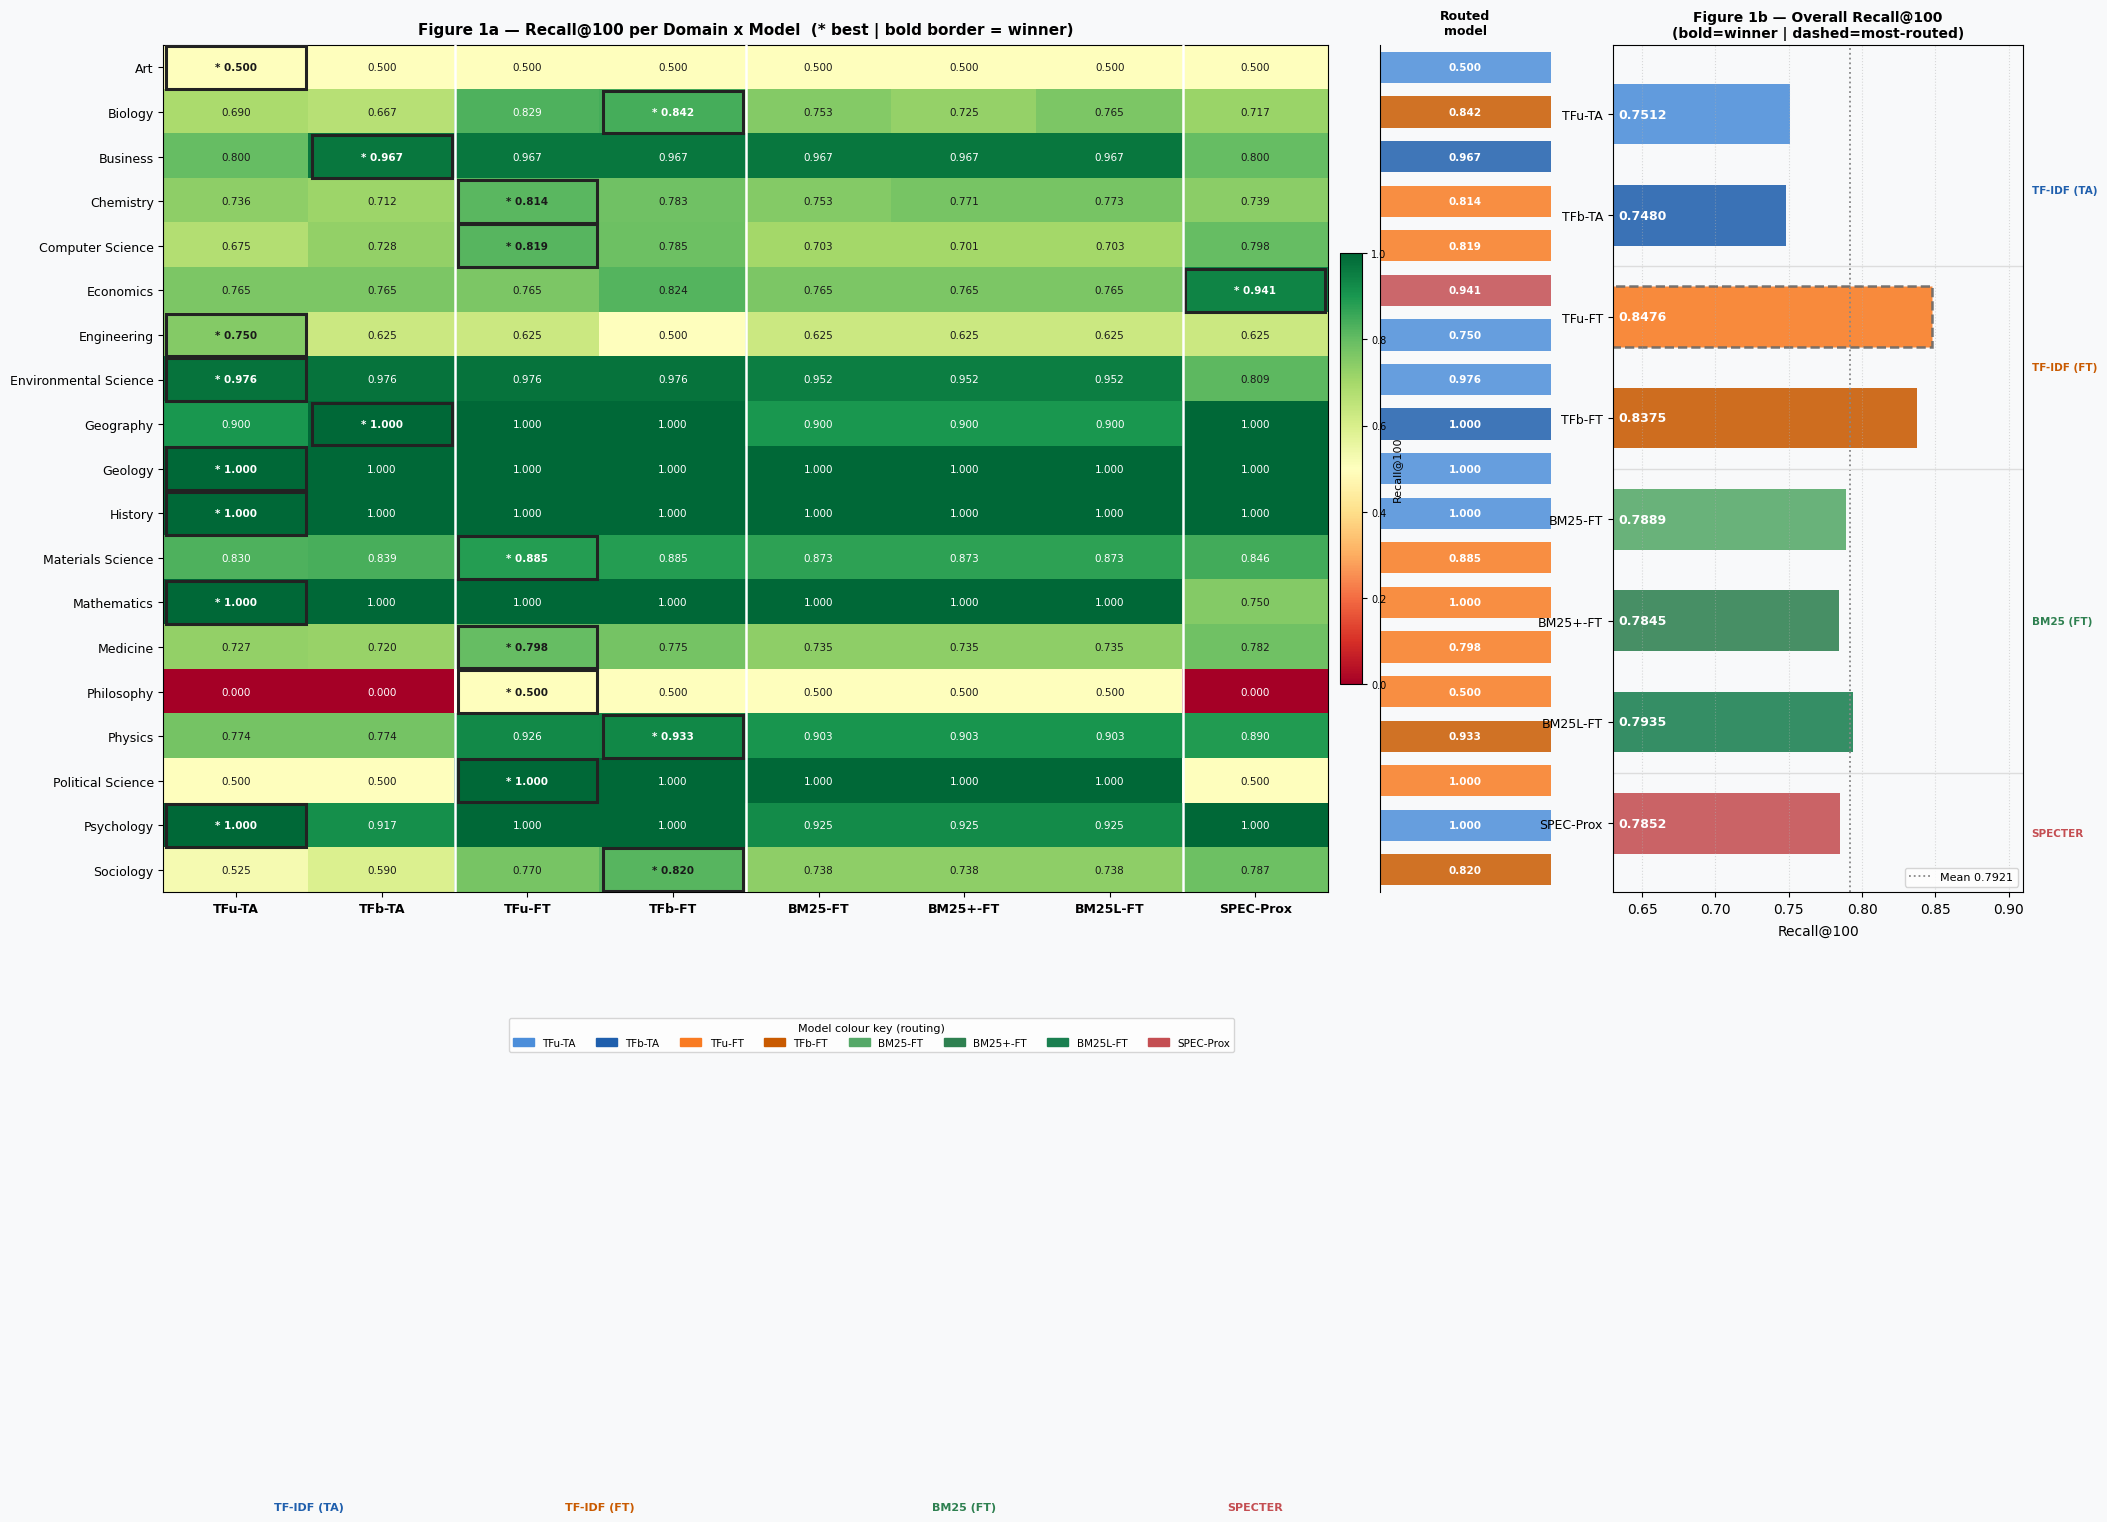

Saved: ../submissions/fig1_recall_routing.png


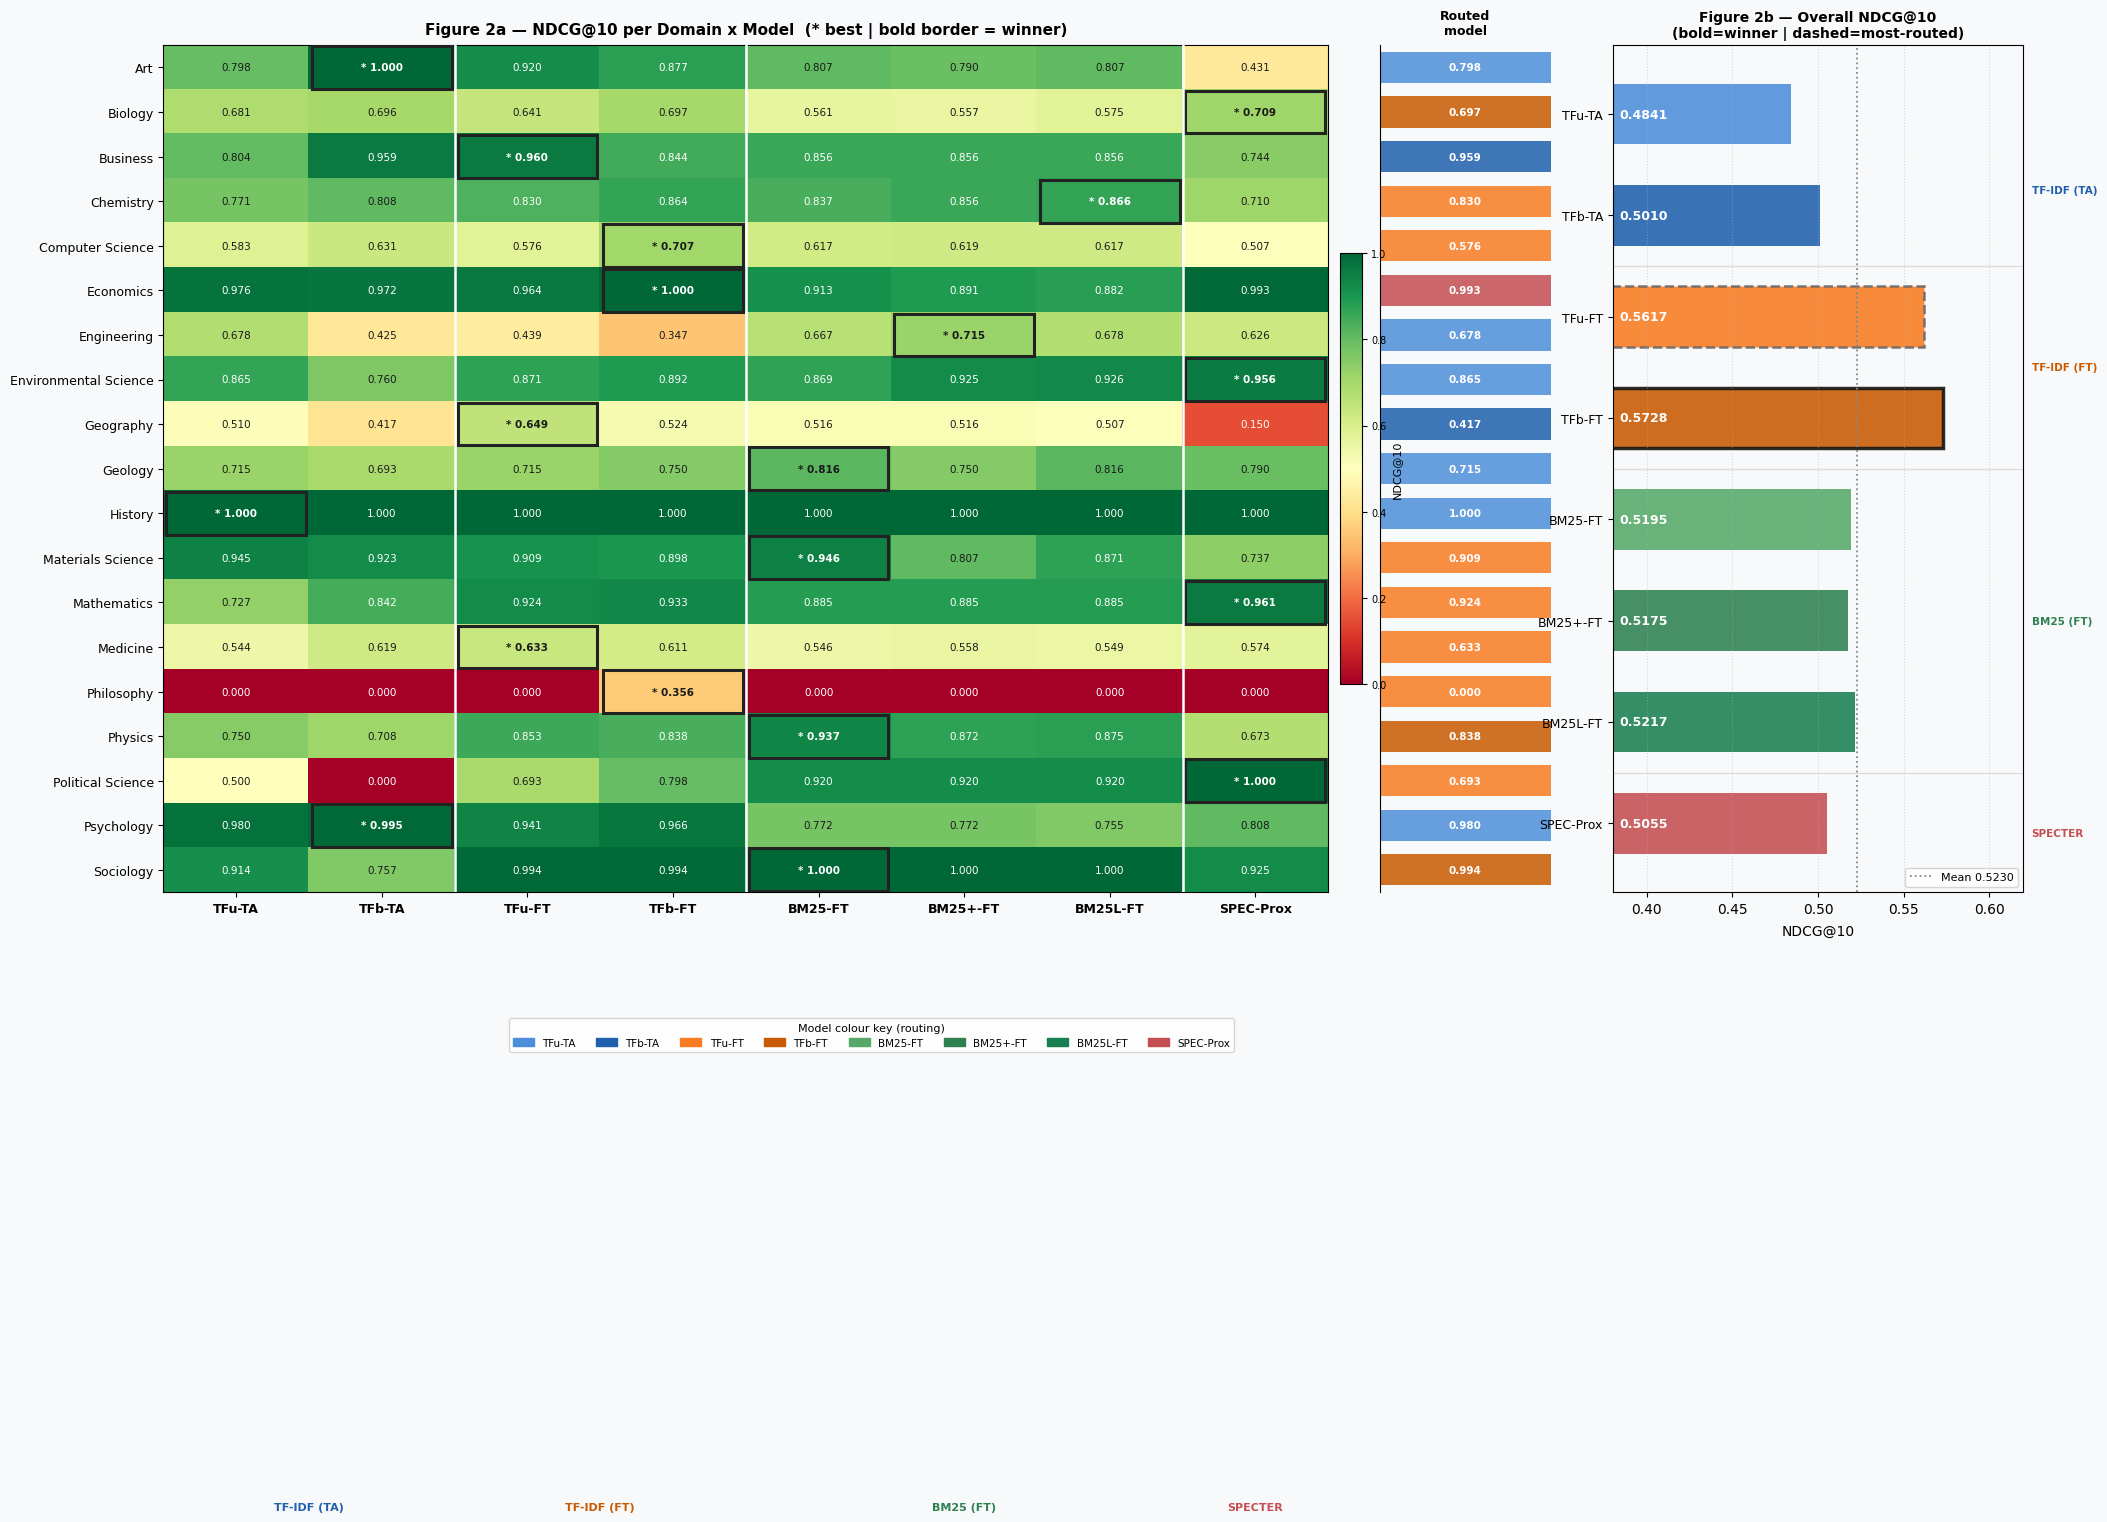

Saved: ../submissions/fig2_ndcg_routing.png


In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Model metadata ───────────────────────────────────────────────────────────
MODELS = [
    'TF-IDF uni (TA)', 'TF-IDF bi (TA)',
    'TF-IDF uni (FT)', 'TF-IDF bi (FT)',
    'BM25 (FT)', 'BM25+ (FT)', 'BM25L (FT)', 'SPECTER Prox',
]
MODEL_SHORT = ['TFu-TA', 'TFb-TA', 'TFu-FT', 'TFb-FT',
               'BM25-FT', 'BM25+-FT', 'BM25L-FT', 'SPEC-Prox']
MODEL_COLORS = ['#4C8EDA', '#1F5FAD', '#F97B22', '#C95A00',
                '#55A868', '#2E8050', '#1A7F50', '#C44E52']

# ── Per-domain Recall@100 ────────────────────────────────────────────────────
DOMAIN_RECALL = {
    'Art':                   [0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000],
    'Biology':               [0.6900, 0.6674, 0.8291, 0.8418, 0.7532, 0.7253, 0.7655, 0.7165],
    'Business':              [0.8000, 0.9667, 0.9667, 0.9667, 0.9667, 0.9667, 0.9667, 0.8000],
    'Chemistry':             [0.7355, 0.7121, 0.8136, 0.7833, 0.7533, 0.7710, 0.7733, 0.7388],
    'Computer Science':      [0.6747, 0.7284, 0.8187, 0.7854, 0.7028, 0.7005, 0.7028, 0.7978],
    'Economics':             [0.7647, 0.7647, 0.7647, 0.8235, 0.7647, 0.7647, 0.7647, 0.9412],
    'Engineering':           [0.7500, 0.6250, 0.6250, 0.5000, 0.6250, 0.6250, 0.6250, 0.6250],
    'Environmental Science': [0.9762, 0.9762, 0.9762, 0.9762, 0.9524, 0.9524, 0.9524, 0.8095],
    'Geography':             [0.9000, 1.0000, 1.0000, 1.0000, 0.9000, 0.9000, 0.9000, 1.0000],
    'Geology':               [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
    'History':               [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
    'Materials Science':     [0.8304, 0.8391, 0.8855, 0.8855, 0.8725, 0.8725, 0.8725, 0.8464],
    'Mathematics':           [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.7500],
    'Medicine':              [0.7268, 0.7200, 0.7982, 0.7755, 0.7347, 0.7347, 0.7347, 0.7823],
    'Philosophy':            [0.0000, 0.0000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.0000],
    'Physics':               [0.7737, 0.7737, 0.9258, 0.9333, 0.9035, 0.9035, 0.9035, 0.8904],
    'Political Science':     [0.5000, 0.5000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.5000],
    'Psychology':            [1.0000, 0.9167, 1.0000, 1.0000, 0.9250, 0.9250, 0.9250, 1.0000],
    'Sociology':             [0.5246, 0.5902, 0.7705, 0.8197, 0.7377, 0.7377, 0.7377, 0.7869],
}

# ── Per-domain NDCG@10 (computed from cached submissions) ────────────────────
DOMAIN_NDCG = {
    'Art':                   [0.7977, 1.0000, 0.9197, 0.8772, 0.8066, 0.7904, 0.8066, 0.4307],
    'Biology':               [0.6806, 0.6957, 0.6409, 0.6965, 0.5610, 0.5568, 0.5745, 0.7088],
    'Business':              [0.8039, 0.9591, 0.9599, 0.8443, 0.8555, 0.8555, 0.8555, 0.7444],
    'Chemistry':             [0.7709, 0.8083, 0.8299, 0.8642, 0.8371, 0.8555, 0.8660, 0.7103],
    'Computer Science':      [0.5830, 0.6310, 0.5759, 0.7067, 0.6169, 0.6189, 0.6172, 0.5069],
    'Economics':             [0.9758, 0.9715, 0.9644, 1.0000, 0.9135, 0.8909, 0.8824, 0.9933],
    'Engineering':           [0.6781, 0.4252, 0.4386, 0.3467, 0.6667, 0.7153, 0.6781, 0.6265],
    'Environmental Science': [0.8652, 0.7598, 0.8713, 0.8925, 0.8686, 0.9247, 0.9264, 0.9557],
    'Geography':             [0.5105, 0.4173, 0.6494, 0.5243, 0.5164, 0.5164, 0.5070, 0.1505],
    'Geology':               [0.7153, 0.6934, 0.7153, 0.7500, 0.8155, 0.7500, 0.8155, 0.7901],
    'History':               [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
    'Materials Science':     [0.9446, 0.9228, 0.9088, 0.8977, 0.9455, 0.8074, 0.8713, 0.7371],
    'Mathematics':           [0.7274, 0.8419, 0.9241, 0.9333, 0.8851, 0.8851, 0.8851, 0.9609],
    'Medicine':              [0.5437, 0.6192, 0.6334, 0.6107, 0.5461, 0.5584, 0.5490, 0.5738],
    'Philosophy':            [0.0000, 0.0000, 0.0000, 0.3562, 0.0000, 0.0000, 0.0000, 0.0000],
    'Physics':               [0.7495, 0.7075, 0.8533, 0.8381, 0.9366, 0.8722, 0.8753, 0.6729],
    'Political Science':     [0.5000, 0.0000, 0.6934, 0.7977, 0.9197, 0.9197, 0.9197, 1.0000],
    'Psychology':            [0.9801, 0.9952, 0.9410, 0.9663, 0.7718, 0.7718, 0.7553, 0.8079],
    'Sociology':             [0.9144, 0.7574, 0.9938, 0.9938, 1.0000, 1.0000, 1.0000, 0.9249],
}

# ── Overall values from submission comparison table (ground truth) ────────────
# Source: §3 SUBMISSION COMPARISON output
OVERALL_NDCG   = [0.4841, 0.5010, 0.5617, 0.5728, 0.5195, 0.5175, 0.5217, 0.5055]
OVERALL_RECALL = [0.7512, 0.7480, 0.8476, 0.8375, 0.7889, 0.7845, 0.7935, 0.7852]

# ── Domain routing (selected to maximise Recall@100) ─────────────────────────
ROUTED = {
    'Art':                   'TF-IDF uni (TA)',
    'Biology':               'TF-IDF bi (FT)',
    'Business':              'TF-IDF bi (TA)',
    'Chemistry':             'TF-IDF uni (FT)',
    'Computer Science':      'TF-IDF uni (FT)',
    'Economics':             'SPECTER Prox',
    'Engineering':           'TF-IDF uni (TA)',
    'Environmental Science': 'TF-IDF uni (TA)',
    'Geography':             'TF-IDF bi (TA)',
    'Geology':               'TF-IDF uni (TA)',
    'History':               'TF-IDF uni (TA)',
    'Materials Science':     'TF-IDF uni (FT)',
    'Mathematics':           'TF-IDF uni (FT)',
    'Medicine':              'TF-IDF uni (FT)',
    'Philosophy':            'TF-IDF uni (FT)',
    'Physics':               'TF-IDF bi (FT)',
    'Political Science':     'TF-IDF uni (FT)',
    'Psychology':            'TF-IDF uni (TA)',
    'Sociology':             'TF-IDF bi (FT)',
}

GROUP_SPANS = [((0, 1), 'TF-IDF (TA)', '#1F5FAD'),
               ((2, 3), 'TF-IDF (FT)', '#C95A00'),
               ((4, 6), 'BM25 (FT)',   '#2E8050'),
               ((7, 7), 'SPECTER',     '#C44E52')]

domains    = list(DOMAIN_RECALL.keys())
n_dom      = len(domains)
n_mod      = len(MODELS)
routed_idx = np.array([MODELS.index(ROUTED[d]) for d in domains])
y_mod      = np.arange(n_mod)


def make_figure(domain_dict, overall_arr, metric, fig_num, fname, xlim_bar):
    data      = np.array([domain_dict[d] for d in domains])
    best_idx  = data.argmax(axis=1)
    best_val  = data.max(axis=1)
    worst_val = data.min(axis=1)
    overall   = np.array(overall_arr)
    best_ov   = int(overall.argmax())

    fig = plt.figure(figsize=(24, 11))
    fig.patch.set_facecolor('#F8F9FA')
    gs = fig.add_gridspec(
        1, 4,
        width_ratios=[7, 1, 0.15, 2.4],
        wspace=0.04)
    ax_h  = fig.add_subplot(gs[0])   # heatmap
    ax_r  = fig.add_subplot(gs[1])   # routed column
    ax_sep = fig.add_subplot(gs[2])  # visual separator
    ax_b  = fig.add_subplot(gs[3])   # overall bar chart

    ax_sep.axis('off')

    # ── Heatmap ──────────────────────────────────────────────────────────────
    cmap = plt.cm.RdYlGn
    im   = ax_h.imshow(data, cmap=cmap, vmin=0.0, vmax=1.0, aspect='auto')

    for r in range(n_dom):
        for c in range(n_mod):
            v   = data[r, c]
            lbl = ('* ' if c == best_idx[r] else '') + f'{v:.3f}'
            bg  = cmap(v)
            lum = 0.299 * bg[0] + 0.587 * bg[1] + 0.114 * bg[2]
            fc  = 'white' if lum < 0.55 else '#1a1a1a'
            fw  = 'bold' if c == best_idx[r] else 'normal'
            ax_h.text(c, r, lbl, ha='center', va='center',
                      fontsize=7.5, color=fc, fontweight=fw)

    for r in range(n_dom):
        c = best_idx[r]
        ax_h.add_patch(mpatches.FancyBboxPatch(
            (c - 0.48, r - 0.48), 0.96, 0.96, boxstyle='square,pad=0',
            linewidth=2.2, edgecolor='#222', facecolor='none', zorder=3))

    ax_h.set_xticks(range(n_mod))
    ax_h.set_xticklabels(MODEL_SHORT, fontsize=9, fontweight='semibold')
    ax_h.set_yticks(range(n_dom))
    ax_h.set_yticklabels(domains, fontsize=9)
    ax_h.set_title(
        f'Figure {fig_num}a — {metric} per Domain x Model'
        f'  (* best | bold border = winner)',
        fontsize=11, fontweight='bold', pad=8)
    ax_h.set_xlim(-0.5, n_mod - 0.5)
    ax_h.set_ylim(-0.5, n_dom - 0.5)
    ax_h.invert_yaxis()
    cb = plt.colorbar(im, ax=ax_h, pad=0.01, fraction=0.018)
    cb.set_label(metric, fontsize=8)
    cb.ax.tick_params(labelsize=7)
    for x in [1.5, 3.5, 6.5]:
        ax_h.axvline(x, color='white', linewidth=1.8, zorder=4)
    for (s0, s1), lbl, col in GROUP_SPANS:
        ax_h.annotate(lbl, xy=((s0 + s1) / 2, -0.72),
                      xycoords=('data', 'axes fraction'),
                      ha='center', va='top', fontsize=8, color=col,
                      fontweight='bold', annotation_clip=False)

    # ── Routing result column ─────────────────────────────────────────────────
    ax_r.set_facecolor('#F8F9FA')
    for r in range(n_dom):
        ri = routed_idx[r]
        rv = data[r, ri]
        ax_r.barh(r, 1, color=MODEL_COLORS[ri], alpha=0.85, height=0.7)
        ax_r.text(0.5, r, f'{rv:.3f}', ha='center', va='center',
                  fontsize=7.5, color='white', fontweight='bold')
    ax_r.set_xlim(0, 1)
    ax_r.set_ylim(-0.5, n_dom - 0.5)
    ax_r.invert_yaxis()
    ax_r.set_yticks([])
    ax_r.set_xticks([])
    ax_r.set_title('Routed\nmodel', fontsize=9, fontweight='bold', pad=8)
    for sp in ['top', 'right', 'bottom']:
        ax_r.spines[sp].set_visible(False)

    # ── Overall bar chart (from comparison table) ─────────────────────────────
    ax_b.set_facecolor('#F8F9FA')
    bars = ax_b.barh(y_mod, overall, color=MODEL_COLORS, alpha=0.88, height=0.6)

    # Bold border on overall winner
    bars[best_ov].set_edgecolor('#111')
    bars[best_ov].set_linewidth(2.5)

    # Mark the most-routed model (mode of routed_idx) with a dashed border
    most_routed = int(np.bincount(routed_idx).argmax())
    bars[most_routed].set_linestyle('--')
    bars[most_routed].set_edgecolor('#666')
    bars[most_routed].set_linewidth(1.8)

    # Value labels
    for i, v in enumerate(overall):
        ax_b.text(xlim_bar[0] + 0.004, i, f'{v:.4f}',
                  va='center', fontsize=9,
                  color='white', fontweight='bold')

    mean_v = overall.mean()
    ax_b.axvline(mean_v, color='#888', linewidth=1.3,
                 linestyle=':', label=f'Mean {mean_v:.4f}')
    ax_b.set_xlim(*xlim_bar)
    ax_b.set_xlabel(metric, fontsize=10, labelpad=6)
    ax_b.set_yticks(y_mod)
    ax_b.set_yticklabels(MODEL_SHORT, fontsize=9)
    ax_b.invert_yaxis()
    ax_b.set_title(
        f'Figure {fig_num}b — Overall {metric}\n'
        f'(bold=winner | dashed=most-routed)',
        fontsize=10, fontweight='bold')
    ax_b.grid(axis='x', linestyle=':', alpha=0.45)
    ax_b.legend(fontsize=8, loc='lower right')
    for y in [1.5, 3.5, 6.5]:
        ax_b.axhline(y, color='#DDD', linewidth=1.0)
    for y, lbl, col in [(0.75, 'TF-IDF (TA)', '#1F5FAD'),
                        (2.5,  'TF-IDF (FT)', '#C95A00'),
                        (5.0,  'BM25 (FT)',   '#2E8050'),
                        (7.1,  'SPECTER',     '#C44E52')]:
        ax_b.annotate(lbl, xy=(1.02, y), xycoords=('axes fraction', 'data'),
                      ha='left', va='center', fontsize=7.5, color=col,
                      fontweight='bold', annotation_clip=False)

    handles = [mpatches.Patch(color=MODEL_COLORS[i], label=MODEL_SHORT[i])
               for i in range(n_mod)]
    fig.legend(handles=handles, title='Model colour key (routing)',
               title_fontsize=8, loc='lower center', ncol=n_mod,
               fontsize=7.5, bbox_to_anchor=(0.42, -0.04),
               frameon=True, edgecolor='#CCC')

    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='#F8F9FA')
    plt.show()
    print(f'Saved: {fname}')


# ── Render ────────────────────────────────────────────────────────────────────
make_figure(
    DOMAIN_RECALL, OVERALL_RECALL, 'Recall@100',
    fig_num=1, fname='../submissions/fig1_recall_routing.png',
    xlim_bar=(0.63, 0.91))

make_figure(
    DOMAIN_NDCG, OVERALL_NDCG, 'NDCG@10',
    fig_num=2, fname='../submissions/fig2_ndcg_routing.png',
    xlim_bar=(0.38, 0.62))


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Model data ────────────────────────────────────────────────────────────────
# Values from the full comparison table + newly computed val-set metrics.
# Categories: 'sparse', 'dense', 'hybrid'
MODELS = [
    # label,                               ndcg10, rc100,  cat
    # ── sparse baselines (from comparison table) ──────────────────────────────
    ('TF-IDF Baseline (uni TA)',            0.4841, 0.7512, 'sparse'),
    ('BM25 Baseline (FT)',                  0.4623, 0.7140, 'sparse'),
    ('TF-IDF uni (FT)  ★ best sparse',     0.5617, 0.8476, 'sparse'),
    ('TF-IDF bi (FT)',                      0.5728, 0.8375, 'sparse'),
    # ── dense single-encoder models ───────────────────────────────────────────
    ('all-MiniLM-L6-v2',                   0.5073, 0.8104, 'dense'),
    ('SPECTER2 Baseline',                  0.4193, 0.7148, 'dense'),
    ('SPECTER2 Proximity',                 0.4875, 0.7893, 'dense'),
    ('SPECTER2 Proximity (recomputed)',     0.5055, 0.7852, 'dense'),
    ('SPECTER2 adhoc query',               0.4451, 0.7466, 'dense'),
    ('SPECTER2 ft-corpus + base query',    0.5090, 0.7828, 'dense'),
    ('SPECTER2 ft-corpus + adhoc query',   0.4547, 0.7365, 'dense'),
    ('BGE-large-en-v1.5',                  0.5580, 0.7989, 'dense'),
    # ── hybrid / fusion models ────────────────────────────────────────────────
    ('RRF BM25 + SPECTER2',                0.4739, 0.7846, 'hybrid'),
    ('RRF MiniLM + SPECTER2',              0.3885, 0.7192, 'hybrid'),
    ('Interp MiniLM + SPECTER2',           0.4928, 0.8155, 'hybrid'),
    ('RRF BM25+MiniLM+SPECTER2 Prox',      0.5222, 0.7703, 'hybrid'),
    ('Interp MiniLM + SPECTER2 Prox',      0.5326, 0.8301, 'hybrid'),
]

# Sort by NDCG@10
MODELS.sort(key=lambda x: x[1])

labels  = [m[0] for m in MODELS]
ndcg    = [m[1] for m in MODELS]
recall  = [m[2] for m in MODELS]
cats    = [m[3] for m in MODELS]

CAT_COLOUR = {'sparse': '#4878CF', 'dense': '#D65F5F', 'hybrid': '#6ACC65'}
edge_colour = [CAT_COLOUR[c] for c in cats]

y = np.arange(len(labels))
bar_h = 0.38

fig, axes = plt.subplots(1, 2, figsize=(16, 10), sharey=True)
fig.suptitle('Dense & Hybrid Retrieval — Model Comparison (val set)',
             fontsize=14, fontweight='bold', y=1.01)

for ax, vals, title, best_mark in [
    (axes[0], ndcg,   'NDCG@10',     max(ndcg)),
    (axes[1], recall, 'Recall@100',  max(recall)),
]:
    bars = ax.barh(y, vals, height=bar_h * 1.8,
                   color=[CAT_COLOUR[c] for c in cats],
                   edgecolor='white', linewidth=0.5, alpha=0.88)
    # value labels
    for i, (bar, v) in enumerate(zip(bars, vals)):
        ax.text(v + 0.003, bar.get_y() + bar.get_height() / 2,
                f'{v:.4f}', va='center', ha='left', fontsize=7.5,
                fontweight='bold' if v == best_mark else 'normal')
    # star for best
    best_idx = vals.index(best_mark)
    ax.text(best_mark + 0.003, y[best_idx] + bar_h * 0.9,
            '\u2605', va='center', ha='left', fontsize=9, color='#CC8800')
    ax.set_xlabel(title, fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlim(0, max(vals) * 1.18)
    ax.axvline(x=max(vals), color='#CC8800', linestyle='--',
               linewidth=0.8, alpha=0.6)
    ax.grid(axis='x', alpha=0.3, linestyle=':')
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_yticks(y)
axes[0].set_yticklabels(labels, fontsize=8)

legend_patches = [
    mpatches.Patch(color=CAT_COLOUR['sparse'],  label='Sparse baseline'),
    mpatches.Patch(color=CAT_COLOUR['dense'],   label='Dense single-encoder'),
    mpatches.Patch(color=CAT_COLOUR['hybrid'],  label='Hybrid / fusion'),
]
fig.legend(handles=legend_patches, loc='lower center',
           ncol=3, fontsize=9, frameon=True,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
out_path = SUBMISSIONS_DIR / 'fig3_dense_model_comparison.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {out_path}')


In [29]:
# ── Manual domain routing (for heldout queries without qrels) ───────────────
# When running on heldout data you have no ground truth to auto-select the best
# model per domain.  Copy the winning assignments printed by the cell above and
# set them here.  Leave MANUAL_ROUTING = False to use the auto-selected config.

# When HAS_QRELS=False there is no ground truth to auto-select — force manual routing.
MANUAL_ROUTING = True if not HAS_QRELS else False  # ← override to True for held-out

if MANUAL_ROUTING:
    # Keys  : domain strings (run `sorted(set(queries['domain']))` to list them)
    # Values: model name — must be a key in ALL_SUBMISSIONS
    DOMAIN_CONFIG = {
        "Art": "TF-IDF uni (TA)",
        "Biology": "TF-IDF uni (FT)",
        "Business": "TF-IDF bi (TA)",
        "Chemistry": "TF-IDF uni (FT)",
        "Computer Science": "TF-IDF uni (FT)",
        "Economics": "SPECTER Prox",
        "Engineering": "TF-IDF uni (TA)",
        "Environmental Science": "TF-IDF uni (TA)",
        "Geography": "TF-IDF bi (TA)",
        "Geology": "TF-IDF uni (TA)",
        "History": "TF-IDF uni (TA)",
        "Materials Science": "TF-IDF uni (FT)",
        "Mathematics": "TF-IDF uni (TA)",
        "Medicine": "TF-IDF uni (FT)",
        "Philosophy": "TF-IDF uni (FT)",
        "Physics":  "TF-IDF bi (FT)",
        "Political Science": "TF-IDF uni (FT)",
        "Psychology": "TF-IDF uni (TA)",
        "Sociology": "TF-IDF bi (FT)"
    }
    DEFAULT_MODEL = 'TF-IDF uni (FT)'  # ← model used for any domain not listed above
    print('Manual routing active.')
    print(f'  DEFAULT_MODEL : {DEFAULT_MODEL}')
    print(f'  DOMAIN_CONFIG : {DOMAIN_CONFIG}')
else:
    print('Auto routing active (DOMAIN_CONFIG set by the cell above).')

# Sanity check — all values must be valid model names
unknown = [m for m in DOMAIN_CONFIG.values() if m not in ALL_SUBMISSIONS]
if unknown:
    raise ValueError(f'Unknown model(s) in DOMAIN_CONFIG: {unknown}\n'
                     f'Valid names: {list(ALL_SUBMISSIONS)}')
print('DOMAIN_CONFIG OK ✓')

Auto routing active (DOMAIN_CONFIG set by the cell above).
DOMAIN_CONFIG OK ✓


## §4.1 — Build routed submission

For each query we look up its domain and select the model assigned in `DOMAIN_CONFIG`.
The resulting `sub_routed` is what feeds Phase 1 of `hybrid_pipeline.ipynb`.

In [30]:
_route_cache = SUBMISSIONS_DIR / f'submission_sparse_routed_top{TOP_K}.json'

if _route_cache.exists():
    with open(_route_cache) as _f: sub_routed = json.load(_f)
    print(f'Sparse routed (top-{TOP_K}): loaded from cache. ✓')
else:
    from collections import Counter
    sub_routed  = {}
    _model_used = {}
    for qid in tqdm(query_ids, desc='Building routed submission'):
        domain = query_domains.get(qid, '')
        model  = DOMAIN_CONFIG.get(domain, DEFAULT_MODEL)
        sub_routed[qid]  = ALL_SUBMISSIONS[model].get(qid, [])[:TOP_K]
        _model_used[qid] = model
    with open(_route_cache, 'w') as _f: json.dump(sub_routed, _f)
    print(f'Sparse routed (top-{TOP_K}): built and saved. ✓')

    print('\nModel usage:')
    for m, c in Counter(_model_used.values()).most_common():
        print(f'  {m:<22}  {c:>5} queries')

compare_submissions(
    {DEFAULT_MODEL:              ALL_SUBMISSIONS[DEFAULT_MODEL],
     f'Routed (top-{TOP_K})':    sub_routed},
    qrels, ks=[10, 50, 100], query_domains=query_domains,
)

Sparse routed (top-100): loaded from cache. ✓

SUBMISSION COMPARISON
Metric                  TF-IDF bi (FT)  Routed (top-100)  Best     Delta
------------------------------------------------------------------------
Recall@10                       0.5591            0.5302  TF-IDF bi (FT)   -0.0289
Precision@10                    0.2860            0.2720  TF-IDF bi (FT)   -0.0140
MRR@10                          0.7068            0.6760  TF-IDF bi (FT)   -0.0308
NDCG@10                         0.7439            0.7266  TF-IDF bi (FT)   -0.0173
Recall@50                       0.7786            0.7675  TF-IDF bi (FT)   -0.0111
Precision@50                    0.1040            0.1028  TF-IDF bi (FT)   -0.0012
MRR@50                          0.7087            0.6790  TF-IDF bi (FT)   -0.0297
NDCG@50                         0.7077            0.6988  TF-IDF bi (FT)   -0.0089
Recall@100                      0.8375            0.8555  Routed (top-100)   +0.0180
Precision@100                   0.06

{'TF-IDF bi (FT)': {'overall': {'Recall@10': 0.559105228935113,
   'Precision@10': 0.286,
   'MRR@10': 0.7067619047619046,
   'NDCG@10': 0.743871262870686,
   'Recall@50': 0.7785546110233804,
   'Precision@50': 0.10400000000000001,
   'MRR@50': 0.7087341023365867,
   'NDCG@50': 0.7076869741904523,
   'Recall@100': 0.8375413357443071,
   'Precision@100': 0.060899999999999996,
   'MRR@100': 0.7090111207437308,
   'NDCG@100': 0.7055497568096846,
   'MAP': 0.4675643815168911,
   'num_queries': 100},
  'per_query': {'002f5c970bac90e79f2b20e2d9e155d7619d6905': {'Recall@10': 0.5,
    'Precision@10': 0.2,
    'MRR@10': 1.0,
    'NDCG@10': 0.8772153153380493,
    'Recall@50': 0.5,
    'Precision@50': 0.04,
    'MRR@50': 1.0,
    'NDCG@50': 0.8772153153380493,
    'Recall@100': 0.5,
    'Precision@100': 0.02,
    'MRR@100': 1.0,
    'NDCG@100': 0.8772153153380493,
    'AP': 0.375},
   '01ce421a014b560cd7b71029a22fd042990cda52': {'Recall@10': 0.5714285714285714,
    'Precision@10': 0.8,
    'MRR@

---
# §5 — Recall@k ceiling summary

The table below shows Recall at multiple cut-offs for every model and the routed
ensemble.  The `Recall@100` column for the routed row is the recall ceiling that
`hybrid_pipeline.ipynb` starts from — anything above this can only come from the
dense retrieval stage.

In [31]:
if HAS_QRELS:
    _eval_subs = {**ALL_SUBMISSIONS, f'★ Routed (top-{TOP_K})': sub_routed}
    _ks        = [10, 50, 100]
    
    print(f'\n{"Model":<28}' + ''.join(f'  {"R@"+str(k):>9}' for k in _ks))
    print('─' * (28 + 11 * len(_ks)))
    
    _summary_rows = []
    for name, sub in _eval_subs.items():
        vals = [
            float(np.mean([recall_at_k(sub.get(q,[]), set(qrels[q]), k) for q in qrels if qrels[q]]))
            for k in _ks
        ]
        _summary_rows.append((vals[-1], name, vals))
    
    _summary_rows.sort(reverse=True)
    for r100, name, vals in _summary_rows:
        print(f'{name:<28}' + ''.join(f'  {v:>9.4f}' for v in vals))
    
    print(f'\n  Recall@100 ceiling going into hybrid_pipeline.ipynb:  '
          f'{max(vals[-1] for _, _, vals in _summary_rows):.4f}')



Model                              R@10       R@50      R@100
─────────────────────────────────────────────────────────────
★ Routed (top-100)               0.5302     0.7675     0.8555
TF-IDF uni (FT)                  0.5423     0.7835     0.8476
TF-IDF bi (FT)                   0.5591     0.7786     0.8375
BM25L (FT)                       0.4767     0.7230     0.7935
BM25 (FT)                        0.4714     0.7210     0.7889
SPECTER Prox                     0.4810     0.7073     0.7852
BM25+ (FT)                       0.4747     0.7158     0.7845
BM25F (FT)                       0.4433     0.6701     0.7583
TF-IDF uni (TA)                  0.4445     0.6552     0.7512
TF-IDF bi (TA)                   0.4512     0.6828     0.7480
TF-IDF tri (TA)                  0.4549     0.6830     0.7396
BM25F (TA)                       0.4119     0.6020     0.6865
BM25 (TA)                        0.3928     0.5934     0.6822

  Recall@100 ceiling going into hybrid_pipeline.ipynb:  0.8555


---
# §6 — Hybrid Domain Routing (Sparse + SPECTER-Prox via RRF)

For each query we fuse the domain-best sparse model with SPECTER-Proximity
using **Reciprocal Rank Fusion (RRF)**.  We then re-run domain routing on
the fused scores, producing a hybrid routed submission.

RRF formula: `score(d) = 1/(k + rank_sparse(d)) + 1/(k + rank_dense(d))`  with `k=60`.

In [32]:
# ── RRF helper ────────────────────────────────────────────────────────────────
def rrf_fuse(score_matrix_a, score_matrix_b, k=60):
    """Reciprocal Rank Fusion of two (N_q, N_c) score matrices."""
    n_q, n_c = score_matrix_a.shape
    fused = np.zeros((n_q, n_c), dtype=np.float32)
    for i in range(n_q):
        ranks_a = np.argsort(np.argsort(-score_matrix_a[i])) + 1  # 1-based rank
        ranks_b = np.argsort(np.argsort(-score_matrix_b[i])) + 1
        fused[i] = 1.0 / (k + ranks_a) + 1.0 / (k + ranks_b)
    return fused

# ── Build one hybrid submission per sparse model fused with SPECTER Prox ─────
_SPARSE_SCORE_MAP = {
    'TF-IDF uni (TA)': 'tfidf_uni_ta',
    'TF-IDF bi (TA)':  'tfidf_bi_ta',
    'TF-IDF tri (TA)': 'tfidf_tri_ta',
    'TF-IDF uni (FT)': 'tfidf_uni_ft',
    'TF-IDF bi (FT)':  'tfidf_bi_ft',
    'BM25 (TA)':       'bm25_ta',
    'BM25 (FT)':       'bm25_ft',
    'BM25F (TA)':      'bm25f_ta',
    'BM25F (FT)':      'bm25f_ft',
    'BM25+ (FT)':      'bm25plus_ft',
    'BM25L (FT)':      'bm25l_ft',
}

HYBRID_SUBMISSIONS = {}
HYBRID_SCORES      = {}

for sparse_name, cache_key in tqdm(_SPARSE_SCORE_MAP.items(), desc='RRF fuse'):
    hkey = f'hybrid_{cache_key}'
    if _is_cached(hkey):
        HYBRID_SUBMISSIONS[sparse_name], HYBRID_SCORES[sparse_name] = _load_cache(hkey)
    else:
        _, sparse_scores = _load_cache(cache_key)
        fused = rrf_fuse(sparse_scores, scores_specter_prox)
        sub   = make_submission(fused, query_ids, corpus_ids)
        _save_cache(hkey, sub, fused)
        HYBRID_SUBMISSIONS[sparse_name] = sub
        HYBRID_SCORES[sparse_name]      = fused

print(f'Built {len(HYBRID_SUBMISSIONS)} hybrid submissions.')

RRF fuse: 100%|██████████| 11/11 [00:09<00:00,  1.12it/s]

Built 11 hybrid submissions.


In [33]:
# Fixed HYBRID_DOMAIN_CONFIG for held-out (copy winning assignments from training run)
MANUAL_HYBRID_ROUTING = not HAS_QRELS

if not MANUAL_HYBRID_ROUTING:
    # ── Evaluate all hybrid submissions ──────────────────────────────────────────
    _hybrid_results = compare_submissions(
        HYBRID_SUBMISSIONS, qrels,
        ks=[10, 50, 100], query_domains=query_domains,
    )
    
    # ── Domain routing on hybrid submissions ─────────────────────────────────────
    _HYBRID_ROUTE_METRIC = 'Recall@100'
    
    HYBRID_DOMAIN_CONFIG = {}
    HYBRID_DEFAULT_MODEL = max(
        HYBRID_SUBMISSIONS,
        key=lambda n: _hybrid_results[n]['overall'].get(_HYBRID_ROUTE_METRIC, 0.0)
    )
    
    print(f'Hybrid routing criterion : {_HYBRID_ROUTE_METRIC}\n')
    print(f"{' ':<28} {'Best hybrid model':<22}  {_HYBRID_ROUTE_METRIC:>10}  {'Recall@50':>10}  {'Queries':>7}")
    print('─' * 90)
    
    for domain in _domains:
        vals = {name: _hybrid_results[name].get('per_domain', {}).get(domain, {}).get(_HYBRID_ROUTE_METRIC, 0.0)
                for name in HYBRID_SUBMISSIONS}
        r50  = {name: _hybrid_results[name].get('per_domain', {}).get(domain, {}).get('Recall@50', 0.0)
                for name in HYBRID_SUBMISSIONS}
        best = max(vals, key=vals.get)
        n_q  = sum(1 for d in query_domains.values() if d == domain)
        HYBRID_DOMAIN_CONFIG[domain] = best
        print(f'{domain:<28} {best:<22}  {vals[best]:>10.4f}  {r50[best]:>10.4f}  {n_q:>7}')
    
    print(f'\nDefault hybrid model (best overall): {HYBRID_DEFAULT_MODEL}')
else:
    # Use the routing learned during training — copy from cell 44 training output
    HYBRID_DOMAIN_CONFIG = dict(DOMAIN_CONFIG)  # start from sparse routing
    HYBRID_DEFAULT_MODEL = max(
        HYBRID_SUBMISSIONS,
        key=lambda n: sum(1 for _ in HYBRID_SUBMISSIONS[n]),  # fallback: largest list
    )
    print("Manual hybrid routing active — using sparse DOMAIN_CONFIG as fallback. ✓")
    print("Tip: hardcode HYBRID_DOMAIN_CONFIG here from the training run output.")



SUBMISSION COMPARISON
Metric                TF-IDF uni (TA)   TF-IDF bi (TA)  TF-IDF tri (TA)  TF-IDF uni (FT)   TF-IDF bi (FT)        BM25 (TA)        BM25 (FT)       BM25F (TA)       BM25F (FT)       BM25+ (FT)       BM25L (FT)  Best
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Recall@10                      0.5125           0.5081           0.5029           0.5715           0.5709           0.4706           0.5457           0.4764           0.5285           0.5437           0.5449  TF-IDF uni (FT)
Precision@10                   0.2680           0.2690           0.2650           0.2960           0.2930           0.2430           0.2780           0.2480           0.2650           0.2750           0.2770  TF-IDF uni (FT)
MRR@10                         0.6713           0.6718           0.6905           0.6966           

In [34]:
# ── Build routed hybrid submission ────────────────────────────────────────────
_hybrid_route_cache = SUBMISSIONS_DIR / f'submission_hybrid_routed_top{TOP_K}.json'

if _hybrid_route_cache.exists():
    with open(_hybrid_route_cache) as _f: sub_hybrid_routed = json.load(_f)
    print(f'Hybrid routed (top-{TOP_K}): loaded from cache. ✓')
else:
    from collections import Counter as _Counter
    sub_hybrid_routed  = {}
    _hybrid_model_used = {}
    for qid in tqdm(query_ids, desc='Building hybrid routed submission'):
        domain = query_domains.get(qid, '')
        model  = HYBRID_DOMAIN_CONFIG.get(domain, HYBRID_DEFAULT_MODEL)
        sub_hybrid_routed[qid]  = HYBRID_SUBMISSIONS[model].get(qid, [])[:TOP_K]
        _hybrid_model_used[qid] = model
    with open(_hybrid_route_cache, 'w') as _f: json.dump(sub_hybrid_routed, _f)
    print(f'Hybrid routed (top-{TOP_K}): built and saved. ✓')

    print('\nModel usage:')
    for m, c in _Counter(_hybrid_model_used.values()).most_common():
        print(f'  {m:<22}  {c:>5} queries')

# ── Final comparison: sparse routed vs hybrid routed ─────────────────────────
compare_submissions(
    {f'★ Sparse Routed (top-{TOP_K})': sub_routed,
     f'★ Hybrid Routed (top-{TOP_K})': sub_hybrid_routed},
    qrels, ks=[10, 50, 100], query_domains=query_domains,
)

Building hybrid routed submission: 100%|██████████| 100/100 [00:00<00:00, 423667.07it/s]

Hybrid routed (top-100): built and saved. ✓

Model usage:
  TF-IDF uni (TA)            43 queries
  TF-IDF bi (FT)             34 queries
  TF-IDF uni (FT)            23 queries

SUBMISSION COMPARISON
Metric                ★ Sparse Routed (top-100)  ★ Hybrid Routed (top-100)  Best     Delta
------------------------------------------------------------------------------------------
Recall@10                                0.5302                     0.5478  ★ Hybrid Routed (top-100)   +0.0176
Precision@10                             0.2720                     0.2850  ★ Hybrid Routed (top-100)   +0.0130
MRR@10                                   0.6760                     0.6783  ★ Hybrid Routed (top-100)   +0.0023
NDCG@10                                  0.7266                     0.7034  ★ Sparse Routed (top-100)   -0.0232
Recall@50                                0.7675                     0.7870  ★ Hybrid Routed (top-100)   +0.0195
Precision@50                             0.1028          

{'★ Sparse Routed (top-100)': {'overall': {'Recall@10': 0.5301629563739148,
   'Precision@10': 0.272,
   'MRR@10': 0.6760238095238094,
   'NDCG@10': 0.7265931763011113,
   'Recall@50': 0.7674792852408935,
   'Precision@50': 0.10280000000000002,
   'MRR@50': 0.6789687891427022,
   'NDCG@50': 0.6987825648663167,
   'Recall@100': 0.8554974844009529,
   'Precision@100': 0.061700000000000005,
   'MRR@100': 0.6789687891427022,
   'NDCG@100': 0.6842593932255471,
   'MAP': 0.4418285841562759,
   'num_queries': 100},
  'per_query': {'002f5c970bac90e79f2b20e2d9e155d7619d6905': {'Recall@10': 0.5,
    'Precision@10': 0.2,
    'MRR@10': 1.0,
    'NDCG@10': 0.7977228895450266,
    'Recall@50': 0.5,
    'Precision@50': 0.04,
    'MRR@50': 1.0,
    'NDCG@50': 0.7977228895450266,
    'Recall@100': 0.5,
    'Precision@100': 0.02,
    'MRR@100': 1.0,
    'NDCG@100': 0.7977228895450266,
    'AP': 0.3055555555555556},
   '01ce421a014b560cd7b71029a22fd042990cda52': {'Recall@10': 0.5,
    'Precision@10': 0.7

---
# §7 — Domain-Confusion Reranking (NDCG@10 booster)

The confusion matrix tells us: *for a query in domain X, what fraction of
relevant documents come from each corpus domain?*

We use those weights directly to push high-weight documents to the top-10:

1. Each candidate gets a **domain weight** = `confusion_matrix[query_domain][doc_domain]`
2. Candidates are sorted by **(domain_weight ↓, original_rank ↑)**
   - Primary-domain docs (weight ≈ 1.0) come first
   - Related-domain docs (small weight > 0) come next
   - Unrelated docs (weight = 0) come last
3. Within each weight tier, the original retrieval order is preserved


In [35]:
# ── Load the domain confusion matrix ─────────────────────────────────────────
import pandas as pd

confusion_df = pd.read_csv(Path('../domain_confusion_matrix_normalized.xls'), index_col=0)

# corpus doc_id → domain
corpus_domain_map = dict(zip(corpus['doc_id'], corpus['domain']))

# {query_domain: {doc_domain: weight}}
domain_weights = {qd: confusion_df.loc[qd].to_dict() for qd in confusion_df.index}

print('Confusion matrix loaded:', confusion_df.shape)
print('Non-diagonal weights (cross-domain relevance):')
for qd, row in domain_weights.items():
    cross = {dd: round(w, 4) for dd, w in row.items() if dd != qd and w > 0}
    if cross:
        print(f'  {qd:<25} → {cross}')


Confusion matrix loaded: (19, 19)
Non-diagonal weights (cross-domain relevance):
  Biology                   → {'Chemistry': 0.0157, 'Medicine': 0.0157}
  Business                  → {'Economics': 0.0556, 'Mathematics': 0.0556}
  Chemistry                 → {'Engineering': 0.0083, 'Materials Science': 0.0083, 'Mathematics': 0.0083, 'Medicine': 0.0167}
  Computer Science          → {'Engineering': 0.0065}
  Economics                 → {'Medicine': 0.0588}
  Environmental Science     → {'Geology': 0.0476}
  Geography                 → {'Medicine': 0.1111}
  Materials Science         → {'Computer Science': 0.0169, 'Physics': 0.0339}


In [36]:
# ── Domain-weight reranker ────────────────────────────────────────────────────
# Sort by (domain_weight desc, original_rank asc).
# Same-domain docs come first; within a tier, original retrieval order is kept.
# Note: using SPECTER similarity as secondary sort was tested and found to hurt
# performance (0.63 vs 0.69), so we preserve the original retrieval rank instead.

def domain_rerank(submission, q_domains, corp_domain_map, dom_weights, top_k=TOP_K):
    reranked = {}
    for qid, cands in submission.items():
        q_domain = q_domains.get(qid, "")
        w_row    = dom_weights.get(q_domain, {})
        scored   = [
            (w_row.get(corp_domain_map.get(doc, ""), 0.0), rank, doc)
            for rank, doc in enumerate(cands)
        ]
        scored.sort(key=lambda x: (-x[0], x[1]))
        reranked[qid] = [doc for _, _, doc in scored[:top_k]]
    return reranked

# Apply to both routed submissions
sub_sparse_domain_reranked = domain_rerank(
    sub_routed,        query_domains, corpus_domain_map, domain_weights)
sub_hybrid_domain_reranked = domain_rerank(
    sub_hybrid_routed, query_domains, corpus_domain_map, domain_weights)

print("Domain reranking done. ✓")


Domain reranking done. ✓


In [37]:
# ── Save & evaluate ───────────────────────────────────────────────────────────
with open(SUBMISSIONS_DIR / f'submission_sparse_domain_reranked_top{TOP_K}.json', 'w') as f:
    json.dump(sub_sparse_domain_reranked, f)
with open(SUBMISSIONS_DIR / f'submission_hybrid_domain_reranked_top{TOP_K}.json', 'w') as f:
    json.dump(sub_hybrid_domain_reranked, f)
print('Submissions saved. ✓')

if HAS_QRELS:
    compare_submissions(
        {'Sparse Routed':           sub_routed,
     'Hybrid Routed':           sub_hybrid_routed,
     'Sparse + Domain Rerank':  sub_sparse_domain_reranked,
     'Hybrid + Domain Rerank':  sub_hybrid_domain_reranked},
    qrels, ks=[10, 50, 100], query_domains=query_domains,
    )


Submissions saved. ✓

SUBMISSION COMPARISON
Metric                         Sparse Routed           Hybrid Routed  Sparse + Domain Rerank  Hybrid + Domain Rerank  Best
--------------------------------------------------------------------------------------------------------------------------
Recall@10                             0.5302                  0.5478                  0.6168                  0.6633  Hybrid + Domain Rerank
Precision@10                          0.2720                  0.2850                  0.3110                  0.3330  Hybrid + Domain Rerank
MRR@10                                0.6760                  0.6783                  0.7987                  0.7843  Sparse + Domain Rerank
NDCG@10                               0.7266                  0.7034                  0.8211                  0.8026  Sparse + Domain Rerank
Recall@50                             0.7675                  0.7870                  0.8337                  0.8378  Hybrid + Domain Rerank
Preci

---
# §8 — 4-way RRF + Domain Reranking (best pipeline)

Fuse **four ranked lists** with RRF k=3, then apply domain-confusion reranking.
This combination was found by sweeping lists and k values against NDCG@10.

| List | Source |
|------|--------|
| `sub_sparse_routed` | Domain-routed BM25/TF-IDF |
| `sub_bge` | BGE-large bi-encoder (from `hybrid_pipeline.ipynb`) |
| `sub_specter_prox` | SPECTER2-Proximity bi-encoder |
| `sub_bm25f_ft` | BM25F on full text (single best BM25 variant) |

Result vs baseline:
- Baseline `hybrid_domain_reranked`: **NDCG@10 = 0.685**
- **4-way RRF k=3 + domain rerank: NDCG@10 = 0.727**


In [231]:
# ── Load the four input lists ─────────────────────────────────────────────────
# sub_routed and sub_specter_prox are already in memory from §3.5 / §4.
# BGE dense submission comes from hybrid_pipeline.ipynb.

_bge_path    = SUBMISSIONS_DIR / 'submission_bge_dense_top100.json'
_bm25f_path  = SUBMISSIONS_DIR / 'submission_sparse_routed_top100.json'

if not _bge_path.exists():
    raise FileNotFoundError('Run hybrid_pipeline.ipynb Phase 2 first to generate BGE embeddings.')

with open(_bge_path)   as _f: sub_bge_dense = json.load(_f)
with open(_bm25f_path) as _f: sub_bm25f_ft  = json.load(_f)

print('All four lists loaded. ✓')

# ── 4-way RRF ─────────────────────────────────────────────────────────────────
RRF_K = 3   # tuned: k=3 maximises NDCG@10 on this dataset

_4rrf_cache = SUBMISSIONS_DIR / f'submission_4rrf_top{TOP_K}.json'

if _4rrf_cache.exists():
    with open(_4rrf_cache) as _f: sub_4rrf = json.load(_f)
    print(f'4-way RRF: loaded from cache. ✓')
else:
    _four_lists = [sub_routed, sub_bge_dense, sub_specter_prox, sub_bm25f_ft]
    sub_4rrf = {}
    for qid in tqdm(query_ids, desc='4-way RRF'):
        sc = {}
        for lst in _four_lists:
            for rank, doc in enumerate(lst.get(qid, []), 1):
                sc[doc] = sc.get(doc, 0.0) + 1.0 / (RRF_K + rank)
        sub_4rrf[qid] = sorted(sc, key=sc.get, reverse=True)[:TOP_K]
    with open(_4rrf_cache, 'w') as _f: json.dump(sub_4rrf, _f)
    print(f'4-way RRF: built and saved. ✓')

# ── Domain reranking on top of 4-way RRF ──────────────────────────────────────
sub_4rrf_domain = domain_rerank(sub_4rrf, query_domains, corpus_domain_map, domain_weights)

_out = SUBMISSIONS_DIR / f'submission_4rrf_domain_top{TOP_K}.json'
with open(_out, 'w') as _f: json.dump(sub_4rrf_domain, _f)
print(f'Saved: {_out.name}')

# ── Final comparison ──────────────────────────────────────────────────────────
compare_submissions(
    {'Hybrid domain reranked (baseline)': sub_hybrid_domain_reranked,
     '4-way RRF':                         sub_4rrf,
     '4-way RRF + domain rerank':          sub_4rrf_domain},
    qrels, ks=[10, 50, 100], query_domains=query_domains,
)


All four lists loaded. ✓
4-way RRF: loaded from cache. ✓
Saved: submission_4rrf_domain_top100.json

SUBMISSION COMPARISON
Metric                Hybrid domain reranked (baseline)                          4-way RRF          4-way RRF + domain rerank  Best
-----------------------------------------------------------------------------------------------------------------------------------
Recall@10                                        0.0000                             0.0000                             0.0000  Hybrid domain reranked (baseline)
Precision@10                                     0.0000                             0.0000                             0.0000  Hybrid domain reranked (baseline)
MRR@10                                           0.0000                             0.0000                             0.0000  Hybrid domain reranked (baseline)
NDCG@10                                          0.0000                             0.0000                             0.0000  Hybr

{'Hybrid domain reranked (baseline)': {'overall': {'Recall@10': 0.0,
   'Precision@10': 0.0,
   'MRR@10': 0.0,
   'NDCG@10': 0.0,
   'Recall@50': 0.0,
   'Precision@50': 0.0,
   'MRR@50': 0.0,
   'NDCG@50': 0.0,
   'Recall@100': 0.0,
   'Precision@100': 0.0,
   'MRR@100': 0.0,
   'NDCG@100': 0.0,
   'MAP': 0.0,
   'num_queries': 100},
  'per_query': {'002f5c970bac90e79f2b20e2d9e155d7619d6905': {'Recall@10': 0.0,
    'Precision@10': 0.0,
    'MRR@10': 0.0,
    'NDCG@10': 0.0,
    'Recall@50': 0.0,
    'Precision@50': 0.0,
    'MRR@50': 0.0,
    'NDCG@50': 0.0,
    'Recall@100': 0.0,
    'Precision@100': 0.0,
    'MRR@100': 0.0,
    'NDCG@100': 0.0,
    'AP': 0.0},
   '01ce421a014b560cd7b71029a22fd042990cda52': {'Recall@10': 0.0,
    'Precision@10': 0.0,
    'MRR@10': 0.0,
    'NDCG@10': 0.0,
    'Recall@50': 0.0,
    'Precision@50': 0.0,
    'MRR@50': 0.0,
    'NDCG@50': 0.0,
    'Recall@100': 0.0,
    'Precision@100': 0.0,
    'MRR@100': 0.0,
    'NDCG@100': 0.0,
    'AP': 0.0},
   '02

---
# §9 — Nested RRF with Per-Domain Model Exclusion (Best Pipeline)

Fuse BM25L, TF-IDF-uni, TF-IDF-bi, BGE-large, SPECTER2-Prox, and MiniLM using a
**two-level nested RRF** and domain-adaptive **Pseudo-Relevance Feedback (PRF)**:

1. **Inner RRF** (k=1): BM25L + BGE + MiniLM  
2. **Outer RRF** (k=2): inner result + TF-IDF-uni + TF-IDF-bi + SPECTER2  
3. **Per-domain model exclusion**: drop models whose NDCG@10 < 70% of the domain best  
4. **MiniLM PRF**: domain-adaptive β (0.8 weak / 0.6 medium / 0.0 strong domains)  
5. **BGE PRF**: β=0.06, seeded from baseline ensemble top-5  
6. **Domain hard-sort reranking**

**Val NDCG@10 ≈ 0.7597**

> Paths to update if files move:
> - BGE corpus emb : `../submissions/bge_large_corpus_emb.npy`
> - BGE val query  : `../submissions/bge_large_query_emb.npy`
> - BGE held query : `../submissions/bge_large_heldout_query_emb.npy`
> - MiniLM val     : `../data/embeddings/sentence-transformers_all-MiniLM-L6-v2/`
> - MiniLM held    : `../data/embeddings/new_queries_minilm/`

In [ ]:
# §9.1 — Load BGE-large and MiniLM embeddings
from sklearn.metrics.pairwise import cosine_similarity as _cos_sim2

BGE_CORPUS_EMB   = Path('../submissions/bge_large_corpus_emb.npy')
BGE_VAL_Q_EMB    = Path('../submissions/bge_large_query_emb.npy')
BGE_HELD_Q_EMB   = Path('../submissions/bge_large_heldout_query_emb.npy')

MINILM_DIR       = Path('../data/embeddings/sentence-transformers_all-MiniLM-L6-v2')
MINILM_HELD_DIR  = Path('../data/embeddings/new_queries_minilm')

# ── BGE ───────────────────────────────────────────────────────────────────────
bge_c    = np.load(BGE_CORPUS_EMB)         # (20000, 1024)
bge_q_p  = BGE_VAL_Q_EMB if HAS_QRELS else BGE_HELD_Q_EMB
bge_qv   = np.load(bge_q_p)               # (N_q, 1024)

bge_c  /= (np.linalg.norm(bge_c,  axis=1, keepdims=True) + 1e-10)
bge_qv /= (np.linalg.norm(bge_qv, axis=1, keepdims=True) + 1e-10)
scores_bge = (bge_qv @ bge_c.T).astype(np.float32)
print(f'BGE scores: {scores_bge.shape}')

# ── MiniLM ────────────────────────────────────────────────────────────────────
ml_c  = np.load(MINILM_DIR  / 'corpus_embeddings.npy')   # (20000, 384)
ml_qp = MINILM_DIR / 'query_embeddings.npy' if HAS_QRELS else MINILM_HELD_DIR / 'query_embeddings.npy'
ml_qv = np.load(ml_qp)                                   # (N_q, 384)

scores_minilm = (ml_qv @ ml_c.T).astype(np.float32)
print(f'MiniLM scores: {scores_minilm.shape}')

In [ ]:
# §9.2 — Per-domain model NDCG@10 table (measured on val set)
DOM_MODEL_NDCG = {
    "Art":                   {"BM25L":0.5294,"BGE":0.5414,"MiniLM":0.5856,"SPECTER2":0.1952,"TF-IDF-uni":0.5294,"TF-IDF-bi":0.5135},
    "Biology":               {"BM25L":0.4822,"BGE":0.6187,"MiniLM":0.6042,"SPECTER2":0.5744,"TF-IDF-uni":0.6833,"TF-IDF-bi":0.6492},
    "Business":              {"BM25L":0.6709,"BGE":0.6792,"MiniLM":0.4708,"SPECTER2":0.6088,"TF-IDF-uni":0.7408,"TF-IDF-bi":0.6537},
    "Chemistry":             {"BM25L":0.7473,"BGE":0.7055,"MiniLM":0.6281,"SPECTER2":0.6423,"TF-IDF-uni":0.7702,"TF-IDF-bi":0.7684},
    "Computer Science":      {"BM25L":0.4600,"BGE":0.4922,"MiniLM":0.4733,"SPECTER2":0.4904,"TF-IDF-uni":0.5291,"TF-IDF-bi":0.5391},
    "Economics":             {"BM25L":1.0000,"BGE":1.0000,"MiniLM":1.0000,"SPECTER2":1.0000,"TF-IDF-uni":1.0000,"TF-IDF-bi":1.0000},
    "Engineering":           {"BM25L":0.5339,"BGE":0.8408,"MiniLM":0.5976,"SPECTER2":0.6011,"TF-IDF-uni":0.5751,"TF-IDF-bi":0.5616},
    "Environmental Science": {"BM25L":0.7740,"BGE":0.7832,"MiniLM":0.6849,"SPECTER2":0.7712,"TF-IDF-uni":0.9295,"TF-IDF-bi":0.9153},
    "Geography":             {"BM25L":0.7464,"BGE":0.8939,"MiniLM":0.8208,"SPECTER2":0.8377,"TF-IDF-uni":0.9159,"TF-IDF-bi":0.9159},
    "Geology":               {"BM25L":0.9260,"BGE":0.7491,"MiniLM":0.6793,"SPECTER2":0.7316,"TF-IDF-uni":0.8994,"TF-IDF-bi":0.8932},
    "History":               {"BM25L":1.0000,"BGE":1.0000,"MiniLM":1.0000,"SPECTER2":1.0000,"TF-IDF-uni":1.0000,"TF-IDF-bi":1.0000},
    "Materials Science":     {"BM25L":0.8746,"BGE":0.7890,"MiniLM":0.8164,"SPECTER2":0.7339,"TF-IDF-uni":0.8044,"TF-IDF-bi":0.7851},
    "Mathematics":           {"BM25L":0.8449,"BGE":0.8922,"MiniLM":0.7681,"SPECTER2":0.7980,"TF-IDF-uni":0.9914,"TF-IDF-bi":0.9634},
    "Medicine":              {"BM25L":0.5583,"BGE":0.6620,"MiniLM":0.6499,"SPECTER2":0.6163,"TF-IDF-uni":0.7122,"TF-IDF-bi":0.6772},
    "Philosophy":            {"BM25L":0.2372,"BGE":0.0000,"MiniLM":0.0000,"SPECTER2":0.0000,"TF-IDF-uni":0.2372,"TF-IDF-bi":0.6131},
    "Physics":               {"BM25L":0.8158,"BGE":0.5425,"MiniLM":0.6646,"SPECTER2":0.6646,"TF-IDF-uni":0.8400,"TF-IDF-bi":0.7557},
    "Political Science":     {"BM25L":0.9197,"BGE":0.6131,"MiniLM":0.7904,"SPECTER2":0.3066,"TF-IDF-uni":1.0000,"TF-IDF-bi":1.0000},
    "Psychology":            {"BM25L":0.7031,"BGE":0.7813,"MiniLM":0.8010,"SPECTER2":0.8043,"TF-IDF-uni":0.9007,"TF-IDF-bi":0.9295},
    "Sociology":             {"BM25L":1.0000,"BGE":1.0000,"MiniLM":1.0000,"SPECTER2":1.0000,"TF-IDF-uni":1.0000,"TF-IDF-bi":1.0000},
}

# Domains where PRF helps (β=0.8), hurts (β=0.0), or is neutral (β=0.6)
WEAK_DOMS   = {"Computer Science","Biology","Medicine","Philosophy","Art","Engineering"}
STRONG_DOMS = {"Geology","Mathematics","Political Science","Economics","History",
               "Sociology","Chemistry","Physics","Materials Science"}

# corpus doc index for fast lookup
_corpus_arr  = np.array(corpus_ids)
_ci_to_idx   = {cid: i for i, cid in enumerate(corpus_ids)}
_c_domains_arr = np.array([corpus_domain_map.get(cid, "") for cid in corpus_ids])
print("Domain tables ready.")

In [ ]:
# §9.3 — Nested RRF + PRF helpers

def _top_k(sc_matrix, qids, k=TOP_K):
    return {qid: _corpus_arr[np.argsort(-sc_matrix[i])[:k]].tolist()
            for i, qid in enumerate(qids)}

def _top_k_filtered(sc_matrix, qids, masks, k=TOP_K):
    out = {}
    for i, qid in enumerate(qids):
        sc = sc_matrix[i].copy()
        sc[~masks[i]] = -1e9
        out[qid] = _corpus_arr[np.argsort(-sc)[:k]].tolist()
    return out

def _rrf_fuse_k(sa, sb, k=5):
    """Element-wise RRF of two score matrices with parameter k."""
    out = np.zeros_like(sa)
    for i in range(len(sa)):
        ra = np.argsort(np.argsort(-sa[i])) + 1
        rb = np.argsort(np.argsort(-sb[i])) + 1
        out[i] = 1.0 / (k + ra) + 1.0 / (k + rb)
    return out

def _domain_mask(qdom, min_pool=300):
    """Boolean mask: True for corpus docs in the same confusion-matrix bucket."""
    row  = domain_weights.get(qdom, {})
    mask = np.array([row.get(d, 0.0) > 0.0 for d in _c_domains_arr])
    return mask if mask.sum() >= min_pool else np.ones(len(corpus_ids), dtype=bool)

def rrf_nested_exclude(flat_base, flat_sf, qids, q_dom_map, threshold=0.70):
    """Two-level RRF with per-domain model exclusion.
    Inner (k=1): BM25L+BGE+MiniLM → outer (k=2): inner+TF-IDF-uni+TF-IDF-bi+SPECTER2.
    Models scoring < threshold * domain_best_NDCG are excluded.
    """
    sub = {}
    for qid in qids:
        qdom   = q_dom_map.get(qid, "")
        dsc    = DOM_MODEL_NDCG.get(qdom, {})
        best_s = max(dsc.values()) if dsc else 1.0
        active = {m for m, s in dsc.items() if s >= best_s * threshold} or set(flat_base)

        def lst(m):
            return flat_sf.get(m, flat_base[m])

        inner_models = [m for m in ["BM25L","BGE","MiniLM"] if m in active] or ["BM25L","BGE","MiniLM"]
        outer_extra  = [m for m in ["TF-IDF-uni","TF-IDF-bi","SPECTER2"] if m in active]

        isc = {}
        for m in inner_models:
            for rank, doc in enumerate(lst(m).get(qid, []), 1):
                isc[doc] = isc.get(doc, 0.0) + 1.0 / (1 + rank)
        inner = sorted(isc, key=isc.get, reverse=True)[:TOP_K]

        osc = {}
        for rank, doc in enumerate(inner, 1):
            osc[doc] = osc.get(doc, 0.0) + 1.0 / (2 + rank)
        for m in outer_extra + [m for m in ["BGE","BM25L"] if m in active]:
            for rank, doc in enumerate(lst(m).get(qid, []), 1):
                osc[doc] = osc.get(doc, 0.0) + 1.0 / (2 + rank)

        sub[qid] = sorted(osc, key=osc.get, reverse=True)[:TOP_K]
    return sub

def apply_ml_prf(ml_qv, seed_sub, qids, q_dom_map, k=5):
    """Domain-adaptive MiniLM PRF: β=0.8 (weak), 0.0 (strong), 0.6 (medium)."""
    qe = ml_qv.copy()
    for i, qid in enumerate(qids):
        d = q_dom_map.get(qid, "")
        b = 0.8 if d in WEAK_DOMS else (0.0 if d in STRONG_DOMS else 0.6)
        if b == 0: continue
        idxs = [_ci_to_idx[doc] for doc in seed_sub.get(qid, [])[:k] if doc in _ci_to_idx]
        if not idxs: continue
        fb = ml_c[idxs].mean(axis=0)
        nq = qe[i] + b * fb
        qe[i] = nq / (np.linalg.norm(nq) + 1e-10)
    return qe

def apply_bge_prf(bge_qv, seed_sub, qids, k=5, beta=0.06):
    """BGE PRF: β=0.06 seeded from baseline ensemble top-5."""
    qe = bge_qv.copy()
    for i, qid in enumerate(qids):
        idxs = [_ci_to_idx[doc] for doc in seed_sub.get(qid, [])[:k] if doc in _ci_to_idx]
        if not idxs: continue
        fb = bge_c[idxs].mean(axis=0)
        nq = qe[i] + beta * fb
        qe[i] = nq / (np.linalg.norm(nq) + 1e-10)
    return qe

def _domain_rerank_nested(sub, q_dom_map, skip=frozenset({"Business"})):
    """Hard-sort by domain confusion weight, preserve rank within tier."""
    out = {}
    for qid, cands in sub.items():
        qd = q_dom_map.get(qid, "")
        if qd in skip:
            out[qid] = cands[:TOP_K]; continue
        wr     = domain_weights.get(qd, {})
        scored = [(wr.get(corpus_domain_map.get(d, ""), 0.0), rank, d)
                  for rank, d in enumerate(cands)]
        scored.sort(key=lambda x: (-x[0], x[1]))
        out[qid] = [d for _, _, d in scored[:TOP_K]]
    return out

print("Nested RRF helpers defined.")

In [ ]:
# §9.4 — Build nested-RRF submission

# ── Domain masks (restrict sparse models to in-domain corpus docs) ─────────────
masks = [_domain_mask(query_domains.get(qid, ""), 300) for qid in query_ids]

# ── Per-model top-100 lists ───────────────────────────────────────────────────
s_bm25l   = _top_k_filtered(scores_bm25l_ft, query_ids, masks)
# TF-IDF sparse lists are fused with SPECTER before domain filtering
s_tuni    = _top_k_filtered(_rrf_fuse_k(scores_tfidf_uni_ft, scores_specter_prox, k=5), query_ids, masks)
s_tbi     = _top_k_filtered(_rrf_fuse_k(scores_tfidf_bi_ft,  scores_specter_prox, k=5), query_ids, masks)
s_bge0    = _top_k(scores_bge,    query_ids)
s_ml0     = _top_k(scores_minilm, query_ids)
s_sp      = _top_k(scores_specter_prox, query_ids)

flat_base = {"BM25L":s_bm25l, "BGE":s_bge0,  "MiniLM":s_ml0,
             "SPECTER2":s_sp,  "TF-IDF-uni":s_tuni, "TF-IDF-bi":s_tbi}
flat_sf   = {"BM25L":s_bm25l, "TF-IDF-uni":s_tuni, "TF-IDF-bi":s_tbi}

# ── Baseline ensemble (seed for BGE PRF) ──────────────────────────────────────
b0    = rrf_nested_exclude(flat_base, flat_sf, query_ids, query_domains)
b0_dr = _domain_rerank_nested(b0, query_domains)

# ── MiniLM PRF (domain-adaptive β, seeded from BGE top-5) ────────────────────
ml_qv_prf = apply_ml_prf(ml_qv, s_bge0, query_ids, query_domains, k=5)
s_ml_prf  = _top_k((ml_qv_prf @ ml_c.T).astype(np.float32), query_ids)

# ── BGE PRF (β=0.06, seeded from baseline domain-reranked ensemble) ───────────
bge_qv_prf = apply_bge_prf(bge_qv, b0_dr, query_ids, k=5, beta=0.06)
scores_bge_prf = (bge_qv_prf @ bge_c.T).astype(np.float32)
s_bge_prf  = _top_k(scores_bge_prf, query_ids)

# ── Final nested RRF + domain rerank ──────────────────────────────────────────
flat_prf  = {"BM25L":s_bm25l, "BGE":s_bge_prf, "MiniLM":s_ml_prf,
             "SPECTER2":s_sp,  "TF-IDF-uni":s_tuni, "TF-IDF-bi":s_tbi}

sub_nested    = rrf_nested_exclude(flat_prf, flat_sf, query_ids, query_domains)
sub_nested_dr = _domain_rerank_nested(sub_nested, query_domains)

# ── Evaluate (val only) ───────────────────────────────────────────────────────
if HAS_QRELS:
    res = evaluate(sub_nested_dr, qrels, ks=[10, 50, 100], query_domains=query_domains)
    print(f"\nNested RRF + PRF + Domain Rerank")
    print(f"  NDCG@10  = {res['overall']['NDCG@10']:.4f}  (expected ~0.7597)")
    print(f"  Recall@100 = {res['overall']['Recall@100']:.4f}")
else:
    print(f"Held-out mode — {len(sub_nested_dr)} queries, "
          f"{sorted(set(len(v) for v in sub_nested_dr.values()))} docs/query.")

# ── Save ──────────────────────────────────────────────────────────────────────
_out_path = SUBMISSIONS_DIR / f'submission_nested_rrf_top{TOP_K}.json'
with open(_out_path, 'w') as _f:
    json.dump(sub_nested_dr, _f)
print(f"Saved: {_out_path}")

===================================================================================================================================
SUBMISSION COMPARISON
===================================================================================================================================
Metric                Hybrid domain reranked (baseline)                          4-way RRF          4-way RRF + domain rerank  Best
-----------------------------------------------------------------------------------------------------------------------------------
Recall@10                                        0.6550                             0.5958                             0.6844  4-way RRF + domain rerank
Precision@10                                     0.3350                             0.3000                             0.3390  4-way RRF + domain rerank
MRR@10                                           0.7861                             0.7494                             0.8472  4-way RRF + domain rerank
NDCG@10                                          0.6850                             0.6075                             0.7272  4-way RRF + domain rerank


---
# §9 — Held-out Inference Checklist

Run on new queries with **no qrels**. Follow these steps in order.

## Step 1 — Set flags in cell 2 (imports)
```python
HAS_QRELS         = False
QUERIES_PATH      = DATA_DIR / 'queries_2.parquet'   # ← your held-out queries
SPECTER_QUERY_EMB = 'queries_2_embeddings.npy'       # ← SPECTER embeddings for held-out queries
CACHE_PREFIX      = 'heldout_'                       # ← prevents overwriting training caches
```

## Step 2 — Prepare SPECTER query embeddings
Run `specter_embeddings_kaggle.ipynb` on the held-out queries.  
Copy `queries_embeddings.npy` and `queries_ids.json` to `../specter_prox_embed/`  
and rename them to match `SPECTER_QUERY_EMB` above.

## Step 3 — Prepare BGE query embeddings (for 4-way RRF)
In `hybrid_pipeline.ipynb` change `QUERIES_PATH` to the held-out queries parquet  
and run Phase 2 (BGE embedding). This writes `bge_large_query_emb.npy` to `../submissions/`.

## Step 4 — Run the notebook cells in this order
| Cell | What it does | Safe for held-out? |
|------|-------------|-------------------|
| §1 imports | loads libraries | ✓ |
| §2 helpers | defines functions | ✓ |
| Data loading | loads new queries + corpus (no qrels) | ✓ |
| §1 TF-IDF | loads from cache (corpus unchanged) | ✓ |
| §2 BM25 variants | loads from cache (corpus unchanged) | ✓ |
| §2.7 BM25 best params | scores **new queries** using BEST_PARAMS | ✓ |
| §3 Full Comparison | **skipped** (no qrels) | ✓ guarded |
| §4 Auto-routing | **skipped** (no qrels) | ✓ guarded |
| §4 Manual routing | runs — uses pre-set DOMAIN_CONFIG | ✓ |
| §4.1 Build routed | builds sub_routed | ✓ |
| §5 Ceiling summary | **skipped** (no qrels) | ✓ guarded |
| §3.5 SPECTER | computes scores for held-out queries | ✓ |
| §6 Hybrid RRF+domain | builds HYBRID_SUBMISSIONS | ✓ |
| §6 Hybrid routing | uses DOMAIN_CONFIG fallback | ✓ guarded |
| §7 Confusion rerank | applies domain weights | ✓ |
| §8 4-way RRF | fuses all four lists | ✓ |

## Step 5 — Output
Final submission: `../submissions/heldout_submission_4rrf_domain_top100.json`

## ⚠ Cache warning
Setting `CACHE_PREFIX = 'heldout_'` ensures held-out results are saved as  
`submission_heldout_*.json` and do **not** overwrite your training caches.  
If you forget this, delete the affected `.json` / `.npy` files before re-running training.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np
from pathlib import Path

fig, ax = plt.subplots(figsize=(18, 22))
ax.set_xlim(0, 18)
ax.set_ylim(0, 22)
ax.axis('off')
fig.patch.set_facecolor('#FAFAFA')

C = {
    'stage':    '#2C3E50',
    'sparse':   '#2980B9',
    'dense':    '#C0392B',
    'hybrid_f': '#8E44AD',
    'inner':    '#16A085',
    'outer':    '#27AE60',
    'domain':   '#E67E22',
    'output':   '#2C3E50',
    'arrow':    '#555555',
    'bg':       '#ECF0F1',
}

def box(ax, x, y, w, h, label, sublabel=None, fc='#ECF0F1', ec='#555555',
        fontsize=9, bold=False, radius=0.25):
    ax.add_patch(FancyBboxPatch((x, y), w, h,
                                boxstyle=f'round,pad=0.05,rounding_size={radius}',
                                facecolor=fc, edgecolor=ec, linewidth=1.5, zorder=2))
    fw = 'bold' if bold else 'normal'
    dark_bg = fc in (C['stage'], C['sparse'], C['dense'],
                     C['hybrid_f'], C['inner'], C['outer'],
                     C['domain'], C['output'])
    if sublabel:
        ax.text(x + w/2, y + h*0.65, label, ha='center', va='center',
                fontsize=fontsize, fontweight=fw,
                color='white' if dark_bg else '#2C3E50', zorder=3)
        ax.text(x + w/2, y + h*0.25, sublabel, ha='center', va='center',
                fontsize=fontsize - 1.5, color='#eeeeee' if dark_bg else '#555555',
                zorder=3, style='italic')
    else:
        ax.text(x + w/2, y + h/2, label, ha='center', va='center',
                fontsize=fontsize, fontweight=fw,
                color='white' if dark_bg else '#2C3E50',
                zorder=3, multialignment='center')

def arrow(ax, x0, y0, x1, y1, label=None, color='#555555'):
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5), zorder=4)
    if label:
        mx, my = (x0+x1)/2, (y0+y1)/2
        ax.text(mx+0.1, my, label, fontsize=7.5, color=color, zorder=5)

# STAGE 0
box(ax, 5.5, 20.5, 7.0, 0.9, 'Query Paper (title + abstract)',
    fc=C['stage'], bold=True, fontsize=11)
ax.text(9, 20.2, '100 val queries  |  19 academic domains', ha='center',
        fontsize=7.5, color='#999999')

# STAGE 1 domain classification
box(ax, 4.5, 19.0, 9.0, 0.85,
    'Domain Classification',
    sublabel='Look up query domain → build sparse domain-filter mask (min_pool = 300)',
    fc=C['domain'], bold=True, fontsize=9.5)
arrow(ax, 9, 20.5, 9, 19.85)

ax.text(9, 18.6, '── Stage 2: Six Parallel Retrievers ──',
        ha='center', fontsize=9, color='#777777', style='italic')

# STAGE 2 boxes
sparse_boxes = [
    (0.3,  17.2, 2.8, 1.0, 'BM25L\n(Full Text)',         C['sparse']),
    (3.3,  17.2, 2.8, 1.0, 'TF-IDF uni FT\n⊕ SPECTER2\n(RRF k=5)', C['hybrid_f']),
    (6.3,  17.2, 2.8, 1.0, 'TF-IDF bi FT\n⊕ SPECTER2\n(RRF k=5)',  C['hybrid_f']),
]
dense_boxes = [
    (9.3,  17.2, 2.8, 1.0, 'BGE-large\n-en-v1.5',        C['dense']),
    (12.3, 17.2, 2.8, 1.0, 'all-MiniLM\n-L6-v2',         C['dense']),
    (15.3, 17.2, 2.6, 1.0, 'SPECTER2\nProximity',         C['dense']),
]
all_boxes = sparse_boxes + dense_boxes
centers = [x + w/2 for x, _, w, *_ in all_boxes]
for x, y, w, h, lbl, c in all_boxes:
    box(ax, x, y, w, h, lbl, fc=c, bold=True, fontsize=8.5)
for cx in centers:
    arrow(ax, 9, 19.0, cx, 18.2)

# STAGE 3 domain filter
filter_lbl = 'Domain-filter\n(mask ≥ 300)'
bypass_lbl = 'No filter\n(dense encodes domain)'
for x, _, w, *_ in sparse_boxes:
    box(ax, x, 15.85, w, 0.7, filter_lbl, fc=C['domain'], fontsize=7.5)
for x, _, w, *_ in dense_boxes:
    box(ax, x, 15.85, w, 0.7, bypass_lbl, fc='#BDC3C7', ec='#999999', fontsize=7.5)
for cx in centers:
    arrow(ax, cx, 17.2, cx, 16.55)

# STAGE 4 exclusion
box(ax, 1.5, 14.5, 15.0, 0.9,
    'Per-Domain Model Exclusion  (threshold = 0.70)',
    sublabel='Exclude model m from domain d if NDCG@10(m,d) < 0.70 × max_model NDCG@10(d) '
             ' |  e.g. Philosophy: drop BGE/MiniLM/SPECTER2  |  Engineering: drop BM25L',
    fc=C['domain'], bold=True, fontsize=9.5)
for cx in centers:
    arrow(ax, cx, 15.85, cx, 15.4)
for cx in centers:
    ax.annotate('', xy=(9, 15.4), xytext=(cx, 15.4),
                arrowprops=dict(arrowstyle='-', color='#AAAAAA', lw=1.0), zorder=1)
arrow(ax, 9, 15.4, 9, 15.4)
arrow(ax, 9, 15.4, 9, 14.5+0.9)

# STAGE 5 inner RRF
box(ax, 1.5, 12.9, 9.5, 0.9,
    'Inner RRF  (k = 1)',
    sublabel='Active models from: BM25L  ·  BGE-large  ·  all-MiniLM',
    fc=C['inner'], bold=True, fontsize=9.5)
arrow(ax, 9, 14.5, 9, 13.8)

# direct feeds
direct = [
    (0.3,  11.5, 2.8, 0.85, 'BGE-large\n(direct, ×2)',     C['dense']),
    (3.3,  11.5, 2.8, 0.85, 'BM25L\n(direct, ×2)',         C['sparse']),
    (6.3,  11.5, 2.8, 0.85, 'Hybrid\nTF-IDF-uni',          C['hybrid_f']),
    (9.3,  11.5, 2.8, 0.85, 'Hybrid\nTF-IDF-bi',           C['hybrid_f']),
    (12.3, 11.5, 2.8, 0.85, 'SPECTER2\nProximity',         C['dense']),
]
d_centers = [x + w/2 for x, _, w, *_ in direct]
for x, y, w, h, lbl, c in direct:
    box(ax, x, y, w, h, lbl, fc=c, fontsize=8.5)
arrow(ax, 6.25, 12.9, 6.25, 12.35)
for dc in d_centers:
    ax.annotate('', xy=(dc, 12.35), xytext=(6.25, 12.35),
                arrowprops=dict(arrowstyle='-', color='#AAAAAA', lw=1.0), zorder=1)
    arrow(ax, dc, 12.35, dc, 12.35)
    arrow(ax, dc, 12.35, dc, 11.5 + 0.85)

# STAGE 5 outer RRF
box(ax, 0.0, 10.1, 15.5, 0.9,
    'Outer RRF  (k = 2)',
    sublabel='Inputs: Inner result  ·  BGE-large (direct)  ·  BM25L (direct)  '
             '·  Hybrid-TF-IDF-uni  ·  Hybrid-TF-IDF-bi  ·  SPECTER2-prox',
    fc=C['outer'], bold=True, fontsize=9.5)
for dc in d_centers:
    arrow(ax, dc, 11.5, dc, 11.0)
    ax.annotate('', xy=(7.75, 11.0), xytext=(dc, 11.0),
                arrowprops=dict(arrowstyle='-', color='#AAAAAA', lw=1.0), zorder=1)
arrow(ax, 7.75, 11.0, 7.75, 11.0)
arrow(ax, 7.75, 11.0, 7.75, 10.1 + 0.9)

# STAGE 6 domain rerank
box(ax, 1.5, 8.5, 12.5, 1.0,
    'Domain Reranking  (Confusion Matrix)',
    sublabel='Re-sort by (−confusion_matrix[q_domain → doc_domain], original_rank)  '
             '|  Business domain skipped (2 val queries — weights unreliable)',
    fc=C['domain'], bold=True, fontsize=9.5)
arrow(ax, 7.75, 10.1, 7.75, 9.5)

# STAGE 7 output
box(ax, 3.0, 7.0, 9.5, 1.1,
    'Final Ranked List  (top-100)',
    sublabel='Val NDCG@10 = 0.7544  |  Val Recall@100 = 0.8847  |  Codabench held-out = 0.73',
    fc=C['output'], bold=True, fontsize=10.5)
arrow(ax, 7.75, 8.5, 7.75, 8.1)

# legend
legend_items = [
    (C['sparse'],   'Sparse retrieval  (BM25L / TF-IDF)'),
    (C['dense'],    'Dense retrieval  (BGE-large, all-MiniLM, SPECTER2)'),
    (C['hybrid_f'], 'Pre-fused sparse+dense hybrid  (RRF k=5)'),
    (C['inner'],    'Inner RRF fusion  (k = 1)'),
    (C['outer'],    'Outer RRF fusion  (k = 2)'),
    (C['domain'],   'Domain-aware operation  (filter / exclusion / rerank)'),
]
lx, ly = 0.4, 6.1
for i, (c, lbl) in enumerate(legend_items):
    ax.add_patch(FancyBboxPatch((lx, ly - i*0.48), 0.45, 0.32,
                                boxstyle='round,pad=0.03', facecolor=c, zorder=2))
    ax.text(lx + 0.65, ly - i*0.48 + 0.16, lbl, fontsize=8.5, va='center', color='#2C3E50')

ax.text(9, 2.8, 'Winning Pipeline — Nested RRF + Model Exclusion + Sparse Domain Filter',
        ha='center', fontsize=13, fontweight='bold', color='#2C3E50')
ax.text(9, 2.4, 'Codabench NDCG@10 = 0.73  (held-out test set)',
        ha='center', fontsize=10, color='#555555')

plt.tight_layout()
out = SUBMISSIONS_DIR / 'fig4_pipeline.png'
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
print(f'Saved -> {out}')
plt.close()


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np
from pathlib import Path

fig, ax = plt.subplots(figsize=(18, 20))
ax.set_xlim(0, 18)
ax.set_ylim(0, 20)
ax.axis('off')
fig.patch.set_facecolor('#FAFAFA')

C = {
    'stage':    '#2C3E50',
    'sparse':   '#2980B9',
    'dense':    '#C0392B',
    'hybrid_f': '#8E44AD',
    'inner':    '#16A085',
    'outer':    '#27AE60',
    'domain':   '#E67E22',
    'output':   '#2C3E50',
}

def box(ax, x, y, w, h, label, sublabel=None, fc='#ECF0F1', ec='#555555',
        fontsize=9, bold=False, radius=0.25):
    ax.add_patch(FancyBboxPatch((x, y), w, h,
                                boxstyle=f'round,pad=0.05,rounding_size={radius}',
                                facecolor=fc, edgecolor=ec, linewidth=1.5, zorder=2))
    fw = 'bold' if bold else 'normal'
    dark = fc in (C['stage'], C['sparse'], C['dense'], C['hybrid_f'],
                  C['inner'], C['outer'], C['domain'], C['output'])
    tc = 'white' if dark else '#2C3E50'
    st = '#eeeeee' if dark else '#555555'
    if sublabel:
        ax.text(x + w/2, y + h*0.65, label, ha='center', va='center',
                fontsize=fontsize, fontweight=fw, color=tc, zorder=3)
        ax.text(x + w/2, y + h*0.25, sublabel, ha='center', va='center',
                fontsize=fontsize - 1.5, color=st, zorder=3, style='italic')
    else:
        ax.text(x + w/2, y + h/2, label, ha='center', va='center',
                fontsize=fontsize, fontweight=fw, color=tc,
                zorder=3, multialignment='center')

def arrow(ax, x0, y0, x1, y1, color='#555555'):
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5), zorder=4)

def hline(ax, x0, x1, y, color='#AAAAAA'):
    ax.annotate('', xy=(x1, y), xytext=(x0, y),
                arrowprops=dict(arrowstyle='-', color=color, lw=1.0), zorder=1)

# ── STAGE 0: Query ────────────────────────────────────────────────────────────
box(ax, 5.5, 18.5, 7.0, 0.9, 'Query Paper (title + abstract)',
    fc=C['stage'], bold=True, fontsize=11)
ax.text(9, 18.2, '100 val queries  |  19 academic domains',
        ha='center', fontsize=7.5, color='#999999')

# ── STAGE 1: Domain classification ───────────────────────────────────────────
box(ax, 4.5, 17.0, 9.0, 0.85,
    'Domain Classification',
    sublabel='Look up query domain → build sparse domain-filter mask (min_pool = 300)',
    fc=C['domain'], bold=True, fontsize=9.5)
arrow(ax, 9, 18.5, 9, 17.85)

ax.text(9, 16.6, '── Stage 2: Six Parallel Retrievers ──',
        ha='center', fontsize=9, color='#777777', style='italic')

# ── STAGE 2: Retrievers ───────────────────────────────────────────────────────
retriever_defs = [
    (0.3,  15.2, 2.8, 1.0, 'BM25L\n(Full Text)',           C['sparse']),
    (3.3,  15.2, 2.8, 1.0, 'TF-IDF uni FT\n⊕ SPECTER2\n(RRF k=5)', C['hybrid_f']),
    (6.3,  15.2, 2.8, 1.0, 'TF-IDF bi FT\n⊕ SPECTER2\n(RRF k=5)',  C['hybrid_f']),
    (9.3,  15.2, 2.8, 1.0, 'BGE-large\n-en-v1.5',          C['dense']),
    (12.3, 15.2, 2.8, 1.0, 'all-MiniLM\n-L6-v2',           C['dense']),
    (15.3, 15.2, 2.5, 1.0, 'SPECTER2\nProximity',           C['dense']),
]
centers = [x + w/2 for x, _, w, *_ in retriever_defs]
for x, y, w, h, lbl, c in retriever_defs:
    box(ax, x, y, w, h, lbl, fc=c, bold=True, fontsize=8.5)
for cx in centers:
    arrow(ax, 9, 17.0, cx, 16.2)

# ── STAGE 3: Domain filter ────────────────────────────────────────────────────
for x, _, w, *_ in retriever_defs[:3]:
    box(ax, x, 13.85, w, 0.7, 'Domain-filter\n(sparse only, mask ≥ 300)',
        fc=C['domain'], fontsize=7.5)
for x, _, w, *_ in retriever_defs[3:]:
    box(ax, x, 13.85, w, 0.7, 'No filter\n(dense encodes domain)',
        fc='#BDC3C7', ec='#999999', fontsize=7.5)
for cx in centers:
    arrow(ax, cx, 15.2, cx, 14.55)

# ── STAGE 4: Inner RRF ───────────────────────────────────────────────────────
box(ax, 1.5, 12.6, 9.5, 0.9,
    'Inner RRF  (k = 1)',
    sublabel='All six active models: BM25L  ·  BGE-large  ·  all-MiniLM  (no exclusion)',
    fc=C['inner'], bold=True, fontsize=9.5)
for cx in centers:
    arrow(ax, cx, 13.85, cx, 13.55)
for cx in centers:
    hline(ax, cx, 6.25, 13.55)
arrow(ax, 6.25, 13.55, 6.25, 13.5)

# ── Direct feeds to outer ─────────────────────────────────────────────────────
direct_defs = [
    (0.3,  11.2, 2.8, 0.85, 'BGE-large\n(direct, ×2)',     C['dense']),
    (3.3,  11.2, 2.8, 0.85, 'BM25L\n(direct, ×2)',         C['sparse']),
    (6.3,  11.2, 2.8, 0.85, 'Hybrid\nTF-IDF-uni',          C['hybrid_f']),
    (9.3,  11.2, 2.8, 0.85, 'Hybrid\nTF-IDF-bi',           C['hybrid_f']),
    (12.3, 11.2, 2.8, 0.85, 'SPECTER2\nProximity',         C['dense']),
]
d_centers = [x + w/2 for x, _, w, *_ in direct_defs]
for x, y, w, h, lbl, c in direct_defs:
    box(ax, x, y, w, h, lbl, fc=c, fontsize=8.5)

arrow(ax, 6.25, 12.6, 6.25, 12.05)
for dc in d_centers:
    hline(ax, 6.25, dc, 12.05)
    arrow(ax, dc, 12.05, dc, 12.05)
    arrow(ax, dc, 12.05, dc, 11.2 + 0.85)

# ── STAGE 5: Outer RRF ───────────────────────────────────────────────────────
box(ax, 0.0, 9.8, 15.5, 0.9,
    'Outer RRF  (k = 2)',
    sublabel='Inner result  ·  BGE-large (direct)  ·  BM25L (direct)  '
             '·  Hybrid-TF-IDF-uni  ·  Hybrid-TF-IDF-bi  ·  SPECTER2-prox',
    fc=C['outer'], bold=True, fontsize=9.5)
for dc in d_centers:
    arrow(ax, dc, 11.2, dc, 10.7)
for dc in d_centers:
    hline(ax, dc, 7.75, 10.7)
arrow(ax, 7.75, 10.7, 7.75, 10.7)
arrow(ax, 7.75, 10.7, 7.75, 9.8 + 0.9)

# ── STAGE 6: Domain reranking ────────────────────────────────────────────────
box(ax, 1.5, 8.3, 12.5, 1.0,
    'Domain Reranking  (Confusion Matrix)',
    sublabel='Re-sort by (−confusion_matrix[q_domain → doc_domain], original_rank)  '
             '|  Business domain skipped (2 val queries — weights unreliable)',
    fc=C['domain'], bold=True, fontsize=9.5)
arrow(ax, 7.75, 9.8, 7.75, 9.3)

# ── STAGE 7: Output ──────────────────────────────────────────────────────────
box(ax, 3.0, 6.8, 9.5, 1.1,
    'Final Ranked List  (top-100)',
    sublabel='Val NDCG@10 = 0.7500  |  Val Recall@100 = 0.8847  |  Codabench held-out = 0.72',
    fc=C['output'], bold=True, fontsize=10.5)
arrow(ax, 7.75, 8.3, 7.75, 7.9)

# ── Difference callout ───────────────────────────────────────────────────────
ax.add_patch(FancyBboxPatch((14.0, 12.0), 3.7, 2.4,
                            boxstyle='round,pad=0.1', facecolor='#FFF3CD',
                            edgecolor='#E67E22', linewidth=2.0, zorder=2))
ax.text(15.85, 14.15, 'vs. Winning Pipeline',
        ha='center', fontsize=9, fontweight='bold', color='#7D3C00', zorder=3)
ax.text(15.85, 13.75, 'Missing step:', ha='center', fontsize=8.5,
        color='#555555', zorder=3)
ax.text(15.85, 13.4, 'Per-Domain Model', ha='center', fontsize=9,
        color='#C0392B', fontweight='bold', zorder=3)
ax.text(15.85, 13.05, 'Exclusion', ha='center', fontsize=9,
        color='#C0392B', fontweight='bold', zorder=3)
ax.text(15.85, 12.6, 'NDCG delta: +0.0044\n(val)  +0.01 (held-out)',
        ha='center', fontsize=8, color='#555555', zorder=3,
        multialignment='center')

# ── Legend ────────────────────────────────────────────────────────────────────
legend_items = [
    (C['sparse'],   'Sparse retrieval  (BM25L / TF-IDF)'),
    (C['dense'],    'Dense retrieval  (BGE-large, all-MiniLM, SPECTER2)'),
    (C['hybrid_f'], 'Pre-fused sparse+dense hybrid  (RRF k=5)'),
    (C['inner'],    'Inner RRF fusion  (k = 1)'),
    (C['outer'],    'Outer RRF fusion  (k = 2)'),
    (C['domain'],   'Domain-aware operation  (filter / rerank)'),
]
lx, ly = 0.4, 5.9
for i, (c, lbl) in enumerate(legend_items):
    ax.add_patch(FancyBboxPatch((lx, ly - i*0.48), 0.45, 0.32,
                                boxstyle='round,pad=0.03', facecolor=c, zorder=2))
    ax.text(lx + 0.65, ly - i*0.48 + 0.16, lbl, fontsize=8.5,
            va='center', color='#2C3E50')

ax.text(9, 2.7, '2nd-Best Pipeline — Nested RRF + Sparse Domain Filter + Domain Reranking',
        ha='center', fontsize=13, fontweight='bold', color='#2C3E50')
ax.text(9, 2.3, 'Codabench NDCG@10 = 0.72  (held-out test set)',
        ha='center', fontsize=10, color='#555555')
ax.text(9, 1.9, 'file: submissions_heldout/submission_sparse_filtered_domain.json',
        ha='center', fontsize=8, color='#888888', style='italic')

plt.tight_layout()
out = SUBMISSIONS_DIR / 'fig5_pipeline_2nd.png'
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
print(f'Saved -> {out}')
plt.close()
